# Classificação Compra / Lateral / Venda — mini-índice (WIN), M5

## O que eu quero fazer aqui

A ideia é simples de enunciar: **olhar para o que o mini-índice fez entre 09:00 e 10:59 e
tentar adivinhar o que ele vai fazer entre 11:00 e 11:59.** A resposta é uma de três
classes — Compra, Venda ou Lateral.

Se isso funcionar, a operação é direta: entro às 11:00 e saio às 12:00. Se o modelo disse
Compra, compro. Se disse Venda, vendo. Se disse Lateral, fico de fora e não pago custo
nenhum.

## Por que esses horários

Escolhi essa janela por causa de dois momentos que concentram quase toda a energia do
pregão brasileiro:

**A abertura, das 09:00 às 10:00.** É o momento mais volátil do dia. O preço de abertura
sai do leilão e, quando o mercado começa a girar, tudo que aconteceu desde o fechamento
anterior é digerido de uma vez. Spread largo, movimento rápido, volume altíssimo. É aqui
que compradores e vendedores brigam para definir a direção do dia.

**A abertura americana, às 11:30.** O Ibovespa é fortemente correlacionado com o S&P 500.
Quando Nova York abre, entra uma injeção nova de volume e volatilidade no nosso mercado —
e o que os americanos fazem na primeira hora costuma arrastar o mini-índice junto. Muito
operador espera exatamente esse momento para confirmar posição.

A janela das 11:00 fica no meio desses dois eventos. É o período em que o mercado já
mostrou a cara na abertura e ainda está se posicionando para o que vem de Nova York.

---

## A janela que escolhi: 09:00–10:59 → 11:00–11:59

Antes de fixar essa configuração eu testei sete combinações diferentes de janela de
entrada e janela-alvo. **O teste rodou apenas nos primeiros 80% dos dias**, deixando os
250 dias finais intocados — se eu usasse a base inteira para escolher a janela, o holdout
já nasceria contaminado.

Para a comparação ser justa entre janelas de tamanhos diferentes, usei rótulo por tercis
(quantis móveis, só com dados passados). Isso deixa as classes equilibradas por
construção e mantém o baseline sempre perto de 1/3.

| Entrada | Alvo | n | Baseline | Modelo | Ganho | dp entre folds |
|---|---|---|---|---|---|---|
| **09:00–10:59** | **11:00–11:59** | 893 | 0,322 | 0,361 | **+0,039** | 0,039 |
| 09:00–11:29 | 11:30–12:29 | 893 | 0,349 | 0,355 | +0,007 | 0,060 |
| 10:00–10:59 | 11:00–11:59 | 877 | 0,322 | 0,340 | +0,018 | 0,064 |
| 09:00–09:59 | 10:00–10:59 | 870 | 0,337 | 0,310 | −0,026 | 0,044 |
| 09:00–10:59 | 11:00–12:59 | 893 | 0,350 | 0,353 | +0,003 | 0,048 |
| 09:00–11:59 | 12:00–12:59 | 893 | 0,292 | 0,343 | +0,051 | 0,085 |
| 09:00–10:59 | 15:00–15:59 | 893 | 0,361 | 0,311 | −0,050 | 0,021 |

Olhando essa tabela, a tentação é pegar a linha de maior ganho (+0,051) e declarar
vencedora. **Não vou fazer isso, e a razão é aritmética.**

Os sete ganhos têm média +0,006 e desvio-padrão 0,033. Se todos forem ruído em torno de
zero, o máximo esperado de sete sorteios é mais ou menos 0,033 × 1,35 ≈ **+0,045**. O
maior valor que eu observei foi +0,051. Ou seja: está exatamente onde o acaso colocaria.
Escolher a janela por esse critério seria escolher o sorteio mais sortudo.

Repare também que em **todas** as linhas o desvio-padrão entre folds é do mesmo tamanho
ou maior que o próprio ganho. Nenhuma configuração é estável.

A última linha é um controle que eu coloquei de propósito: tentar prever as 15:00–15:59 a
partir da manhã. Deu −0,050, como tem que dar. Isso me diz que o arcabouço de teste
detecta corretamente a ausência de sinal — os outros números não são artefato de código
quebrado.

**Então por que 09:00–10:59 → 11:00–11:59?** Por quatro motivos que não dependem do
resultado:

1. **É a configuração original do projeto.** Trocar depois de ver os números seria
   garimpar dado.
2. **É a mais estável entre as que deram ganho positivo** — desvio de 0,039 entre folds,
   contra 0,085 da alternativa de maior ganho.
3. **Preserva a tese econômica**: entro às 11:00, saio às 12:00, com a janela de entrada
   fechando imediatamente antes.
4. **Maximiza a amostra** — 1.220 dias na base completa.

---

## O holdout: 09:00–11:59 → 12:00–12:59

Guardei os **244 dias finais** (2025-08-18 a 2026-08-12) sem tocar. Eles não entraram no
teste de janelas, não entraram na escolha de features, não entraram em nada.

Quando chegar a hora de abrir, vou testar **09:00–11:59 → 12:00–12:59**.

**E não é porque foi a de maior ganho no sweep** — é porque é a única alternativa que tem
uma justificativa causal independente do resultado. Nessa configuração a janela de
entrada **inclui as 11:30**, ou seja, o modelo enxerga a reação do mercado à abertura
americana antes de ter que prever. Se o mecanismo que eu descrevi lá em cima for real,
é aqui que ele deveria aparecer.

Se der positivo, eu consigo explicar por quê. Nas outras janelas, um resultado positivo
seria só sorte com uma história inventada por cima.

> **A regra que eu me imponho:** o holdout aceita **uma** configuração, escolhida antes de
> abrir. Se eu abrir, não gostar do resultado, ajustar alguma coisa e abrir de novo, ele
> deixa de ser holdout e vira treino disfarçado. A flag `EXECUTAR_HOLDOUT` fica em `False`
> justamente para eu não fazer isso por distração.


---

## Como conectar as velas na rede: duas ideias

Antes de sair treinando, vale pensar em como os dados de cada vela devem entrar na rede.
Existem duas formas bem diferentes de montar isso, e elas levam a modelos com capacidades
muito distintas.

## Teste 1: Mapeamento Direto Vela-Neurônio

A primeira ideia é amarrar cada vela a um neurônio específico da camada oculta:

- Dados da vela 1 → neurônio 1
- Dados da vela 2 → neurônio 2
- ...
- Dados da vela 24 → neurônio 24

Cada neurônio da camada oculta fica **especializado num único instante de tempo**. O
neurônio 1 só aprende sobre o que aconteceu entre 09:00 e 09:05. O neurônio 2, sobre
09:05–09:10. E assim por diante.

**O que essa arquitetura tem de bom:**

- **Interpretabilidade.** Dá para olhar os pesos e ver qual vela pesou mais na decisão.
- **Simplicidade.** A conexão é esparsa e direta, com poucos parâmetros.

**O que ela tem de ruim — e é grave:**

- **Perde as relações cruzadas.** Se um padrão depende da vela 3 *junto com* a vela 8,
  essa rede não consegue capturar isso na camada oculta, porque nenhum neurônio enxerga
  as duas ao mesmo tempo. A combinação só acontece lá na saída.
- **É rígida.** O modelo assume que a posição da vela no tempo é a característica mais
  importante. Ele não reconhece o mesmo padrão — um engolfo de alta, por exemplo — se ele
  acontecer às 09:30 ou às 10:30, porque seriam neurônios diferentes processando.

## Teste 2: Arquitetura Totalmente Conectada (Dense)

A segunda ideia é o oposto: **cada feature de entrada conecta a todos os neurônios** da
camada oculta. É a camada densa clássica.

Aqui cada neurônio oculto enxerga **todas as features de todas as velas ao mesmo tempo**.
Ele pode dar peso diferente para cada uma e, com isso, montar detectores de padrões que
envolvem várias velas.

**O que ela tem de bom:**

- **Aprende relações complexas.** Um neurônio pode aprender a ativar quando "o volume da
  vela 2 for alto E o fechamento da vela 5 romper a máxima da vela 4". Ele consegue
  correlacionar qualquer ponto da janela com qualquer outro.
- **É flexível.** Não impõe nenhuma restrição sobre como as features devem interagir.

**O que ela tem de ruim:**

- **Overfitting.** Muito mais parâmetros significa muito mais liberdade para decorar o
  treino em vez de aprender. Exige regularização de verdade — dropout, L1/L2.
- **Menos interpretável.** Fica difícil saber qual combinação levou a cada decisão.

## Qual abordagem é melhor?

Para o meu problema, a **Arquitetura 2 é claramente superior**.

O motivo é que padrão de mercado quase nunca depende de uma vela isolada. Ele é uma
**sequência de eventos**. Um sinal de compra pode ser uma queda, seguida de indecisão,
seguida de uma vela forte de alta com volume crescente. A Arquitetura 1 teria dificuldade
em ligar esses três momentos; a Arquitetura 2 foi feita exatamente para isso.

Vale um exemplo concreto. Imagine um padrão de reversão que se desenrola em três velas:

1. **Vela 3** — queda forte, pressão vendedora.
2. **Vela 4** — doji, indecisão, volume baixo.
3. **Vela 5** — alta forte que engole a queda da vela 3, com volume crescente.

A condição de compra não está em nenhuma vela sozinha, está na **combinação sequencial**
das três.

Na **Arquitetura 1**, o neurônio 3 aprende "queda forte", o neurônio 4 aprende
"indecisão", o neurônio 5 aprende "alta forte". Só que nenhum deles sabe que os três
eventos aconteceram em sequência. A única camada que recebe todos os sinais juntos é a de
saída — que geralmente é uma camada linear simples com softmax. Sobra para ela a tarefa
difícil de deduzir "o neurônio 3 ativou, o 4 ativou fraco, o 5 ativou forte, logo isso é
COMPRA". A inteligência de extrair padrão deveria estar nas camadas ocultas, não ali.

Na **Arquitetura 2**, um único neurônio recebe os dados de todas as velas e pode ajustar
os pesos para virar um detector daquele padrão específico: peso alto no que indica queda
na vela 3, peso alto no que indica indecisão na vela 4, peso altíssimo no que indica alta
com volume na vela 5, e peso perto de zero no resto. Esse neurônio vira um **"detector de
reversão de três velas"** e manda um sinal limpo para a saída.

## Colocar mais camadas ocultas no Teste 1 resolve?

Essa foi a primeira coisa que eu pensei — e **não resolve**.

Parece que sim. Se eu empilhar uma segunda camada oculta totalmente conectada em cima da
primeira, cada neurônio dessa segunda camada passa a receber sinal de todos os neurônios
da primeira. Não é isso que eu queria?

**É, mas de uma forma bem limitada.** O neurônio da segunda camada não vê os dados brutos
da vela 1 e da vela 2. Ele vê a **interpretação** que o neurônio 1.1 fez da vela 1 e a
**interpretação** que o neurônio 1.2 fez da vela 2.

Cada neurônio da primeira camada funciona como um filtro isolado: processa a própria vela
e passa adiante um único número resumido — a ativação dele. Todo o detalhe bruto já foi
descartado nesse caminho. A relação entre a abertura e a máxima daquela vela específica,
por exemplo, não existe mais.

É telefone sem fio. Na Arquitetura 2, um detetive tem acesso a **todas as fotos da cena**
e pode procurar pistas que ligam uma foto à outra. Na Arquitetura 1 com camadas extras,
são 24 detetives juniores, cada um olha **uma foto** e escreve um resumo de uma linha;
depois um detetive sênior lê só os 24 resumos e tenta resolver o caso. Ele nunca vai poder
conferir se a sombra na foto 3 bate com o objeto na foto 8.

Empilhar camadas não devolve informação que já foi jogada fora na primeira camada.

**Conclusão prática:** o que eu preciso é de neurônios com **campo receptivo amplo desde o
início**. É o que a camada densa faz, e é o que CNNs e redes recorrentes fazem de forma
ainda mais especializada — a CNN varre a sequência procurando o mesmo padrão em qualquer
posição (resolvendo a rigidez do Teste 1), e a LSTM carrega estado ao longo do tempo. Por
isso o zoo de modelos mais abaixo tem MLP, CNN 1D, LSTM e TCN, e não a Arquitetura 1.

---

## Etapas do projeto

**1. Pré-processamento.** Padronização com `StandardScaler` — imprescindível para rede
neural, e sempre ajustado só no treino de cada fold, nunca na base toda.

**2. Engenharia de features.** Em vez de jogar OHLCV cru, eu resumo cada janela em 16 features que descrevem direção, amplitude, volatilidade, convicção, volume e momento.
Tamanho de corpo, sombras, médias móveis, RSI, MACD entram aí.

**3. Rotulagem.** Usando **exclusivamente** a janela-alvo. Nenhuma informação da janela de
entrada pode encostar no rótulo — se encostar, o modelo aprende a "colar" e o resultado
vira ilusão.

**4. Arquitetura.** Camadas densas com ReLU, dropout no meio para segurar overfitting,
saída com 3 neurônios e softmax. Otimizador Adam, perda `categorical_crossentropy`.

**5. Validação.** Divisão **cronológica**, sempre. Walk-forward para escolher e comparar,
holdout final para o veredito. Nunca embaralhar série temporal.

**6. Veredito.** Comparar tudo contra baseline e medir o resultado em dinheiro, não só em
acurácia.

---

## As regras que eu sigo neste notebook

Aprendi na marra que sem essas regras o resultado é sempre bonito e sempre falso:

| Regra | Por quê |
|---|---|
| Divisão sempre cronológica | Embaralhar série temporal deixa o modelo ver o futuro |
| Baseline em todo teste | 35% de acurácia parece bom até você ver que chutar a classe majoritária dá 35% |
| No mínimo 10 sementes | Uma rodada só mede a sorte da inicialização, não o modelo |
| Scaler ajustado dentro do fold | Ajustar na base toda vaza estatística do futuro para o treino |
| Holdout aberto uma vez | Segunda olhada já é treino |
| Resultado em pontos e reais | 40% de acerto em 3 classes ainda pode perder dinheiro depois do custo |
| Teste de permutação | Distingue sinal de sorte, que é a única pergunta que importa |

---

## Roteiro deste notebook

O notebook roda de cima para baixo. Cada seção depende da anterior, e a ordem não é
arbitrária — ela existe para que as decisões metodológicas aconteçam **antes** de eu ver
qualquer resultado.

| # | Seção | O que acontece | Código? |
|---|---|---|---|
| 1 | Configuração | Todo parâmetro que muda entre experimentos, num lugar só | sim |
| 2 | Dados | Carrega o M5 e valida período, horário e buracos | sim |
| 3 | Features | Resume cada janela de 24 velas em 16 números, mais 5 de contexto diário | sim |
| 4 | Rotulagem | Define o que é Compra, Lateral e Venda — só com a janela-alvo | sim |
| 5 | Protocolo | **Separa o holdout** e monta o walk-forward, o multi-semente e a permutação | sim |
| 6 | Tratamento | Normalização, outliers e balanceamento — o que fazer e o que não fazer | sim |
| 7 | Exploratória | Informação mútua com régua de ruído, Kruskal-Wallis e redundância | sim |
| 8 | Tabulares | Baselines, regressão logística, SVM, florestas e boosting | sim |
| 9 | Sequenciais | MLP, CNN 1D, LSTM e TCN sobre o tensor de velas | sim |
| 10 | Config. das redes | Cada hiperparâmetro das redes e por que aquele valor | não |
| 11 | Estatística | Permutação (tem sinal?) e Friedman/Nemenyi (algum é melhor?) | sim |
| 12 | Econômico | Backtest out-of-fold com custo, em pontos e em reais | sim |
| 13 | Holdout | O veredito, aberto uma única vez | sim |
| 14 | Registro | Grava resultado e configuração em disco | sim |
| 15 | Conclusão | O que ficou estabelecido, com os números que sustentam | não |
| 16 | O que vem depois | As cinco variantes pré-registradas | não |
| 17 | Observações | Achados laterais que contrariaram expectativa | não |

As seções 10, 15, 16 e 17 são só texto — não têm célula de código. As demais alternam
explicação e execução, e o notebook roda de cima para baixo sem pular nada.

A seção 5 é a mais importante e é fácil passar batido por ela. É lá que o holdout é
separado — antes de eu treinar qualquer coisa, antes de escolher features, antes de olhar
qualquer número. Se essa separação acontecesse depois, todo o resto viraria teatro.


---
## 1. Configuração

Todo parâmetro que muda de um experimento para outro está nesta célula, e **em nenhum
outro lugar**. Nada é redefinido mais para baixo.

Isso não é organização por gosto — é o que faz uma rodada ser reproduzível. Se eu quiser
repetir exatamente um resultado daqui a três meses, basta esta célula mais o arquivo de
dados. E é isso que a seção 14 grava em disco junto com os números.

> **As exceções** são `N_SEMENTES_DL` e o bloco `DL_*` de hiperparâmetros das redes,
> que ficam na seção 9 junto das arquiteturas que os usam — cada valor está
> justificado na seção 10. `N_SEMENTES_DL` está lá, que fica na seção 9. Ela está lá de propósito
> porque é a que mais impacta o tempo de execução, e eu quero decidir o valor dela olhando
> para a célula que vai rodar.

---

### Bloco 1 — dados

```python
ARQUIVO = "WIN$N_M5_BRUTO_COMPLETO.csv"
```

O CSV de origem. Espera o **formato interno do projeto**: separador `;`, coluna
`datetime` como índice, e as colunas `Abertura`, `Fechamento`, `Maxima`, `Minima`,
`Volume_Real`, `Volume_Tick`.

**Atenção:** não é o arquivo que o MetaTrader exporta direto. A exportação bruta vem
separada por tabulação, com cabeçalhos `<DATE>`, `<TIME>`, `<OPEN>`… Apontar `ARQUIVO`
para ela quebra o carregamento na seção 2. É preciso converter antes.

Trocar este arquivo é como se troca de timeframe. A seção anterior explica por que o M5 é
a escolha certa aqui e por que M1, M30 e H1 ficam de reserva — mas se você quiser mesmo
testar outro, lembre que `f_rsi` e `f_vol_real` quebram em janelas com poucas velas.

---

### Bloco 2 — janelas

```python
JANELA_FEATURES = ("09:00", "10:59")   # o que o modelo enxerga
JANELA_ALVO     = ("11:00", "11:59")   # o que ele tem que adivinhar
```

Duas tuplas de `"HH:MM"`, início e fim inclusive. São a definição do problema inteiro.

**A regra que não pode ser quebrada:** `JANELA_ALVO` tem que começar **depois** do fim de
`JANELA_FEATURES`. Se as duas se sobrepuserem, o modelo passa a enxergar parte da resposta
na pergunta — vazamento de dados, e o resultado sobe de um jeito que parece ótimo e não
significa nada.

O número de velas em cada janela sai da conta com o timeframe. Em M5, a janela de
2 horas dá 24 velas; a de 1 hora dá 12. Isso importa porque:

| Velas na janela | O que acontece |
|---|---|
| ≥ 24 | tudo funciona |
| 12 a 23 | `f_rsi` usa período reduzido (adaptativo), mas funciona |
| 4 a 11 | `f_rsi` fica instável; sequência curta demais para CNN/LSTM |
| ≤ 2 | `f_vol_real` e `f_rsi` viram `NaN` e o `dropna()` apaga a base |

A alternativa comentada no código — `("09:00","11:59") → ("12:00","12:59")` — é a que
ficou reservada para o holdout, pelo motivo causal explicado na introdução. Para testá-la,
mude as duas tuplas aqui e rode o notebook do começo.

---

### Bloco 3 — rotulagem

```python
ESQUEMA_LABEL  = "vol"     # "fixo" | "vol" | "tercis"
LIMIAR_RETORNO = 50        # pontos
LIMIAR_PAVIO   = 250       # pontos
```

Esse bloco define **o que é Compra, Lateral e Venda**. É a decisão mais consequente do
notebook inteiro: o modelo nunca vai ser melhor do que a pergunta que o rótulo faz.

Antes dos três esquemas, dois números medidos nesta base que dão o contexto:

| Medida na janela 11:00–11:59 | Valor |
|---|---|
| Mediana de `\|retorno\|` | **325 pontos** |
| Mediana de `pavio_contra` | **160 pontos** |
| Dias com `\|retorno\| > 50` | **91,2%** |
| Dias com `pavio_contra < 250` | **69,6%** |

---

#### `ESQUEMA_LABEL = "fixo"` — limiares em pontos absolutos

```
Compra  se  retorno > +50  E  pavio_contra < 250
Venda   se  retorno < −50  E  pavio_contra < 250
Lateral caso contrário
```

É a regra original, direta e fácil de explicar. Mas repare no que os números acima
revelam: **91,2% dos dias já passam o limiar de 50 pontos.** Ele é 0,15× a mediana do
movimento — praticamente não filtra nada.

Quem decide de fato é o segundo filtro. Na prática:

```
1.242 dias no total
1.133 passam o limiar de retorno       (91,2%)
  814 sobrevivem ao filtro de pavio    → viram Compra ou Venda
  428 acabam como Lateral   ← desses, 319 só por causa do pavio
```

Ou seja, **"Lateral" aqui não significa "dia parado"** — significa "dia que andou muito
contra antes de chegar onde chegou". É um rótulo de *qualidade do trajeto*, não de
ausência de movimento. Demorei a perceber isso, e é o tipo de coisa que muda como você
interpreta a matriz de confusão.

O problema estrutural: 50 pontos em 2021, com o índice em 96 mil, e 50 pontos em 2026, com
o índice em 197 mil, são coisas diferentes. A regra não acompanha o regime.

---

#### `ESQUEMA_LABEL = "vol"` — os mesmos limiares, escalados pela volatilidade *(padrão)*

Resolve exatamente esse problema. Em vez de comparar contra 50 pontos fixos, compara
contra 50 pontos **relativos ao que tem sido normal recentemente**.

```python
escala = |retorno|.rolling(60).median().shift(1)   # volatilidade típica recente
k_ret  = LIMIAR_RETORNO / escala.median()          # = 50 / 310  = 0,161
k_pav  = LIMIAR_PAVIO   / escala.median()          # = 250 / 310 = 0,806

Compra  se  retorno > k_ret × escala  E  pavio_contra < k_pav × escala
```

Os dois limiares em pontos deixam de ser o limiar e viram a **referência de calibração**:
eles são convertidos uma vez em multiplicadores, e daí em diante o limiar de cada dia
acompanha a volatilidade daquele momento.

**Por que mediana e não média.** A mediana ignora o dia excepcional. Medindo nesta base, a
escala calculada com média oscila 12% mais que a calculada com mediana — um único pregão de
pânico contaminaria o limiar das semanas seguintes.

**Por que 60 dias.** É o que define "recentemente". Curta demais e o limiar balança com
ruído; longa demais e ele para de acompanhar mudança de regime. Sessenta pregões ≈ três
meses.

**Por que o `.shift(1)` não é opcional.** A escala de hoje é calculada só com dados até
ontem. Sem ele, o rótulo conteria informação do próprio dia que se quer prever, e o
resultado ficaria artificialmente melhor.

**O que a escala faz na prática.** Ela varia de 192 a 698 pontos ao longo da amostra —
**3,6x** entre o período mais calmo e o mais agitado. Isso significa que o limiar de "50
pontos" não é fixo:

| Período | Limiar efetivo |
|---|---|
| 5% mais calmos | **36 pontos** |
| Mediana | 50 pontos |
| 5% mais agitados | **76 pontos** |

Em regime calmo, 40 pontos já contam como movimento direcional; em regime agitado, os
mesmos 40 pontos são ruído e viram Lateral.

#### Onde `vol` e `fixo` discordam — e por quê

A concordância entre os dois é de **90,8%**: 112 dias em 1.222 recebem rótulo diferente. Mas
esses 112 não estão espalhados ao acaso — eles se concentram nos extremos de volatilidade:

| Faixa de volatilidade recente | Escala mediana | Discordância |
|---|---|---|
| Baixa | 240 pts | **13,1%** |
| Média-baixa | 290 pts | 1,6% |
| Média-alta | 340 pts | 4,3% |
| Alta | 435 pts | **17,6%** |

O formato é de U, e é exatamente o esperado. Quando a volatilidade está perto da mediana
histórica, os dois esquemas coincidem — afinal `k_ret` foi calibrado justamente para que
isso acontecesse. Quando ela foge para qualquer um dos lados, o limiar adaptativo se afasta
do fixo e os rótulos divergem.

**Uma coisa que os dois nunca fazem: trocar Compra por Venda.**

| `fixo` dizia | `vol` diz | Dias |
|---|---|---|
| Lateral | Compra | 35 |
| Lateral | Venda | 36 |
| Venda | Lateral | 28 |
| Compra | Lateral | 13 |
| Compra | Venda | **0** |
| Venda | Compra | **0** |

Faz sentido: o sinal do retorno é o mesmo nos dois esquemas. O que muda é só **se o
movimento foi grande e limpo o bastante para contar**. Em 71 dias o `vol` é mais permissivo
(promove Lateral a direção, tipicamente em regime calmo) e em 41 é mais exigente (rebaixa
direção a Lateral, tipicamente em regime agitado).

---

#### `ESQUEMA_LABEL = "tercis"` — classes equilibradas por construção

```python
q33 = retorno.rolling(250).quantile(0.333).shift(1)
q67 = retorno.rolling(250).quantile(0.667).shift(1)

Venda   se retorno ≤ q33
Compra  se retorno ≥ q67
Lateral no meio
```

Corta o retorno em três partes iguais usando quantis móveis. **Ignora `LIMIAR_RETORNO` e
`LIMIAR_PAVIO` por completo** — mexer neles aqui não muda absolutamente nada.

Também **não tem filtro de pavio**, o que quer dizer que ele não distingue um movimento
limpo de um movimento sofrido. Perde essa informação de propósito.

Serve para uma coisa específica: **comparar configurações diferentes entre si.** Como as
classes ficam equilibradas por construção, o baseline fica sempre perto de 1/3 e a acurácia
vira comparável entre janelas de tamanhos diferentes. Foi o esquema usado no teste das 7
janelas da introdução — com `fixo` ou `vol`, cada janela produziria um balanço de classes
diferente e as acurácias não seriam comparáveis.

#### Por que `tercis` diverge tanto — 70,6% de concordância com `vol`

São 336 dias diferentes em 1.142, quase o triplo da divergência entre `fixo` e `vol`. A
causa é uma só, e dá para isolar:

| | Concordam | Discordam |
|---|---|---|
| `pavio_contra` mediano | 130 pts | **230 pts** |

Os dias em que os dois esquemas divergem são justamente os de pavio grande — movimento
sofrido, que andou muito contra antes de chegar onde chegou.

Aprofundando: em **159 dos 336 casos** (47% de toda a divergência), o `vol` diz Lateral e o
`tercis` diz Compra ou Venda. Nesses dias, o `pavio_contra` mediano é de **365 pontos**
contra um limiar do `vol` de **242 pontos**.

Ou seja: quase metade da divergência é literalmente o filtro de pavio rejeitando dias que o
`tercis` aceita sem questionar. Não é um detalhe de parametrização — é a diferença
conceitual entre os dois. O `tercis` pergunta apenas *"para que lado o preço foi?"*; o
`vol` pergunta *"para que lado foi, e o caminho foi limpo?"*.

---

#### Comparação dos três, nesta base

| Esquema | n | Compra | Lateral | Venda | Classe maior | Filtra pavio? | Adapta ao regime? |
|---|---|---|---|---|---|---|---|
| `fixo` | 1.242 | 389 | 428 | 425 | 34,5% | sim | não |
| **`vol`** | **1.222** | **402** | **393** | **427** | **34,9%** | **sim** | **sim** |
| `tercis` | 1.142 | 388 | 387 | 367 | 34,0% | não | sim |

Os três dão distribuições parecidas nesta amostra — o que é um alívio, porque significa que
o resultado nulo não é artefato de um rótulo desbalanceado. O `n` menor do `vol` e do
`tercis` vem do aquecimento das janelas móveis (60 e 250 dias) que o `.shift(1)` consome no
começo da série.

**Qual usar:** `vol` para rodar o experimento; `tercis` quando estiver comparando janelas
ou timeframes; `fixo` só para reproduzir a regra original da minha primeira ideia de labeling.

**Se quiser mexer nos limiares:** subir `LIMIAR_RETORNO` ou baixar `LIMIAR_PAVIO` aumenta a
classe Lateral e diminui as outras duas. Vale lembrar que Lateral significa "não opero" na
avaliação econômica — então mexer aqui muda diretamente quantas operações a estratégia faz.

---

### Bloco 4 — protocolo

```python
N_SPLITS      = 5
SEMENTES      = list(range(10))
FRAC_HOLDOUT  = 0.20
N_PERMUTACOES = 200
```

**`N_SPLITS`** — quantos folds do walk-forward. Com 976 dias de trabalho e 5 folds, cada
fold de teste tem 162 dias (o `TimeSeriesSplit` divide por `N_SPLITS + 1`, porque o
primeiro bloco é consumido como treino inicial). Subir dá mais pontos de comparação, mas
cada teste fica menor e mais ruidoso. Ele também é o `n` do teste de Friedman — com 5 folds
a distância crítica do Nemenyi já fica alta, e reduzir mais deixaria o teste sem poder
nenhum.

---

#### `SEMENTES` — quantas vezes repetir cada modelo

```python
SEMENTES = list(range(10))   # [0, 1, 2, ..., 9]
```

**O problema que ela resolve.** Vários modelos aqui têm componente aleatório:

| Modelo | De onde vem o acaso |
|---|---|
| Random Forest | *bootstrap* das amostras e sorteio de features por split |
| Gradient Boosting / XGBoost | `subsample=0.8` — cada árvore vê 80% dos dados, sorteados |
| MLP, CNN, LSTM, TCN | inicialização aleatória dos pesos e ordem do *dropout* |
| `DummyClassifier(strategy="stratified")` | o próprio sorteio das previsões |

Rodar uma vez só mede **a sorte daquela inicialização**, não a qualidade do modelo. Com 976
amostras a variação entre sementes é da ordem de 0,005 a 0,013 de acurácia — o que é
**maior que a diferença entre vários dos modelos testados**. Sem repetir, é impossível
saber se um modelo ganhou do outro ou se só teve uma semente boa.

**Como ler o resultado.** A tabela reporta `média ± desvio-padrão`. A regra prática:

> Se o desvio-padrão entre sementes for da mesma ordem que a diferença entre dois modelos,
> **esses dois modelos são indistinguíveis**. Isso é informação, não um detalhe a ignorar.

**Modelos determinísticos dão `dp = 0,0000`.** Regressão logística e SVM não têm nada
aleatório — vão repetir o mesmo número nas 10 sementes. É esperado, não é bug.

**Custo.** Linear: dobrar a lista dobra o tempo. Medido nesta máquina, com 10 sementes:
regressão logística ~1 s, SVM ~2 s, XGBoost ~14 s, Random Forest ~27 s, Gradient Boosting
~61 s.

**Quanto usar:** 3 para iterar rápido enquanto mexe em outra coisa; **10 é o mínimo que eu
aceito para reportar** um número; 30 seria o ideal para publicação.

---

#### `FRAC_HOLDOUT` — quanto guardar para o veredito final

```python
FRAC_HOLDOUT = 0.20   # os últimos 20% dos dias
```

Com 1.220 amostras, são **244 dias** — de 2025-08-18 a 2026-08-12.

**O corte é cronológico, não aleatório.** O holdout é o *futuro* em relação ao treino,
igual à situação real de operar. Um holdout sorteado aleatoriamente teria dias de 2022
misturados com 2026, e o modelo estaria sendo testado em condições que ele nunca vai
encontrar.

**Por que ele é separado na seção 5 e não no final.** Todo o resto do notebook usa o
conjunto de trabalho várias vezes: escolho features olhando para ele, escolho rótulo,
comparo onze modelos. Cada uma dessas decisões consome um pouco da independência daquele
dado — e é por isso que o resultado do walk-forward é **otimista**. O holdout é a única
medida que não carrega esse viés, e só continua sendo se for separado *antes* de qualquer
decisão.

**O trade-off:**

| `FRAC_HOLDOUT` | Dias no holdout | Efeito |
|---|---|---|
| 0,10 | 122 | mais dado para treinar, veredito final mais ruidoso |
| **0,20** | **244** | **meio-termo usual** |
| 0,30 | 366 | veredito mais confiável, mas tira 122 dias do treino |

Com 244 dias, o erro padrão da acurácia no holdout é de ~3 pontos percentuais. Baixar para
0,10 levaria isso a ~4,3 p.p. — e a essa altura ficaria difícil distinguir qualquer coisa.

**Um aviso.** Mudar esse valor no meio do projeto significa mudar o que "holdout" quer
dizer. Os resultados de antes e depois deixam de ser comparáveis, e pior: parte dos dias
que agora entram no treino já foram vistos por você quando estavam do outro lado. Se for
para mexer, mexa no começo e não mexa mais.

---

#### `N_PERMUTACOES` — quantos embaralhamentos no teste de significância

```python
N_PERMUTACOES = 200
```

O teste de permutação embaralha os rótulos, destruindo qualquer relação entre features e
resposta, e mede o ganho nesse cenário. Repetindo muitas vezes, constrói **a distribuição
do acaso** para este problema específico. O p-valor é a fração de embaralhamentos que deu
resultado igual ou melhor que o real.

**A resolução do p-valor depende diretamente desse número:**

```
menor p-valor possível = 1 / (N + 1)
```

| `N_PERMUTACOES` | Menor p possível | Serve para afirmar significância a 5%? |
|---|---|---|
| 20 | 0,048 | não — o limiar e a resolução se confundem |
| 50 | 0,020 | no limite |
| **200** | **0,005** | **sim** |
| 1.000 | 0,001 | sim, com folga |

Com 20 permutações, o menor p que você consegue medir é 0,048 — praticamente colado no
limiar de 0,05. Não dá para afirmar nada com isso.

**O custo.** É a parte mais lenta do notebook: são `N × N_SPLITS` treinos completos. Com
200 permutações e 5 folds, são **1.000 treinos**. Medido aqui: 30 permutações levaram
~2,5 min, então 200 ficam em torno de **15 a 17 minutos**.

**Como usar na prática:** baixe para 30 enquanto estiver mexendo em outra coisa do
notebook — serve para ver se o mecanismo está funcionando. Volte para 200 antes de olhar
o p-valor com seriedade. Para o número que vai para o paper, 1.000 é o ideal, e aí vale
rodar de madrugada.

### Bloco 5 — custos

```python
CUSTO_PONTOS = 7.0    # ida e volta: spread + emolumentos
VALOR_PONTO  = 0.20   # R$ por ponto no mini-índice
```

Só afetam a seção 12 (avaliação econômica), mas afetam **muito**. O `VALOR_PONTO = 0,20` é o
valor do contrato de mini-índice e não muda.

O `CUSTO_PONTOS` eu tinha chutado em 3,0 e estava errado — **abaixo do spread sozinho**.
Fui medir na coluna `<SPREAD>` da própria exportação do MetaTrader, nas 138.400 barras:

| Percentil do spread | 5 | 25 | 50 | 75 | 95 |
|---|---|---|---|---|---|
| **Pontos** | 5 | 5 | 5 | 5 | 5 |

Cinco pontos em todos os percentis, sem exceção. Faz sentido: o **tick do WIN é 5 pontos**,
então esse é o spread mínimo possível — não existe cotação mais apertada que isso.

Composição realista da ida e volta:

| Componente | Pontos | Observação |
|---|---|---|
| Travessia do spread | **5,0** | 1 tick; medido, não estimado |
| Emolumentos B3 (day trade) | ~1,4 | ≈ R$ 0,27 ÷ R$ 0,20 por ponto |
| Corretagem | 0 a 10 | varia demais entre corretoras |
| **Piso realista** | **~6,4** | com corretagem zerada |

Uso **6,0** como padrão: é o piso praticamente alcançável para quem tem corretagem zero, e
já é o dobro do que eu tinha assumido antes.

**A sensibilidade é grande.** Com ~535 operações no walk-forward:

| `CUSTO_PONTOS` | Custo total | Em reais |
|---|---|---|
| 3,0 *(o chute antigo)* | 1.605 pts | R$ 321 |
| **6,0** *(atual)* | **3.210 pts** | **R$ 642** |
| 8,0 *(corretagem cara)* | 4.280 pts | R$ 856 |

Cada ponto a mais de custo consome 535 pontos do resultado, ou R$ 107. Um backtest que
fecha positivo com custo 3 e negativo com custo 6 não é estratégia — é aritmética otimista.

> **Atenção ao comparar rodadas antigas.** Qualquer resultado econômico gerado antes desta
> correção usou 3,0 pontos e está **otimista em ~1.600 pontos** (R$ 321). Os números de
> acurácia não mudam; só os de dinheiro.


### Bloco 6 — classes

```python
CLASSES = ["Compra", "Lateral", "Venda"]
```

**Não reordene essa lista sem pensar.** `CLASSES` aparece em 6 células do notebook, e em
**três delas a ordem é semanticamente crítica**:

| Onde | Uso | Por que a ordem importa |
|---|---|---|
| Seção 8 | `XGBTexto` | mapeia texto → número na entrada e número → texto na saída |
| Seção 9 | `get_dummies().reindex(columns=CLASSES)` | define a ordem das colunas do *one-hot* |
| Seção 9 | `np.array(CLASSES)[np.argmax(...)]` | traduz o índice da probabilidade máxima de volta em nome |

Os outros três usos (gráfico de distribuição, rótulos da matriz de confusão, sorteio
aleatório) são cosméticos. Mas se a ordem mudar num lugar e não nos outros, o modelo prevê
Compra e o notebook reporta Venda — **sem erro nenhum na tela**.

---

### Receitas para os experimentos mais comuns

| Quero… | Mudo |
|---|---|
| Testar a janela alternativa da abertura americana | `JANELA_FEATURES = ("09:00","11:59")` e `JANELA_ALVO = ("12:00","12:59")` |
| Reproduzir a ideia original em pontos fixos | `ESQUEMA_LABEL = "fixo"` |
| Comparar janelas de tamanhos diferentes | `ESQUEMA_LABEL = "tercis"` |
| Iterar rápido, sem me importar com significância | `SEMENTES = list(range(3))` e `N_PERMUTACOES = 30` |
| Rodada final para o paper | `SEMENTES = list(range(10))`, `N_PERMUTACOES = 200`, `N_SEMENTES_DL = 10` |
| Checar se o resultado sobrevive a corretagem cara | `CUSTO_PONTOS = 8.0` |
| Deixar as classes mais exigentes (mais Lateral) | subir `LIMIAR_RETORNO`, descer `LIMIAR_PAVIO` |

### O que a célula imprime

As quatro linhas do final não são decoração — são a confirmação de que o notebook está
rodando a configuração que você acha que ele está. Já perdi tempo analisando resultado de
uma janela achando que era de outra, porque mudei a variável e esqueci de reexecutar a
célula.

Se você mudar qualquer coisa aqui, **rode o notebook do começo**. As seções seguintes
guardam estado em variáveis globais, e reexecutar só uma parte no meio deixa o notebook
num estado misturado — parte com a configuração velha, parte com a nova.


In [1]:
import os, sys, time, warnings, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# ---------------------------------------------------------------- dados
ARQUIVO = "WIN$N_M5_BRUTO_COMPLETO.csv"

# ---------------------------------------------------------------- janelas
# Configuração primária (ver a justificativa na introdução).
JANELA_FEATURES = ("09:00", "10:59")   # o que o modelo enxerga
JANELA_ALVO     = ("11:00", "11:59")   # o que ele tem que adivinhar

# Alternativa reservada para o holdout: ("09:00", "11:59") -> ("12:00", "12:59")

# ---------------------------------------------------------------- rotulagem
ESQUEMA_LABEL  = "vol"     # "fixo" | "vol" | "tercis"
LIMIAR_RETORNO = 50        # pontos; usado direto no "fixo", como referência no "vol"
LIMIAR_PAVIO   = 250       # pontos; idem

# ---------------------------------------------------------------- protocolo
N_SPLITS      = 5
SEMENTES      = list(range(10))   # 10 é o mínimo que eu aceito para reportar
FRAC_HOLDOUT  = 0.20
N_PERMUTACOES = 200

# ---------------------------------------------------------------- custos
CUSTO_PONTOS = 7.0         # ida e volta: 5 de spread + ~1,4 de emolumentos (ver seção 1)
VALOR_PONTO  = 0.20        # R$ por ponto no mini-índice

CLASSES = ["Compra", "Lateral", "Venda"]

print(f"Entrada : {JANELA_FEATURES[0]}–{JANELA_FEATURES[1]}")
print(f"Alvo    : {JANELA_ALVO[0]}–{JANELA_ALVO[1]}")
print(f"Rótulo  : {ESQUEMA_LABEL}")
print(f"Sementes: {len(SEMENTES)}")

Entrada : 09:00–10:59
Alvo    : 11:00–11:59
Rótulo  : vol
Sementes: 10


---
## 2. Carregamento e validação dos dados

### O ativo

Uso o **`WIN$N`** — mini-índice, série contínua, **rolagem por liquidez** e **sem ajuste**.
Cada pedaço dessa escolha importa:

- **Rolagem por liquidez (`$`)**, e não por vencimento (`@`). A plataforma troca de
  contrato quando o volume do próximo supera o do atual, e não na data oficial de
  vencimento. Isso reflete para onde o dinheiro grande realmente migrou, que é o que eu
  quero que o modelo enxergue.
- **Sem ajuste (`N`)**. Existem versões que "colam" os contratos suavizando o degrau de
  preço da rolagem. Elas ficam bonitas no gráfico, mas os preços históricos passam a ser
  números que nunca foram negociados. Para treinar modelo eu prefiro o preço real, com
  degrau e tudo — o degrau é parte do comportamento do mercado.

### O timeframe

M5. Não cheguei nele de primeira — cheguei medindo, e a primeira medição estava errada
por um motivo bobo que vale contar.

**A pegadinha inicial.** Minha primeira comparação usou arquivos que tinham passado pelo
limite de exportação do MetaTrader (100.000 barras por arquivo). No M1 isso cortava a
amostra em menos de 8 meses de pregão — 121 dias aproveitáveis, contra os quase 1.250 que
a corretora realmente tem. Comparar M1 e M5 daquele jeito não era comparar timeframe, era
comparar "dado truncado" com "dado completo". Só depois de reexportar os quatro cobrindo
o **mesmo período** (2021-08 a 2026-08) a comparação ficou honesta.

#### A. Cobertura — com o mesmo período, o número de dias não muda

| Timeframe | Barras | Pregões | Velas na janela 09:00–10:59 | Amostras úteis |
|---|---|---|---|---|
| M1 | 690.980 | 1.247 | 120 | 1.239 |
| **M5** | **138.400** | **1.248** | **24** | **1.240** |
| M30 | 23.260 | 1.247 | 4 | 1.240 |
| H1 | 12.062 | 1.247 | 2 | 1.241 |

Isso é o achado que eu não esperava: **nenhum timeframe dá mais amostras que os outros.**
O `n` do meu modelo é o número de *dias*, não o número de *barras*. Ter 120 velas ou 2
velas dentro de um dia não muda em nada quantas linhas eu tenho para treinar — muda só a
resolução que existe dentro de cada linha.

#### B. Os rótulos são idênticos nos quatro, e isso é obrigatório

```
M1  → rótulo igual 100,00%  |  retorno igual 100,00%  |  pavio igual 100,00%
M30 → rótulo igual 100,00%  |  retorno igual 100,00%  |  pavio igual 100,00%
H1  → rótulo igual 100,00%  |  retorno igual 100,00%  |  pavio igual 100,00%
```

Faz sentido quando penso na conta: o rótulo usa abertura, fechamento, máxima e mínima da
janela das 11h. A máxima de 12 velas de M5 **é**, por definição, a máxima das 60 velas de
M1 que a compõem. Agregado é agregado — o timeframe escolhido para a janela de entrada
nunca poderia mudar o rótulo, e conferir isso era o mínimo antes de seguir.

#### C. Com poucas velas, as features começam a quebrar em silêncio

| Timeframe | Velas | Linhas após `dropna()` | O que quebrou |
|---|---|---|---|
| M1 | 120 | 1.239 | nada |
| M5 | 24 | 1.240 | nada |
| M30 | 4 | **930** | `f_rsi` vira `NaN` em 25% dos dias |
| H1 | 2 | **0** | `f_vol_real` e `f_rsi` viram `NaN` em 100% dos dias |

Com 2 velas, o desvio-padrão dos retornos é calculado sobre **um único valor** — o pandas
devolve `NaN`, e o `dropna()` seguinte apaga a base inteira sem lançar erro nenhum. É a
mesma classe de bug do RSI que já apareceu na seção de features, só que em escala maior: no
H1 ela é fatal, e no M30 ela come um quarto dos dias silenciosamente.

**Isso quase me fez tirar uma conclusão errada.** Numa primeira rodada eu comparei os
modelos usando cada timeframe com o próprio conjunto de dias que sobrou depois do
`dropna()`. O M30 apareceu com o melhor resultado de todos — só que estava rodando em 930
dias com um baseline diferente do M5, que rodava em 1.220. Não era o mesmo teste.

#### D. A comparação justa: mesmos dias, mesmas features, só muda o timeframe

Refiz restringindo às 11 features que sobrevivem nos quatro (tirei RSI e desvio-padrão dos
retornos, que são as que quebram no H1), nos mesmos 1.220 dias, com o mesmo rótulo e 5
sementes:

| Timeframe | Baseline | Gradient Boosting | ±dp | **Ganho** |
|---|---|---|---|---|
| M1 | 0,3409 | 0,3196 | 0,0071 | −0,0213 |
| **M5** | **0,3409** | **0,3302** | **0,0059** | **−0,0106** |
| M30 | 0,3409 | 0,3233 | 0,0067 | −0,0175 |
| H1 | 0,3409 | 0,3233 | 0,0054 | −0,0175 |

O M5 sai como o menos ruim dos quatro — mas com um desvio de ~0,006, a vantagem sobre M30
e H1 é de pouco mais de 1 desvio-padrão, sugestiva e não decisiva. O que é conclusivo é a
outra metade da tabela: **os quatro timeframes dão ganho negativo.** Trocar de timeframe
não resolve o resultado nulo — o resultado nulo é uma propriedade do problema, não um
artefato da resolução escolhida.

#### E. Só o M5 serve para arquitetura sequencial

| Timeframe | Velas | Valores por amostra | Razão amostra/dimensão | Avaliação |
|---|---|---|---|---|
| M1 | 120 | 600 | 2,1 : 1 | dimensão alta demais |
| **M5** | **24** | **120** | **10,3 : 1** | **OK** |
| M30 | 4 | 20 | 62 : 1 | razão ótima, mas 4 passos não é sequência |
| H1 | 2 | 10 | 124 : 1 | não há sequência nenhuma |

O M30 tem a melhor razão amostra/dimensão da tabela, mas isso não importa: com 4 passos de
tempo, uma CNN ou uma LSTM não têm o que fazer — o viés indutivo delas (procurar padrão ao
longo de uma sequência, carregar estado) só compensa quando existe sequência de verdade
para explorar. Com 2 passos, o H1 nem isso tem. O M5 é o único ponto em que a arquitetura
sequencial da seção 9 faz sentido.

#### F. Onde a alta frequência realmente ganha: precisão da volatilidade

| Timeframe | Autocorrelação lag-1 da vol. realizada |
|---|---|
| **M1** | **0,1994** |
| M5 | 0,1688 |
| M30 | 0,1512 |
| H1 | 0,1457 |

Essa é a única métrica em que a granularidade importa de forma monotônica e consistente
com a teoria: volatilidade estimada com dados de frequência mais alta tem menos erro de
medição, e erro de medição atenua autocorrelação. O M1 tem 37% mais autocorrelação que o
H1 — para a variante **V4 (prever volatilidade em vez de direção)**, listada no fim deste
notebook, essa diferença é o argumento para usar M1 em vez de M5 quando chegar a hora.

#### G. Correlação das features entre timeframes, com o M1 como referência

As tabelas C e D mostram *se* o timeframe muda o resultado. Esta mostra *o quanto* cada
feature individual se deforma conforme a vela fica mais grossa — uso o M1 como referência
por ser a granularidade mais fina disponível, e comparo cada feature dele contra a mesma
feature calculada em M5, M30 e H1, nos 1.239 dias em comum.

| Feature | M1 vs M5 | M1 vs M30 | M1 vs H1 |
|---|---|---|---|
| `f_retorno` | 1,0000 | 1,0000 | 1,0000 |
| `f_range` | 1,0000 | 1,0000 | 1,0000 |
| `f_pos_fech` | 1,0000 | 1,0000 | 1,0000 |
| `f_dow_sin` / `f_dow_cos` | 1,0000 | 1,0000 | 1,0000 |
| `f_vol_total` | 0,9999 | 0,9998 | 0,9992 |
| `f_vol_buildup` | 0,9965 | 0,9960 | 0,9960 |
| `f_inclinacao` | 0,9975 | 0,9211 | 0,7537 |
| `f_vol_real` | 0,8468 | 0,4537 | **N/D** |
| `f_atividade` | 0,8487 | 0,4767 | 0,2876 |
| `f_frac_alta` | 0,6339 | 0,5873 | 0,5455 |
| `f_dist_ma20` | 0,6134 | 0,5476 | 0,4987 |
| `f_rsi` | 0,4660 | 0,3197 | **N/D** |
| `f_pavio` | 0,1254 | −0,0605 | −0,0774 |
| `f_macd` | −0,0939 | −0,0831 | −0,0400 |

`N/D` = não calculável. `f_vol_real` e `f_rsi` dependem de desvio-padrão ou média móvel
sobre as velas dentro da janela; com as 2 velas do H1 essas contas retornam `NaN` em
100% dos dias (o mesmo problema já visto na tabela C).

Dá para separar as features em três grupos por como elas se comportam:

**Robustas a qualquer granularidade (correlação ≥ 0,99).** `f_retorno`, `f_range`,
`f_pos_fech`, as duas de dia-da-semana, `f_vol_total` e `f_vol_buildup`. Não é coincidência
— são todas agregados de abertura/fechamento/máxima/mínima/volume da janela inteira, os
mesmos números que também definem o rótulo (seção B). Calcular essas com 2 velas ou com
120 dá exatamente o mesmo resultado, porque elas nunca dependeram da resolução interna.

**Degradam de forma suave e previsível.** `f_inclinacao` cai de 0,998 para 0,754 — ainda
reconhecível no H1, mas claramente perdendo informação a cada corte mais grosso.
`f_frac_alta` e `f_dist_ma20` seguem o mesmo padrão, só que já começam mais baixas no M5.
Essas são features que precisam literalmente "ver" o caminho percorrido dentro da janela,
não só o ponto de chegada — com poucas velas, o caminho vira uma linha reta entre poucos
pontos e a informação sobre o trajeto se perde.

**Colapsam cedo.** `f_vol_real` e `f_atividade` já caem para ~0,85 só de M1 para M5, e
`f_atividade` desaba para 0,29 no H1. As duas medem o quanto o preço andou *para frente e
para trás* dentro da janela — exatamente o tipo de informação que uma vela grossa apaga por
construção, porque ela só guarda abertura/máxima/mínima/fechamento e descarta a ordem dos
eventos entre esses quatro pontos. `f_pavio` e `f_macd` ficam com correlação perto de zero
ou até negativa — não são "menos precisas" no M30/H1, são **outra coisa sendo medida**: o
pavio médio de uma vela de 30 minutos e o de uma vela de 1 minuto não têm relação nenhuma
entre si, e o MACD calculado sobre 4 pontos por dia é um indicador de horizonte totalmente
diferente do MACD sobre 120 pontos.

**A consequência prática.** Quem trocar de M5 para M1 (ou vice-versa) esperando "o mesmo
indicador, só que mais preciso" vai na real trocar boa parte do conjunto de features sem
perceber — só a metade que é agregado puro (retorno, range, posição do fechamento, volume)
atravessa a mudança de timeframe intacta. É por isso que a comparação justa da tabela D
usou um conjunto reduzido de 11 features: incluir RSI e desvio-padrão dos retornos ali
teria misturado "o timeframe piora o modelo" com "o timeframe muda a definição da
feature", que são efeitos diferentes.

#### Conclusão: M5 para este notebook, M1 e M30/H1 em reserva

O M5 é o único timeframe que passa nos três critérios ao mesmo tempo: as 16 features da janela sobrevivem sem quebrar, sobra sequência suficiente para CNN/LSTM/TCN, e a razão
amostra/dimensão fica saudável. Também é o menos ruim na comparação justa da tabela D,
embora essa vantagem isolada não seja o motivo principal.

Os outros três não ficam de fora do projeto — só mudam de papel:

- **M1** fica reservado para a V4 (o ganho de precisão na volatilidade é real e medido) e
  para eventuais features de microestrutura, que só existem em alta frequência.
- **M30 e H1** ficam reservados para features de **contexto diário** (ATR, gap,
  distância da média móvel), onde granularidade fina não acrescenta nada e o custo de
  processar 5 ou 60 vezes mais barras não se paga.

### Uma coisa que precisa estar na cabeça

Nesses 5 anos o índice foi de **96.155 a 203.495** — mais que dobrou (+112%). A série é
fortemente **não estacionária**, e isso tem duas consequências práticas:

1. Toda feature precisa ser **relativa** (retorno percentual, razão), nunca preço
   absoluto. Um modelo treinado em preço de 100 mil não sabe o que fazer com 190 mil.
2. Limiar de rótulo em pontos fixos **não é comparável** ao longo da amostra. 50 pontos
   em 2021 e 50 pontos em 2026 são coisas diferentes. É por isso que o esquema padrão de
   rotulagem escala pela volatilidade recente.


### 2.1 Gerando o arquivo a partir da exportação do MetaTrader

O `WIN$N_M5_BRUTO_COMPLETO.csv` não vem pronto do MetaTrader — ele é o resultado de uma
conversão. Deixo o código aqui para a base ser reproduzível do zero, sem depender de um
arquivo que alguém preparou em algum momento e ninguém sabe mais como.

**Passo 1 — exportar do MetaTrader.** Antes de exportar, tem uma armadilha:

> **Ferramentas → Opções → Gráficos → "Máx. barras no gráfico" → `Ilimitado`**, e
> **reinicie o terminal**.
>
> O padrão costuma ser 100.000 barras. Se ficar assim, a exportação corta exatamente
> nesse número e você recebe um arquivo que *parece* completo mas só tem as barras mais
> recentes. O sintoma é o arquivo começar no meio de um pregão qualquer, tipo
> `2022-06-10 13:35` — data quebrada assim é sinal de corte por contagem, não por período.

Depois: abra o gráfico do `WIN$N` em M5, pressione `Home` até o gráfico parar de carregar
(isso força o download do histórico do servidor) e exporte.

**Passo 2 — converter.** A exportação bruta vem separada por **tabulação**, com cabeçalhos
`<DATE>`, `<TIME>`, `<OPEN>`, `<HIGH>`, `<LOW>`, `<CLOSE>`, `<TICKVOL>`, `<VOL>`,
`<SPREAD>`. O formato interno do projeto é separado por `;`, com `datetime` como índice e
nomes em português. A célula abaixo faz essa tradução.

Duas coisas que ela cuida e que é fácil errar na mão:

- **`<VOL>` é o volume real e `<TICKVOL>` é o volume de ticks** — a ordem das colunas no
  arquivo do MetaTrader não é a mesma ordem do nosso CSV, e trocar as duas passa
  despercebido porque as duas são números grandes e plausíveis.
- **Validação de fuso.** Se já existir um arquivo antigo, a célula compara os timestamps
  em comum e confere se os preços batem. Uma exportação feita com fuso diferente produz um
  arquivo que carrega sem erro nenhum e desloca tudo em uma ou duas horas.

Por padrão a célula **não faz nada** se o arquivo de destino já existir. Mude
`GERAR_ARQUIVO` para `True` só quando quiser regerar.


In [2]:
# Converte a exportação bruta do MetaTrader para o formato interno do projeto.
# Roda só se o arquivo de destino não existir, ou se GERAR_ARQUIVO for True.

GERAR_ARQUIVO = False   # mude para True para forçar a regeração
ARQUIVO_MT5 = "WIN$N_M5_202108120900_202608121830.csv"   # exportação bruta do MetaTrader

COLUNAS_MT5 = {
    "<OPEN>": "Abertura", "<CLOSE>": "Fechamento", "<HIGH>": "Maxima",
    "<LOW>": "Minima", "<VOL>": "Volume_Real", "<TICKVOL>": "Volume_Tick",
}


def converter_exportacao_mt5(origem, destino, referencia=None):
    """Lê a exportação do MetaTrader e grava no formato do projeto."""
    # o MetaTrader grava em UTF-16 ou UTF-8 dependendo da versão
    bruto = None
    for enc in ("utf-8", "utf-16", "utf-8-sig"):
        try:
            t = pd.read_csv(origem, sep="\t", encoding=enc)
            if t.shape[1] > 3:
                bruto, encoding_usado = t, enc
                break
        except Exception:
            continue
    if bruto is None:
        raise RuntimeError(f"Não consegui ler {origem} em nenhum encoding conhecido.")

    bruto.columns = bruto.columns.str.strip()
    faltando = [c for c in COLUNAS_MT5 if c not in bruto.columns]
    if faltando:
        raise RuntimeError(f"Colunas ausentes na exportação: {faltando}")

    bruto["datetime"] = pd.to_datetime(bruto["<DATE>"] + " " + bruto["<TIME>"],
                                       format="%Y.%m.%d %H:%M:%S")
    saida = (bruto.set_index("datetime")[list(COLUNAS_MT5)]
                  .rename(columns=COLUNAS_MT5))
    for c in saida.columns:
        saida[c] = pd.to_numeric(saida[c], errors="coerce")
    saida = saida.dropna()
    saida = saida[~saida.index.duplicated(keep="first")].sort_index()

    print(f"Lido com encoding={encoding_usado} | {len(saida):,} barras")
    print(f"Período: {saida.index.min():%Y-%m-%d} a {saida.index.max():%Y-%m-%d}")
    print(f"Pregões: {pd.Series(saida.index.date).nunique():,}")

    # ---- alerta de truncamento ----
    if len(bruto) in (100_000, 100_001):
        print("\n  AVISO: exatamente 100.000 barras — a exportação foi truncada.")
        print("  Ajuste 'Máx. barras no gráfico' para Ilimitado e exporte de novo.")
    if saida.index.min().time() != pd.Timestamp("09:00").time():
        print(f"\n  AVISO: o arquivo começa às {saida.index.min():%H:%M}, e não às 09:00.")
        print("  Início no meio do pregão indica corte por contagem de barras.")

    # ---- validação de fuso contra um arquivo já existente ----
    if referencia and os.path.exists(referencia):
        velho = pd.read_csv(referencia, sep=";", parse_dates=["datetime"], index_col="datetime")
        comum = saida.index.intersection(velho.index)
        if len(comum):
            iguais = np.isclose(saida.loc[comum, "Abertura"], velho.loc[comum, "Abertura"]).mean()
            print(f"\nValidação de fuso: {len(comum):,} timestamps em comum, "
                  f"{iguais:.2%} com preço idêntico")
            if iguais < 0.99:
                print("  AVISO: os preços não batem nos mesmos horários — provável fuso diferente.")

    saida.to_csv(destino, sep=";", encoding="utf-8")
    print(f"\nGravado: {destino}")
    return saida


if GERAR_ARQUIVO or not os.path.exists(ARQUIVO):
    if not os.path.exists(ARQUIVO_MT5):
        raise FileNotFoundError(
            f"Exportação bruta não encontrada: {ARQUIVO_MT5}\n"
            "Exporte o M5 do MetaTrader (com 'Máx. barras no gráfico' = Ilimitado) "
            "e ajuste ARQUIVO_MT5 com o nome do arquivo gerado.")
    converter_exportacao_mt5(ARQUIVO_MT5, ARQUIVO, referencia=None)
else:
    print(f"'{ARQUIVO}' já existe — conversão pulada.")
    print("Mude GERAR_ARQUIVO para True se quiser regerar a partir da exportação bruta.")

'WIN$N_M5_BRUTO_COMPLETO.csv' já existe — conversão pulada.
Mude GERAR_ARQUIVO para True se quiser regerar a partir da exportação bruta.


### 2.2 O que a validação abaixo procura

Não é enfeite. Cada linha pega um problema específico que já me custou tempo:

| Verificação | O que ela pega |
|---|---|
| Período e nº de barras | Arquivo truncado no limite de exportação |
| Nº de pregões | Se der muito menos que 1.248, falta histórico |
| Horário mín/máx | Fuso errado na exportação — o pregão tem que aparecer em 09:00–18:50 |
| Maior lacuna entre pregões | Buraco grande indica exportação incompleta; 5 dias é feriado prolongado, normal |
| `Volume_Real` zerado | Barras sintéticas ou sem negócio |
| `assert len(dias) > 1000` | Trava o notebook em vez de deixar rodar com base ruim |


In [3]:
df = pd.read_csv(ARQUIVO, sep=";", parse_dates=["datetime"], index_col="datetime")
for c in ["Abertura", "Fechamento", "Maxima", "Minima", "Volume_Real", "Volume_Tick"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["Abertura", "Fechamento", "Maxima", "Minima"]).sort_index()

hora = df.index.hour + df.index.minute / 60
dias = pd.Series(sorted(set(df.index.date)))
lacunas = pd.Series(pd.to_datetime(dias)).diff().dt.days.dropna()

print(f"Período .............. {df.index.min():%Y-%m-%d} a {df.index.max():%Y-%m-%d}")
print(f"Barras ............... {len(df):,}")
print(f"Pregões .............. {len(dias):,}")
print(f"Horário .............. {hora.min():.2f}h às {hora.max():.2f}h")
print(f"Maior lacuna ......... {int(lacunas.max())} dias  (lacunas > 5d: {int((lacunas > 5).sum())})")
print(f"Volume_Real zerado ... {(df['Volume_Real'] == 0).mean():.2%}")

assert len(dias) > 1000, "Amostra pequena demais — reexporte o M5 completo do MetaTrader."
print("\nValidação OK.")

Período .............. 2021-08-12 a 2026-08-12
Barras ............... 138,400
Pregões .............. 1,248
Horário .............. 9.00h às 18.50h
Maior lacuna ......... 5 dias  (lacunas > 5d: 0)
Volume_Real zerado ... 0.00%

Validação OK.


---
## 3. Engenharia de features

Cada dia vira **uma linha com 15 números** que resumem o que aconteceu entre 09:00 e
10:59.

### Por que não jogar o OHLCV bruto na rede

A tentação óbvia é dar os números crus — abertura, máxima, mínima, fechamento e volume de
cada vela — e deixar a rede descobrir sozinha o que fazer com eles. Não faço isso, por três
motivos.

**Uma rede precisaria de muito mais dados só para reinventar o básico.** Para aprender o
conceito de "média móvel" a partir de OHLCV puro, a rede teria que descobrir, sozinha, que
somar os últimos N fechamentos e dividir por N produz algo útil. Isso é uma função que eu
já sei escrever em uma linha. Entregando a média pronta, a rede não gasta capacidade
aprendendo o que é uma média — ela usa a capacidade toda para aprender a relação entre o
valor da média e o que acontece depois. Com 1.220 amostras, essa economia é a diferença
entre viável e impossível.

**Preço absoluto não generaliza.** O índice saiu de 96 mil e chegou a 203 mil na amostra.
Uma rede treinada com fechamentos na casa dos 100 mil não tem como saber o que fazer com
190 mil — é literalmente uma região do espaço de entrada que ela nunca viu. Toda feature
aqui é relativa justamente por isso (é o assunto da subseção abaixo).

**O OHLCV cru tem redundância embutida.** Máxima e mínima já contêm a informação dos
pavios; abertura e fechamento já contêm o corpo. Entregar os cinco números crus e mais as
features derivadas seria dar a mesma informação duas vezes, inflando a dimensão sem
acrescentar nada.

> Isso **não** significa que a sequência bruta seja inútil — ela é valiosa, e está na
> seção 9 como tensor 3D. O que não funciona é achatar a sequência num vetor longo. A
> subseção "Achatado ou tensor 3D?" mais abaixo explica quando usar cada formato.

### Por que resumir em vez de achatar

A alternativa óbvia seria pegar as 24 velas × 7 medidas por vela e enfileirar tudo em 168
colunas. Já testei esse caminho e ele não funciona — a conta explica por quê:

| Abordagem | Features | Amostras | Razão |
|---|---|---|---|
| Achatada (por vela) | 264 | 1.220 | **4,6 : 1** |
| **Agregada + contexto** | **21** | **1.220** | **58 : 1** |

Com 7 amostras por feature, qualquer modelo com capacidade razoável decora o treino
inteiro. Chega a 100% de acurácia no treino e 26% na validação — eu vi isso acontecer. A
regra prática é ter pelo menos 10 amostras por feature, e de preferência bem mais. Com 16 features da janela mais 5 de contexto eu fico em 58:1, que é território seguro.

A sequência completa não é jogada fora: ela reaparece na seção 9, como tensor 3D, para as
arquiteturas que sabem lidar com ela.

### Achatado ou tensor 3D? Depende de quem vai ler

Os mesmos dados podem ser organizados de duas formas, e a escolha certa depende do modelo.

**Formato achatado — uma linha por dia, uma coluna por número.**

```
dia 2024-03-15 | c_gap | c_atr_d1 | ... | f_retorno | f_range | ... |
```

É o que os modelos **tabulares** exigem: regressão logística, SVM, Random Forest,
Gradient Boosting, XGBoost. Eles não têm noção de ordem — para eles, cada coluna é uma
variável independente e a posição não significa nada.

O erro a evitar aqui é achatar **por vela**. Se eu pegar 11 features × 24 velas e
enfileirar tudo, viro 264 colunas para 1.220 amostras — razão de 4,4:1, território de
decorar. Por isso o formato achatado deste notebook usa features **agregadas** (uma por
dia), não features por vela.

**Formato tensor 3D — `(dias, velas, features_por_vela)`.**

```
(1.213 dias, 24 velas, 5 medidas por vela)
```

É o que CNN, LSTM e TCN exigem. Aqui a sequência é preservada, e a dimensão do meio
significa tempo. A CNN desliza um filtro por ela procurando o mesmo padrão em qualquer
posição; a LSTM percorre vela a vela carregando estado. Nenhum dos dois consegue fazer isso
com um vetor achatado, porque a informação de "qual vela veio antes de qual" foi destruída.

| | Achatado | Tensor 3D |
|---|---|---|
| **Formato** | `(dias, features)` | `(dias, velas, features_por_vela)` |
| **Quem usa** | LogReg, SVM, RF, GB, XGBoost | CNN 1D, LSTM, TCN |
| **Onde está** | seção 8 | seção 9 |
| **Preserva a ordem?** | não | **sim** |
| **Neste notebook** | 21 colunas → 58:1 | 120 valores → 10,1:1 |

O mesmo dia aparece nos dois formatos, e é assim que a comparação entre as famílias fica
justa — cada modelo recebe a informação no formato que sabe aproveitar.

### Por que quase tudo é dividido pela abertura

Antes das features em si, a decisão que atravessa todas elas.

O índice saiu de **96.155** e chegou a **203.495** nesses cinco anos — subiu 112%. Isso
significa que um movimento de 300 pontos não quer dizer a mesma coisa ao longo da amostra:

| Quando | Nível do índice | 300 pontos representam |
|---|---|---|
| Início da série | ~96.000 | **0,312%** |
| Fim da série | ~203.000 | **0,147%** |

O mesmo número de pontos vale **mais que o dobro**, em termos relativos, no começo da
amostra. Se eu alimentasse o modelo com valores absolutos, ele aprenderia limiares presos
ao nível de preço da época do treino e erraria sistematicamente quando o índice mudasse de
patamar — que é exatamente o que ele faz o tempo todo.

Por isso **toda feature aqui é relativa**. Cada uma resolve isso do jeito que faz sentido
para ela:

| Estratégia de normalização | Features | Como |
|---|---|---|
| Divide pela abertura da janela | `f_retorno`, `f_range`, `f_macd` | `(valor − abertura) / abertura` |
| Divide pelo preço médio ou pela média móvel | `f_inclinacao`, `f_dist_ma20` | o coeficiente angular e a distância viram proporção |
| Já é relativa por construção | `f_vol_real`, `f_atividade` | são calculadas sobre `pct_change()`, não sobre preço |
| Já é adimensional | `f_pos_fech`, `f_pavio`, `f_frac_alta`, `f_vol_buildup` | são razões entre duas grandezas da mesma unidade |
| Escala própria | `f_vol_total` | dividida pela média móvel de 20 dias do próprio volume |
| Já é limitada | `f_rsi` (0–100), `f_dow_sin`/`f_dow_cos` (−1 a 1) | não precisam |

O resultado é que uma feature calculada em 2021, com o índice em 100 mil, é diretamente
comparável à mesma feature em 2026 com o índice em 200 mil. Uma alta de 0,5% é uma alta de
0,5% em qualquer época — é isso que permite treinar num período e prever em outro.

> **O volume precisa de tratamento à parte.** Ele não escala com o preço, escala com a
> liquidez do contrato e com a época do ano — e cresce ao longo dos anos por conta própria.
> Dividir pela abertura não resolveria nada. Por isso a `f_vol_total` é normalizada pela
> média móvel dos últimos 20 dias dela mesma: o que interessa não é o volume absoluto, é se
> aquele dia foi mais ou menos movimentado que o normal *daquela época*.

### As 16 features da janela, agrupadas por pergunta

**Direção — para que lado o mercado andou?**

| Feature | Fórmula | O que mede |
|---|---|---|
| `f_retorno` | `(fecha − abre) / abre` | O saldo líquido da janela |
| `f_inclinacao` | coef. angular da reta ajustada ao fechamento, normalizado | Tendência, resistente a ruído de ponta |
| `f_frac_alta` | `% de velas com fecha > abre` | Consistência da direção |

`f_retorno` e `f_inclinacao` respondem coisas diferentes. Um dia que cai forte e recupera
tudo no fim tem retorno perto de zero, mas inclinação positiva. `f_frac_alta` separa
"subiu num pulo só" de "subiu devagar o tempo todo".

**Amplitude e volatilidade — quanta energia teve?**

| Feature | Fórmula | O que mede |
|---|---|---|
| `f_range` | `(máxima − mínima) / abertura` | Amplitude total do período |
| `f_vol_real` | desvio-padrão dos retornos vela a vela | Volatilidade realizada |
| `f_atividade` | soma de `\|retorno\|` de cada vela | Distância percorrida, ida e volta |

A diferença entre `f_range` e `f_atividade` é justamente o que distingue tendência de
serrote. Um dia que sobe direto tem range alto e atividade parecida com o range. Um dia
que sobe e desce a mesma coisa cinco vezes tem range baixo e atividade altíssima.

**Convicção — como o período terminou?**

| Feature | Fórmula | O que mede |
|---|---|---|
| `f_pos_fech` | `(fecha − mínima) / (máxima − mínima)` | Onde fechou dentro do range: 1 na máxima, 0 na mínima |
| `f_pavio` | média de `(range − corpo) / range` por vela | Quanto do movimento virou sombra |

`f_pos_fech` perto de 1 quer dizer que o comprador ficou no controle até o último segundo.
Perto de 0,5 quer dizer indecisão. `f_pavio` alto indica muitas rejeições de preço, o que
costuma acompanhar mercado nervoso.

**Volume — o movimento foi validado?**

| Feature | Fórmula | O que mede |
|---|---|---|
| `f_vol_total` | volume real da janela ÷ média móvel de 20 dias | Se o dia teve volume acima ou abaixo do normal |
| `f_vol_buildup` | volume da 2ª metade ÷ volume da 1ª metade | Se a atividade acelerou ou esfriou |
| `f_tam_ordem` | `Volume_Real ÷ Volume_Tick`, normalizado | **Tamanho médio da ordem** — poucos players grandes ou muitos pequenos |

O volume bruto não serve de nada — ele cresce ao longo dos anos e muda com o contrato. Por
isso divido pela média dos últimos 20 dias: acima de 1,0 é dia mais movimentado que o
normal daquela época.

#### `Volume_Real` ou `Volume_Tick`? São coisas diferentes

O arquivo traz duas colunas de volume, e elas medem fenômenos distintos. Confundir as duas
é fácil, porque ambas são números grandes e plausíveis.

| | `Volume_Real` | `Volume_Tick` |
|---|---|---|
| **O que conta** | contratos negociados | quantas vezes o preço mudou |
| **O que mede** | comprometimento financeiro | agitação / frequência |
| **Um negócio de 1.000 contratos** | soma 1.000 | soma 1 |
| **Mil negócios de 1 contrato** | soma 1.000 | soma 1.000 |
| **Analogia** | o faturamento da loja | o número de clientes que entraram |

O `Volume_Real` responde *"quanto dinheiro passou por aqui?"*. Volume real alto indica que
uma quantidade grande de capital trocou de mãos — normalmente participação institucional,
que é quem consegue mover preço e sustentar movimento.

O `Volume_Tick` responde *"quanta gente estava mexendo?"*. Ele sobe com robôs de alta
frequência e com varejo, independente do tamanho das ordens. É bom termômetro de frenesi:
numa notícia, o tick volume costuma explodir **antes** do volume real, porque muitos
players pequenos reagem instantaneamente enquanto os grandes ainda estão se posicionando.

**Uso o `Volume_Real` nas features de volume.** O que eu quero saber é se o movimento teve
substância financeira por trás, não se teve muita gente pequena negociando. Um dia que
subiu com volume real alto é um dia em que dinheiro de verdade validou a alta; o mesmo
movimento com volume real baixo é suspeito e reverte fácil quando a liquidez volta.

#### O que a combinação dos dois revela

Nenhum dos dois sozinho conta a história inteira. É a **relação entre eles** que carrega a
informação interessante:

| Volume real | Volume tick | O que aconteceu | Leitura |
|---|---|---|---|
| **alto** | **baixo** | poucas ordens, cada uma enorme | **institucional** — grandes players movendo o mercado |
| **baixo** | **alto** | muitas ordens pequenas | **varejo** — muita briga, pouco dinheiro |
| **alto** | **alto** | muita gente negociando muito | **convicção** — interesse amplo e real |
| baixo | baixo | mercado parado | desinteresse |

O primeiro caso é o mais informativo. Volume real alto com tick baixo depois de uma queda
pode ser **absorção** — alguém grande comprando tudo que aparece, sem que o preço se mexa
muito. Historicamente isso antecede reversão.

O segundo é o contrário: preço se move bastante, muitas transações, mas sem fluxo
financeiro por trás. Num topo, costuma indicar exaustão — o dinheiro grande já saiu e
sobrou o varejo.

#### `f_tam_ordem` — capturando isso num número só

Essas quatro combinações se resumem numa razão:

```
tamanho_médio_da_ordem = Volume_Real / Volume_Tick
```

Alto = poucas ordens grandes (institucional). Baixo = muitas ordens pequenas (varejo).

Como o volume absoluto cresce ao longo dos anos, normalizo essa razão pela média móvel de
20 dias dela mesma — o que interessa é se as ordens daquele dia foram maiores ou menores
que o normal *daquela época*, não o valor absoluto.

É a única feature de **microestrutura** do conjunto, e a única que usa o `Volume_Tick`.

**Momento — em que ponto do ciclo o mercado está?**

| Feature | Fórmula | O que mede |
|---|---|---|
| `f_rsi` | RSI na última vela da janela | Sobrecompra/sobrevenda |
| `f_macd` | histograma MACD na última vela, normalizado pelo preço | Aceleração da tendência |
| `f_dist_ma20` | `(fecha − MM20) / MM20` | Distância da média, ou seja, esticamento |

**Sazonalidade — que dia da semana é?**

| Feature | Fórmula |
|---|---|
| `f_dow_sin` | `sen(2π · dia_da_semana / 7)` |
| `f_dow_cos` | `cos(2π · dia_da_semana / 7)` |

#### Por que só o dia da semana — e por que nem ele se paga

A codificação cíclica serve para qualquer variável que dá a volta: mês do ano, dia do mês,
hora. O notebook usa apenas o dia da semana. Antes de decidir isso eu testei as três
possibilidades, e o resultado foi claro o suficiente para virar decisão em vez de palpite.

**Existe efeito de calendário no retorno da janela-alvo?** Teste de Kruskal-Wallis:

| Agrupamento | H | p |
|---|---|---|
| Dia da semana | 1,74 | 0,78 |
| Mês | 7,01 | 0,80 |
| Dia do mês (terços) | 1,12 | 0,57 |

Nenhum chega perto de significância. Se houvesse sazonalidade mensal ou efeito de posição
no mês, apareceria aqui.

**Quanta informação cada cíclica carrega sobre o rótulo?** Usei uma feature puramente
aleatória como régua — qualquer valor perto dela é nada:

| Feature | Informação mútua |
|---|---|
| `f_dow_sin` | 0,03217 |
| `f_dmes_sin` | 0,01744 |
| `f_dow_cos` | 0,01646 |
| `f_mes_sin` | **0,00000** |
| `f_mes_cos` | **0,00000** |
| `f_dmes_cos` | **0,00000** |
| *(ruído puro — referência)* | *0,00569* |

Três das seis zeraram. O estimador não encontrou relação nenhuma entre mês e o rótulo.

**E no walk-forward?**

| Configuração | Features | Ganho sobre baseline | ±dp |
|---|---|---|---|
| **Sem nenhuma cíclica** | 19 | **−0,0027** | 0,0084 |
| + dia da semana (2) | 21 | −0,0047 | 0,0096 |
| + todas as 6 | 25 | −0,0044 | 0,0058 |

A melhor das três é a que não tem cíclica nenhuma. Mas as diferenças (~0,002) são menores
que o desvio entre sementes (0,006–0,010), então as três são estatisticamente
indistinguíveis. O que dá para afirmar com segurança é o lado negativo: **as 4 extras não
acrescentam nada**.

**Decisão:** fico com as 2 do dia da semana. Não porque elas se paguem — elas também não
se pagam —, mas porque as 4 de mês e dia do mês têm evidência medida de que são inúteis
(MI zero, p = 0,80), enquanto remover as 2 mexeria no que já está rodando para ganhar
0,002, que é ruído. Dia da semana também é o único ciclo com mecanismo plausível para uma
janela intradiária de uma hora.

> **Uma armadilha que eu quase caí.** As quartas-feiras de vencimento (dias 12 a 18) dão
> retorno mediano de **−72 pontos** contra **+2** dos demais dias. Parece achado — mas são
> 56 dias, e eu testei vários cortes de calendário antes de encontrar esse. É o formato
> clássico de falso positivo por múltiplas comparações, e o teste formal sobre dia da
> semana, que inclui essas quartas, deu p = 0,78. Não entra como feature.

Codifico o dia da semana em seno e cosseno em vez de 0 a 4. Se eu usasse o número direto,
o modelo entenderia que sexta (4) está "quatro unidades longe" de segunda (0), quando na
verdade elas são vizinhas no ciclo. O par seno/cosseno coloca os dias num círculo e a
distância fica correta.

### Cuidado com features que são "as partes de um todo"

Uma tentação natural é descrever a vela por todos os ângulos ao mesmo tempo: o corpo, os
dois pavios e o range total. O problema é que essas quatro medidas não são independentes.

```
range_candle  =  pavio_superior + pavio_inferior + |corpo|
```

Não é aproximação, é identidade algébrica — o range **é** a soma do corpo com os dois
pavios. Testei nas 29.776 velas da janela e a diferença máxima foi de **3,5 × 10⁻¹⁸**,
puro ruído de ponto flutuante.

Consequência prática: com as quatro juntas, o posto da matriz é **4, não 5** — uma das
colunas é combinação linear exata das outras. Para modelos de árvore isso é duplicação
pura; para redes, é dimensão a mais sem informação a mais.

Há uma armadilha irmã, ainda mais direta:

```
magnitude_do_corpo  =  |movimento_direcional|
```

Se eu incluísse "movimento direcional" e "magnitude da decisão" como features separadas,
a segunda seria literalmente a primeira com valor absoluto aplicado — **diferença exata de
zero**, não correlação alta.

> **A regra que eu tiro disso:** sempre que definir features como partes de um todo, inclua
> as partes **ou** o todo, nunca os dois. E antes de fechar um conjunto de features, vale
> conferir o posto da matriz — se ele for menor que o número de colunas, existe redundância
> exata escondida ali.

Por isso o conjunto aqui tem `f_range` (o todo) e `f_pavio` (a proporção média de sombra),
mas não repete o corpo isolado: ele já está implícito na diferença entre os dois.

### Duas armadilhas que já me pegaram

**RSI com período fixo em janela curta.** O RSI padrão usa 14 períodos. Numa janela de 1
hora em M5 são 12 velas — o `rolling(14)` devolve `NaN` em tudo, e o `dropna()` seguinte
apaga a base inteira **sem erro nenhum**. O código abaixo adapta o período ao tamanho da
janela: `n = max(2, min(14, len(c) // 2))`. O MACD não sofre disso porque `ewm` não gera
`NaN`.

**`replace(0, 1e-9)` no DataFrame inteiro.** Parece uma proteção inocente contra divisão
por zero, mas troca todo zero de todas as colunas. Um `Volume_Tick` zerado vira `1e-9` e
`Volume_Real / Volume_Tick` explode para a casa dos trilhões. Aqui cada divisão é
protegida individualmente.

---

### As features de contexto diário

As 16 features acima descrevem a janela das 09:00–10:59. Mas essa janela não acontece no
vácuo — ela acontece dentro de um dia, que por sua vez vem depois de outro dia. As **5
features de contexto** dão essa moldura.

| Feature | Fórmula | O que responde |
|---|---|---|
| `c_gap` | `(abertura_hoje − fechamento_ontem) / fechamento_ontem` | Como foi a noite? |
| `c_range_d1` | `(máxima_ontem − mínima_ontem) / abertura_ontem` | Ontem foi dia de tendência ou de lado? |
| `c_atr_d1` | `ATR(14) de ontem / abertura_hoje` | Qual a energia média dos últimos dias? |
| `c_pos_d1` | `(abertura_hoje − mínima_ontem) / range_ontem` | Abrimos perto do topo ou do fundo de ontem? |
| `c_dist_mm20` | `(abertura_hoje − MM20_ontem) / MM20_ontem` | O preço está esticado ou perto da média? |

**Por que elas importam.** A volatilidade vem em blocos — dia agitado tende a ser seguido
de dia agitado. O `c_atr_d1` e o `c_range_d1` dão ao modelo essa calibração: um movimento
de 300 pontos significa coisas diferentes depois de uma semana calma ou depois de uma
semana violenta.

O `c_gap` é o que há de mais parecido com informação externa neste conjunto. Ele é o
resultado líquido de tudo que aconteceu enquanto a B3 estava fechada — pregão americano,
Ásia, notícia da madrugada. É a única feature que enxerga fora do pregão brasileiro.

**Nenhuma delas vaza.** Todas usam ou `.shift(1)` (dados de ontem) ou a abertura das 09:00,
que é conhecida duas horas antes da janela-alvo começar. Conferi uma a uma.

> **Por que o prefixo `c_`.** Não é decoração: é o que permite separar o bloco de contexto
> do bloco da janela com uma linha de código. Ver a subseção seguinte.

---

### A ordenação das colunas não é estética

As colunas são montadas com o **contexto primeiro** e a janela depois:

```python
X_todas = X_contexto.join(X_janela, how="inner")

COLUNAS_CONTEXTO = list(X_contexto.columns)   # c_gap, c_range_d1, ...
COLUNAS_JANELA   = list(X_janela.columns)     # f_retorno, f_range, ...
```

**Para os modelos tabulares (seção 8), a ordem é indiferente.** Regressão logística,
SVM e árvores tratam cada coluna como uma variável independente; a posição não muda nada.
Aqui é só organização.

**Para CNN e LSTM (seção 9), a ordem é estrutural.** Essas arquiteturas não recebem um
vetor único — elas recebem **duas entradas separadas**:

```
entrada 1 (sequencial): (dias, 24 velas, 5 medidas)   → Conv1D / LSTM / TCN
entrada 2 (contexto):   (dias, 5 features)            → Dense
                                    ↓
                              concatenate
                                    ↓
                          camada de decisão → softmax
```

O motivo é que as features de contexto **não fazem parte da sequência**. O gap de hoje não
é "a vela número 25" — ele é uma informação estática que descreve o cenário todo. Enfiar
ele dentro do tensor seria mentir sobre a natureza do dado; deixar de fora seria jogar
informação no lixo. A solução é o modelo de duas entradas.

E é aí que a ordenação se paga: com o contexto agrupado no começo e identificado por
prefixo, a separação é trivial e não tem como errar.

```python
C_all = X_all.loc[dias_T, COLUNAS_CONTEXTO].values     # ramo de contexto
T_all = construir_tensor(df, JANELA_FEATURES, ...)     # ramo sequencial
```

Se as colunas de contexto estivessem espalhadas no meio das outras, esse código viraria uma
lista de índices escrita à mão — o tipo de coisa que quebra em silêncio quando alguém
acrescenta uma feature e esquece de atualizar a lista.

> **Consequência importante para a comparação.** Como as redes recebem contexto **e**
> sequência, e os modelos tabulares recebem contexto **e** agregados da janela, as duas
> famílias enxergam a mesma informação — só que organizada de formas diferentes. Sem isso,
> as redes estariam competindo com menos dados e o benchmark seria injusto.

---

### O aquecimento das médias móveis nos primeiros dias

Duas features dependem de uma média dos 20 dias anteriores: `f_vol_total` e `f_tam_ordem`.
No começo da série esses 20 dias não existem. O código usa `min_periods=1`:

```python
X["f_vol_total"] = X["f_vol_total"] / X["f_vol_total"].rolling(20, min_periods=1).mean()
```

Isso evita `NaN`, mas cria valores degenerados no início:

| Dia | Média calculada sobre | `f_vol_total` |
|---|---|---|
| 1 | 1 dia (ele mesmo) | **1,0000** — por construção |
| 2 | 2 dias | 1,0236 |
| 5 | 5 dias | 0,9694 |
| 20 | 20 dias | 1,3950 |
| 21+ | 20 dias | normal |

O dia 1 é o caso extremo: a feature vale exatamente 1,0 sempre, porque é a razão do dia com
ele mesmo. Nos dias seguintes a média é curta demais e o valor é mais instável que o normal.

**Na configuração padrão isso não chega ao modelo** — mas por acidente, não por desenho. O
esquema de rótulo `vol` usa `rolling(60, min_periods=20).shift(1)`, o que descarta os 20
primeiros dias por conta própria. O primeiro dia com rótulo válido é **2021-09-10**,
exatamente depois do aquecimento.

> **A proteção depende do esquema de rótulo.** Com `ESQUEMA_LABEL = "fixo"` nenhum dia é
> descartado, e os 20 dias de aquecimento **entram no treino** com valores degenerados.
> Como eles caem no início do primeiro fold do walk-forward, o efeito é pequeno — mas é bom
> saber que existe. Se algum dia isso incomodar, a correção é trocar `min_periods=1` por
> `min_periods=20` e aceitar o `NaN`, que o `dropna()` seguinte remove.


In [4]:
def _rsi(c, n=14):
    """RSI da última vela da janela. Período adaptado ao tamanho da janela."""
    n = max(2, min(n, len(c) // 2))
    d = c.diff()
    ganho = d.clip(lower=0).rolling(n).mean()
    perda = (-d.clip(upper=0)).rolling(n).mean()
    return (100 - 100 / (1 + ganho / perda.replace(0, np.nan))).iloc[-1]


def _macd_hist(c):
    """Histograma do MACD na última vela. ewm não gera NaN, então é seguro em janela curta."""
    linha = c.ewm(span=12, adjust=False).mean() - c.ewm(span=26, adjust=False).mean()
    return (linha - linha.ewm(span=9, adjust=False).mean()).iloc[-1]


def features_do_dia(g):
    """Resume as velas de UM dia em 16 features da janela de entrada."""
    g = g.sort_index()
    o, c, h, l = g["Abertura"], g["Fechamento"], g["Maxima"], g["Minima"]
    ret = c.pct_change()
    abertura, fechamento = o.iloc[0], c.iloc[-1]
    maxima, minima, n = h.max(), l.min(), len(g)

    amplitude = (h - l).replace(0, np.nan)
    corpo = (c - o).abs()
    meio = n // 2
    vol_1a, vol_2a = g["Volume_Real"].iloc[:meio].sum(), g["Volume_Real"].iloc[meio:].sum()
    vol_real, vol_tick = g["Volume_Real"].sum(), g["Volume_Tick"].sum()
    ma20 = c.rolling(min(20, n)).mean().iloc[-1]

    return pd.Series({
        # direção
        "f_retorno":     (fechamento - abertura) / abertura,
        "f_inclinacao":  np.polyfit(np.arange(n), c.values, 1)[0] / c.mean(),
        "f_frac_alta":   (c > o).mean(),
        # amplitude e volatilidade
        "f_range":       (maxima - minima) / abertura,
        "f_vol_real":    ret.std(),
        "f_atividade":   ret.abs().sum(),
        # convicção
        "f_pos_fech":    (fechamento - minima) / (maxima - minima) if maxima > minima else 0.5,
        "f_pavio":       ((amplitude - corpo) / amplitude).mean(),
        # volume
        "f_vol_total":   vol_real,                    # normalizado logo abaixo
        "f_vol_buildup": vol_2a / vol_1a if vol_1a > 0 else 1.0,
        "f_tam_ordem":   vol_real / vol_tick if vol_tick > 0 else np.nan,
        # momento
        "f_rsi":         _rsi(c),
        "f_macd":        _macd_hist(c) / abertura,
        "f_dist_ma20":   (fechamento - ma20) / ma20 if pd.notna(ma20) and ma20 != 0 else 0.0,
        # sazonalidade
        "f_dow_sin":     np.sin(2 * np.pi * g.index[0].dayofweek / 7),
        "f_dow_cos":     np.cos(2 * np.pi * g.index[0].dayofweek / 7),
    })


def construir_features(df, janela):
    """Aplica features_do_dia a cada dia que tenha a janela suficientemente completa."""
    inicio, fim = janela
    esperado = int((pd.Timestamp(f"2000-01-01 {fim}") -
                    pd.Timestamp(f"2000-01-01 {inicio}")).seconds / 300) + 1

    jan = df.between_time(inicio, fim)
    contagem = jan.groupby(jan.index.date).size()
    jan = jan[np.isin(jan.index.date, contagem[contagem >= esperado * 0.9].index)]

    X = jan.groupby(jan.index.date).apply(features_do_dia, include_groups=False)
    X.index = pd.to_datetime(X.index)
    # volume do dia relativo à média dos últimos 20 dias (contexto de liquidez)
    X["f_vol_total"] = X["f_vol_total"] / X["f_vol_total"].rolling(20, min_periods=1).mean()
    # tamanho médio da ordem relativo ao normal recente
    X["f_tam_ordem"] = X["f_tam_ordem"] / X["f_tam_ordem"].rolling(20, min_periods=1).mean()
    return X


def construir_contexto_diario(df):
    """
    Features do DIA ANTERIOR e da abertura de hoje — o cenário em que a janela acontece.

    Todas usam .shift(1) ou a abertura das 09:00, que é conhecida antes das 11:00.
    Nenhuma toca a janela-alvo.
    """
    d = df.resample("D").agg(
        ab=("Abertura", "first"), mx=("Maxima", "max"),
        mn=("Minima", "min"), fe=("Fechamento", "last"),
    ).dropna()

    # True Range e ATR(14) do dia anterior
    tr = pd.concat([d["mx"] - d["mn"],
                    (d["mx"] - d["fe"].shift(1)).abs(),
                    (d["mn"] - d["fe"].shift(1)).abs()], axis=1).max(axis=1)
    atr = tr.rolling(14, min_periods=5).mean()
    mm20 = d["fe"].rolling(20, min_periods=10).mean()

    ctx = pd.DataFrame(index=d.index)
    # salto entre o fechamento de ontem e a abertura de hoje (sentimento overnight)
    ctx["c_gap"]        = (d["ab"] - d["fe"].shift(1)) / d["fe"].shift(1)
    # o quanto o mercado andou ontem
    ctx["c_range_d1"]   = (d["mx"].shift(1) - d["mn"].shift(1)) / d["ab"].shift(1)
    ctx["c_atr_d1"]     = atr.shift(1) / d["ab"]
    # onde a abertura de hoje cai dentro do range de ontem
    ctx["c_pos_d1"]     = ((d["ab"] - d["mn"].shift(1)) /
                           (d["mx"].shift(1) - d["mn"].shift(1)).replace(0, np.nan))
    # o quanto o preço está esticado em relação à média de 20 dias
    ctx["c_dist_mm20"]  = (d["ab"] - mm20.shift(1)) / mm20.shift(1)

    return ctx.replace([np.inf, -np.inf], np.nan)


X_janela   = construir_features(df, JANELA_FEATURES)
X_contexto = construir_contexto_diario(df)

# Contexto PRIMEIRO, janela depois. A ordem não é estética — ver a seção sobre
# ordenação das colunas: é ela que torna a separação para CNN/LSTM trivial.
X_todas = X_contexto.join(X_janela, how="inner")

COLUNAS_CONTEXTO = list(X_contexto.columns)
COLUNAS_JANELA   = list(X_janela.columns)

print(f"Contexto diário : {len(COLUNAS_CONTEXTO)} features  {COLUNAS_CONTEXTO}")
print(f"Janela de entrada: {len(COLUNAS_JANELA)} features")
print(f"Total           : {X_todas.shape[0]} dias × {X_todas.shape[1]} features")
X_todas.head()

Contexto diário : 5 features  ['c_gap', 'c_range_d1', 'c_atr_d1', 'c_pos_d1', 'c_dist_mm20']
Janela de entrada: 16 features
Total           : 1240 dias × 21 features


,c_gap,c_range_d1,c_atr_d1,c_pos_d1,c_dist_mm20,f_retorno,f_inclinacao,f_frac_alta,f_range,f_vol_real,f_atividade,f_pos_fech,f_pavio,f_vol_total,f_vol_buildup,f_tam_ordem,f_rsi,f_macd,f_dist_ma20,f_dow_sin,f_dow_cos
2021-08-12,NaN,NaN,NaN,NaN,NaN,-0.008089,-0.000281,0.375000,0.011357,0.001419,0.025295,0.241007,0.522733,1.000000,1.597117,1.000000,41.500000,-0.000160,-0.001177,0.433884,-0.900969
2021-08-13,0.001574,0.017036,NaN,0.249400,NaN,-0.005542,-0.000212,0.458333,0.009596,0.001175,0.023033,0.068966,0.503700,1.023630,1.627403,0.979998,20.963173,-0.000826,-0.005269,-0.433884,-0.900969
2021-08-16,-0.005322,0.011539,NaN,0.437276,NaN,-0.007341,-0.000113,0.583333,0.010286,0.001101,0.017293,0.116935,0.559358,0.949635,2.295450,1.060733,19.014085,-0.000946,-0.005020,0.000000,1.000000
2021-08-17,-0.002633,0.017088,NaN,0.298544,NaN,-0.009261,-0.000197,0.375000,0.010728,0.001800,0.033000,0.117188,0.455511,1.257444,1.549506,1.014186,37.474950,-0.000131,-0.002714,0.781831,0.623490
2021-08-18,0.014853,0.026149,NaN,0.855769,NaN,-0.004416,-0.000344,0.458333,0.012617,0.001664,0.029228,0.600000,0.498113,0.969420,1.852540,0.967582,50.656168,0.000443,0.002698,0.974928,-0.222521


---
## 4. Rotulagem

Essa é a decisão mais importante do projeto inteiro, e é onde eu mais errei até agora. O
modelo nunca vai ser melhor do que a pergunta que o rótulo faz.

### A regra fundamental: só a janela-alvo

O rótulo é construído **exclusivamente** com os dados de 11:00–11:59. Nada da janela de
entrada pode encostar nele.

Se eu usasse qualquer coisa das 09:00–10:59 para definir o rótulo, estaria criando
**vazamento de dados** — a resposta certa passaria a conter uma pista da pergunta. O modelo
descobriria essa pista rapidinho, acertaria quase tudo no treino e na validação, e
quebraria na hora de operar de verdade, quando a pista não existe. É o erro mais grave que
dá para cometer aqui e ele é silencioso: o resultado fica *melhor*, não pior.

### As duas medidas que descrevem a janela-alvo

Antes das regras, dois números por dia:

**`retorno`** = `fechamento_11h59 − abertura_11h00`, em pontos. É o saldo da operação.

**`pavio_contra`** = o quanto o mercado andou **contra** a posição antes de chegar lá.

```
Se o dia foi de alta  → pavio_contra = abertura − mínima   (o quanto caiu antes de subir)
Se o dia foi de baixa → pavio_contra = máxima − abertura   (o quanto subiu antes de cair)
```

Essa segunda medida existe porque **dois dias com o mesmo retorno podem ser operações
completamente diferentes**:

| | Dia A | Dia B |
|---|---|---|
| Retorno | +200 pts | +200 pts |
| Pavio contra | 20 pts | 300 pts |
| Como foi | subiu limpo | caiu 300 antes de virar |

No dia B a maioria dos stops teria sido acionada muito antes do lucro aparecer. Se eu
tratasse os dois como "Compra", estaria ensinando o modelo a chamar de oportunidade uma
coisa que na prática vira prejuízo. Por isso o filtro do pavio entra na definição.

### Os três esquemas

| Esquema | Regra | Quando uso |
|---|---|---|
| `fixo` | `retorno > 50` **e** `pavio_contra < 250` (pontos) | referência histórica |
| `vol` | os mesmos limiares, escalados pela volatilidade recente | **padrão** |
| `tercis` | tercis do retorno por quantis móveis | comparar janelas de tamanhos diferentes |

**`fixo`** usa pontos absolutos. Simples, mas ignora que 50 pontos em 2021 e em 2026 não
são a mesma coisa.

**`vol`** resolve isso. Calculo a mediana móvel de `|retorno|` dos últimos 60 dias e uso
ela como escala. Os limiares viram múltiplos dessa escala em vez de números fixos, então a
regra se adapta sozinha quando o mercado fica mais ou menos volátil.

**`tercis`** joga fora o filtro de pavio e simplesmente corta o retorno em três partes
iguais por quantis móveis. Serve quando quero comparar janelas de tamanhos diferentes:
como as classes ficam equilibradas por construção, o baseline fica sempre perto de 1/3 e
a acurácia vira comparável entre configurações.

Os dois últimos usam estatística móvel com **`.shift(1)`** — a escala de hoje é calculada
só com dados até ontem. Sem isso, o rótulo passaria a conter informação do futuro.

### Duas coisas que eu descobri medindo

**O esquema `fixo` não faz o que eu pensava.** A mediana de `|retorno|` na janela das 11h
é de cerca de **325 pontos** (a célula abaixo imprime o número exato). O limiar de 50
pontos é 0,16× isso — ou seja, quase todo dia passa. Na prática o rótulo acaba sendo
decidido pelo filtro `pavio < 250`, e não pela direção. Isso significa que **"Lateral" ali
quer dizer "dia de muito ruído intradiário"**, e não "dia parado". Não era o que eu tinha
em mente quando escrevi a regra, e é o tipo de coisa que só aparece quando você mede.

**Normalizar pelo ATR diário não funciona.** Tentei escalar os limiares pelo ATR de 14 dias
e o resultado foi 82% de "Lateral" — o modelo virou um preditor de classe única. O erro é
de escala: o ATR **diário** mede o movimento de um pregão inteiro, e eu estava usando ele
para calibrar uma janela de **uma hora**. A correção é usar a volatilidade da própria
janela-alvo, que é o que o esquema `vol` faz.

---

### Clusterização para criar labels (rótulos)

Antes de chegar na regra explícita que está aqui, tentei um caminho diferente: em vez de
*eu* definir o que é Compra e Venda, deixar um algoritmo de clusterização descobrir os
grupos sozinho.

A ideia era descrever a janela-alvo com seis features e rodar K-Means em cima delas, para
sair com cinco rótulos — Super Venda, Venda, Lateral, Compra, Super Compra:

| Feature | Fórmula | O que mediria |
|---|---|---|
| `retorno_total` | `(fecha − abre) / abre` | direção e magnitude |
| `volatilidade_total` | `(máxima − mínima) / abre` | energia do movimento |
| `posicao_fechamento` | `(fecha − mínima) / (máxima − mínima)` | convicção no fim |
| `drawdown_maximo` | `(abre − mínima) / abre` | o quanto sofreu |
| `runup_maximo` | `(máxima − abre) / abre` | o quanto chegou a ganhar |
| `volume_medio_norm` | volume da janela ÷ média de 20 dias | validação por dinheiro |

O apelo é real: em vez de arbitrar limiares, os grupos "emergiriam" dos dados, e ainda dava
para separar coisas finas — Compra forte de Compra exausta, Lateral calmo de Lateral
agitado. **Abandonei a abordagem**, e vale registrar os motivos, porque todos eles são
mensuráveis.

#### Problema 1 — duas dessas features são a mesma coisa

Olhando as fórmulas com atenção:

```
drawdown_maximo + runup_maximo  =  (abre − mín)/abre + (máx − abre)/abre
                                =  (máx − mín)/abre
                                =  volatilidade_total
```

Não é aproximação, é identidade algébrica. Conferi nos 1.242 dias e a diferença máxima foi
**3,5 × 10⁻¹⁸** — ruído de ponto flutuante. A decomposição confirma: o **PC6 explica 0,0%**
da variância e o posto da matriz é **5, não 6**.

Isso importa porque o K-Means usa distância euclidiana sobre features padronizadas. A mesma
informação entrando duas vezes dá **peso dobrado à dimensão "energia do movimento"** na
formação dos grupos, sem que eu tenha escolhido isso.

#### Problema 2 — o K-Means não sabe o que é lucro

Ele minimiza a variância dentro de cada grupo. Os clusters que encontra são os que existem
na geometria dos dados — não os que dão dinheiro. Nada na função objetivo dele tem qualquer
relação com resultado financeiro.

Isso fica evidente ao medir quanto cada feature se relaciona com o P&L. Numa estratégia de
saída por horário fixo — entra 11:00, sai 12:00 — o resultado **é exatamente**
`retorno_total`:

| Feature | Correlação com o P&L |
|---|---|
| `retorno_total` | 1,000 |
| `runup_maximo` | 0,779 |
| `posicao_fechamento` | 0,774 |
| `drawdown_maximo` | −0,776 |
| `volatilidade_total` | **−0,023** |
| `volume_medio_norm` | **−0,018** |

Duas das seis features não têm relação nenhuma com quanto se ganha ou se perde. Elas
puxariam a formação dos clusters para direções que não se convertem em dinheiro.

Sobre o volume especificamente: por mais convincente que seja o argumento da "validação
institucional", **não se opera volume**. Se o mercado subiu 300 pontos, ganhei 300 pontos,
tendo sido com muito ou pouco volume. Colocá-lo no rótulo torna o alvo mais difícil de
prever sem tornar o resultado mais valioso. Volume é excelente **como preditor** — e está
lá, na `f_vol_total` — mas não como parte da definição do que se quer prever.

E a `posicao_fechamento` é redundante para esta estratégia: onde o preço fechou dentro do
range só mudaria o resultado com stop móvel. Com saída por horário, não muda nada.

#### Problema 3 — o rótulo não fica parado no tempo

Este é o mais grave. Ajustei o K-Means na primeira metade da base, apliquei na segunda, e
comparei com o K-Means ajustado na própria segunda metade:

```
Adjusted Rand Index: 0,474      (1,0 = idênticos | 0,0 = concordância no nível do acaso)
```

E os centróides andaram bastante — o grupo "Super Compra" saiu de **+1,63σ** na primeira
metade para **+2,72σ** na segunda.

Ou seja: **"Compra" em 2022 e "Compra" em 2025 não seriam a mesma coisa.** O rótulo vira um
alvo móvel, e o modelo tenta aprender uma definição que muda embaixo dele.

E se eu tentar contornar isso clusterizando a base inteira de uma vez, cai num problema
pior: os centróides passam a ser calculados com dias que ainda não aconteceram no momento
da previsão. Vira **vazamento dentro do próprio rótulo** — o tipo mais difícil de detectar,
porque não aparece em nenhuma métrica de validação.

A regra explícita usada neste notebook não tem esse problema: é a mesma função todo dia, e
a escala do esquema `vol` usa `.shift(1)`.

#### Problema 4 — cinco classes não cabem na amostra

Rodando o K-Means com 5 clusters sobre a base completa:

| Rótulo | Dias | % da base |
|---|---|---|
| Super Venda | 85 | 6,8% |
| Venda | 439 | 35,3% |
| Lateral | 406 | 32,7% |
| Compra | 267 | 21,5% |
| **Super Compra** | **45** | **3,6%** |

Quarenta e cinco dias para aprender uma classe. Espalhados nos 5 folds do walk-forward, dá
**9 exemplos por fold**. Não existe modelo que aprenda isso — e o notebook já dá resultado
nulo com três classes bem equilibradas.

#### O que sobrou de bom

As features descritivas em si são boas. O que estava errado era o **lugar** delas:

| Feature proposta | Para onde foi |
|---|---|
| `retorno_total` | virou o núcleo do rótulo |
| `drawdown` / `runup` | viraram `pavio_contra` (o que estiver contra a posição) |
| `volatilidade_total` | virou `f_range`, mas como **feature preditora** |
| `volume_medio_norm` | virou `f_vol_total`, também como **preditora** |
| `posicao_fechamento` | virou `f_pos_fech`, também como **preditora** |

Repare no padrão: tudo que não é retorno ou drawdown migrou do **rótulo** para as
**features**. É onde essas medidas rendem — descrevendo o que já aconteceu, para ajudar a
prever o que vem. Como parte da definição do alvo, elas só embaralhavam a pergunta.

A intuição por trás da ideia original continua boa: pensar no rótulo como um comitê de
especialistas avaliando o movimento — *para onde fomos, foi um caminho perigoso, chegamos
com força ou cansados*. Só que o comitê pertence ao lado da pergunta, não ao da resposta.

---

#### E o DBSCAN? A intuição é melhor, o resultado é pior

Antes de desistir da clusterização eu tentei DBSCAN em vez de K-Means, e vale registrar por
quê — a motivação era boa.

O K-Means **obriga** todo dia a pertencer a algum grupo. O DBSCAN não: ele trabalha por
densidade e marca como **ruído** (`cluster = -1`) os pontos que não se encaixam em lugar
nenhum. Para operar, isso é conceitualmente atraente — "este dia não se parece com nada que
eu conheça, então hoje eu não opero" é uma decisão perfeitamente razoável.

**O problema é que esses dados não têm a estrutura que o DBSCAN procura.**

Fui verificar se existe estrutura de agrupamento antes de escolher o algoritmo, usando a
silhueta e comparando com um blob gaussiano puro (que por construção **não** tem clusters):

| k | Silhueta nos dados reais | Silhueta num blob sem clusters |
|---|---|---|
| 2 | **0,300** | 0,115 |
| 3 | 0,294 | 0,107 |
| 4 | 0,272 | 0,109 |
| 5 | 0,258 | 0,109 |
| **6** | **0,232** | 0,115 |
| 8 | 0,237 | 0,118 |

Existe *alguma* estrutura — os dados reais dão 2 a 3x o blob aleatório. Mas 0,23–0,30 está
na faixa de "fraca ou inexistente" (o convencional é acima de 0,5 para estrutura forte). E,
decisivo: **a silhueta só cai conforme k aumenta.** Não há pico nem cotovelo em 6. Se
existissem seis agrupamentos naturais, ela subiria até lá.

Desconfio que a estrutura fraca que existe venha da própria construção das features — o
`drawdown + runup = volatilidade` exato, mais o `pavio_contra` que troca de definição
conforme o sinal do retorno, criam um formato em V. Isso é geometria da fórmula, não regime
de mercado.

**O DBSCAN em cima disso degenera.** Com `eps = 0,25`:

| | |
|---|---|
| Clusters encontrados | 4 |
| **Maior cluster** | **1.160 dias (93,4%)** |
| Segundo, terceiro, quarto | 5, 4 e 4 dias |
| Ruído | 69 dias (5,6%) |

Um blob gigante, três pontinhos e ruído. E a instabilidade ao `eps` inviabiliza a
calibração:

| `eps` | Clusters | Maior cluster |
|---|---|---|
| 0,15 | 12 | 83,2% |
| 0,20 | 8 | 89,7% |
| **0,25** | **4** | **93,4%** |
| 0,30 | 4 | 95,0% |
| 0,40 | **1** | 97,9% |
| 0,50 | 2 | 98,3% |

De 12 para 1 cluster mexendo num parâmetro que ninguém sabe escolher direito. Em nenhum
valor sai uma partição equilibrada — porque não existe partição equilibrada para achar.

#### Por que o `eps` é tão difícil de calibrar: as distâncias se concentram

Vale entender o mecanismo, porque ele não é específico deste dataset e explica por que
clusterizar o **vetor achatado do dia inteiro** seria ainda pior do que clusterizar as seis
features da janela-alvo.

Um raio fixo `eps` só distingue "vizinho" de "não vizinho" se as distâncias entre os pontos
forem **variadas**. Conforme a dimensão cresce, elas param de ser. Medi nos dados reais do
M5, tomando as primeiras `d` colunas do vetor achatado e olhando o contraste entre a maior e
a menor distância entre pares:

| Dimensões | (dmáx − dmín) / dmín | desvio ÷ média das distâncias |
|---:|---:|---:|
| 2 | 29.925 | 0,86 |
| 5 | 754 | 0,73 |
| 10 | 188 | 0,71 |
| 21 | 111 | 0,69 |
| 50 | 34 | 0,65 |
| **120** (vetor achatado do dia) | **17** | 0,61 |

**O contraste cai por um fator de ~1.700 entre 2 e 120 dimensões.** No limite, todos os
pontos ficam praticamente equidistantes, e qualquer `eps` ou engole a base inteira num
cluster ou marca tudo como ruído — que é exatamente o comportamento da tabela anterior.

Isso justifica reduzir a dimensão **antes** de clusterizar (PCA, ou features agregadas como
as seis daqui) em vez de jogar o vetor bruto no algoritmo. Não é otimização de desempenho: é
a diferença entre o `eps` significar alguma coisa ou não significar nada.

> **O que isto não conserta.** A concentração de distâncias explica por que clusterizar em
> alta dimensão falha. Ela **não** é a razão do fracasso aqui — as seis features da
> janela-alvo já são baixa dimensão, e mesmo assim a silhueta ficou em 0,23–0,30. A estrutura
> não existe; reduzir dimensão não a cria.

#### O passo de "interpretação" desmonta a clusterização

Tem um detalhe que só percebi medindo. Tanto o plano quanto o código ordenam os centróides
por `retorno_total` e nomeiam em sequência (Super Venda → ... → Super Compra). Ou seja: você
clusteriza em 6 dimensões e depois **projeta tudo em 1 dimensão** na hora de dar nome.

Comparando os 6 clusters do K-Means com o método mais burro possível — cortar o retorno em
6 faixas iguais:

| Métrica | Valor |
|---|---|
| Adjusted Rand | 0,305 |
| **Correlação de Spearman entre as ordenações** | **0,895** |

A ordenação é quase idêntica. As outras cinco features mexem nas fronteiras, mas não na
ordem. É um `qcut` do retorno com passos extras e menos controle.

---

#### A parte boa do DBSCAN vale — mas não neste estágio

A ideia de "nem todo dia é operável" é legítima e não precisa de clusterização nenhuma para
ser implementada. O caminho limpo é **abstenção por limiar de probabilidade**: treina o
classificador supervisionado normal, e se a probabilidade máxima ficar abaixo de um limiar,
o modelo diz "não sei" e não se opera.

| | DBSCAN na janela-alvo | Limiar de probabilidade |
|---|---|---|
| Identifica dia atípico | sim | sim |
| Depende de estrutura multimodal | **sim** | não |
| Rótulo estável no tempo | **não** | sim |
| Circular (usa o alvo para definir o alvo) | **sim** | não |
| Parâmetro interpretável | `eps` — não | limiar em probabilidade — sim |
| Calibrável por P&L | não | **sim** |

**Fui testar, e não funciona — ainda.** Registro aqui para não repetir a tentativa.

**Primeiro: as probabilidades do modelo não são informativas.**

| Faixa de confiança | Dias | Acerto previsto | Acerto real |
|---|---|---|---|
| ≤ 0,38 | 70 | 36,3% | **42,9%** |
| 0,38–0,42 | 128 | 40,0% | 43,8% |
| 0,42–0,46 | 138 | 43,9% | **27,5%** |
| 0,46–0,50 | 134 | 47,9% | 31,3% |
| > 0,50 | 340 | 61,0% | **37,9%** |

Quando o modelo diz 61%, ele entrega 37,9%. E a faixa de **menor** confiança é a de **maior**
acurácia real. Não é só descalibração — na faixa do meio a confiança é anti-informativa.

**Segundo: filtrar por confiança é pior que sortear.** Comparei o P&L dos dias mais
confiantes contra 300 sorteios aleatórios do mesmo tamanho:

| Limiar | Operações | P&L filtrando por confiança | P&L sorteando (média ± dp) | z |
|---|---|---|---|---|
| 0,40 | 471 | −11.286 | −5.764 ± 4.454 | **−1,24** |
| 0,44 | 365 | −9.160 | −5.214 ± 5.173 | −0,76 |
| 0,46 | 316 | −6.231 | −4.085 ± 5.906 | −0,36 |
| 0,48 | 273 | −428 | −2.834 ± 5.547 | +0,43 |

Pior que o acaso em três dos quatro limiares.

**Terceiro: o teste honesto não escolhe filtro nenhum.** Calibrando o limiar dentro do
treino de cada fold, sem nunca olhar o teste, o procedimento escolhe **0,34 em quatro dos
cinco folds** — ou seja, praticamente sem filtro:

| Estratégia | Operações | Pontos | R$ |
|---|---|---|---|
| Sem abstenção | 551 | −8.611 | −1.722 |
| Com limiar calibrado no treino | 530 | −7.505 | −1.501 |

Filtra 21 dias de 551 e melhora 1.100 pontos — dentro do ruído de ±5.000 medido acima.

> **Por que não funcionou.** Abstenção é um **amplificador de sinal, não um gerador**. Ela
> concentra as operações onde o modelo é mais confiável, o que só ajuda se houver variação
> real de confiabilidade para explorar. Com ganho de ~0 sobre o baseline, amplificar zero dá
> zero.
>
> **Quando voltar a testar.** Só depois de existir um modelo com sinal demonstrado — e aí
> com uma etapa que eu pulei: **calibrar as probabilidades primeiro** (Platt ou isotônica,
> ajustadas dentro do fold). Com o modelo dizendo 61% e entregando 38%, nenhum limiar sobre
> essas probabilidades tem significado.


Amostras alinhadas : 1220
Features           : 21
Amostra por feature: 58 : 1

Distribuição das classes:
label
Venda      427
Compra     401
Lateral    392

Mediana de |retorno| na janela-alvo: 325 pontos


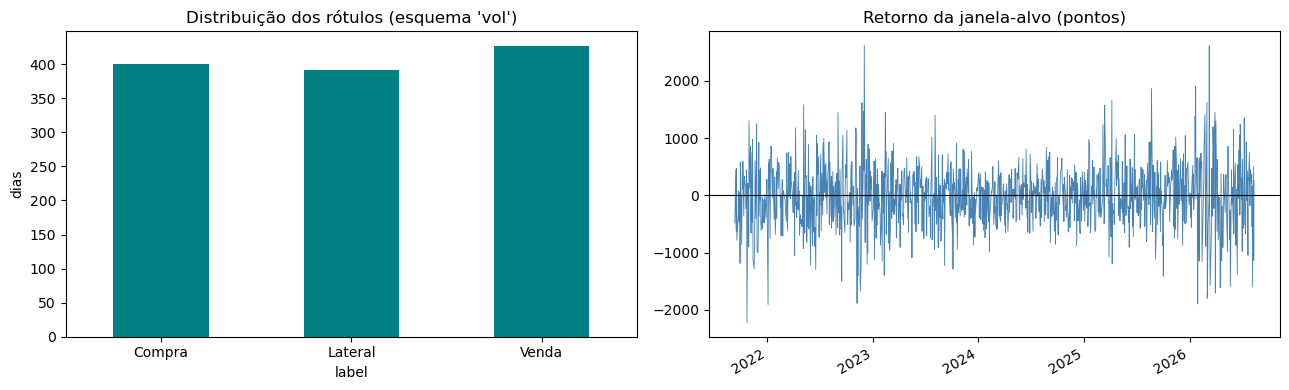

In [5]:
def construir_labels(df, janela, esquema):
    inicio, fim = janela
    jan = df.between_time(inicio, fim)
    agg = jan.resample("D").agg(
        ab=("Abertura", "first"), fe=("Fechamento", "last"),
        mx=("Maxima", "max"), mn=("Minima", "min"),
    ).dropna()

    retorno = agg["fe"] - agg["ab"]
    pavio = pd.Series(np.where(retorno >= 0, agg["ab"] - agg["mn"], agg["mx"] - agg["ab"]),
                      index=agg.index)

    if esquema == "fixo":
        cond = [(retorno > LIMIAR_RETORNO) & (pavio < LIMIAR_PAVIO),
                (retorno < -LIMIAR_RETORNO) & (pavio < LIMIAR_PAVIO)]
        y = pd.Series(np.select(cond, ["Compra", "Venda"], default="Lateral"), index=agg.index)

    elif esquema == "vol":
        # escala robusta: mediana móvel de |retorno| dos últimos 60 dias, só com passado
        escala = retorno.abs().rolling(60, min_periods=20).median().shift(1)
        k_ret = LIMIAR_RETORNO / escala.median()
        k_pav = LIMIAR_PAVIO / escala.median()
        cond = [(retorno > k_ret * escala) & (pavio < k_pav * escala),
                (retorno < -k_ret * escala) & (pavio < k_pav * escala)]
        y = pd.Series(np.select(cond, ["Compra", "Venda"], default="Lateral"), index=agg.index)
        y[escala.isna()] = np.nan

    elif esquema == "tercis":
        r = retorno / agg["ab"]
        q33 = r.rolling(250, min_periods=100).quantile(0.333).shift(1)
        q67 = r.rolling(250, min_periods=100).quantile(0.667).shift(1)
        y = pd.Series(np.select([r <= q33, r >= q67], ["Venda", "Compra"], default="Lateral"),
                      index=agg.index)
        y[q33.isna()] = np.nan
    else:
        raise ValueError(f"Esquema desconhecido: {esquema}")

    return y.rename("label"), retorno.rename("retorno_pts"), pavio.rename("pavio_pts")


y_todas, retorno_alvo, pavio_alvo = construir_labels(df, JANELA_ALVO, ESQUEMA_LABEL)

dados = X_todas.join(y_todas, how="inner").dropna()
X_all, y_all = dados.drop(columns="label"), dados["label"]

print(f"Amostras alinhadas : {len(X_all)}")
print(f"Features           : {X_all.shape[1]}")
print(f"Amostra por feature: {len(X_all) / X_all.shape[1]:.0f} : 1")
print(f"\nDistribuição das classes:")
print(y_all.value_counts().to_string())
print(f"\nMediana de |retorno| na janela-alvo: {retorno_alvo.abs().median():.0f} pontos")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
y_all.value_counts().reindex(CLASSES).plot.bar(ax=ax[0], color="teal", rot=0)
ax[0].set_title(f"Distribuição dos rótulos (esquema '{ESQUEMA_LABEL}')")
ax[0].set_ylabel("dias")
retorno_alvo.reindex(y_all.index).plot(ax=ax[1], lw=0.6, color="steelblue")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_title("Retorno da janela-alvo (pontos)")
plt.tight_layout(); plt.show()

---
## 5. Protocolo de avaliação

É o coração do notebook. Se essa seção estiver errada, todo resultado depois dela é
ficção — e ficção convincente, porque erro de protocolo quase sempre deixa o número
*melhor*, nunca pior.

---

### 5.1 O holdout sai agora, não depois

A primeira coisa que a célula faz é cortar os **últimos 20% dos dias** e guardar. Eles não
voltam até a seção 13.

A ordem importa mais do que parece. Separar agora significa que nenhuma decisão que eu
tomar no meio do caminho — qual feature usar, qual rótulo, qual modelo, quais
hiperparâmetros — pode ter sido influenciada por esses dias. Se eu separasse depois de já
ter olhado a base inteira, o holdout seria apenas um pedaço de dado que eu já vi, com outro
nome e uma falsa sensação de segurança.

O corte é **cronológico**, não aleatório: o holdout é o futuro em relação ao treino, igual
à situação real de operar.

| | Período | Dias |
|---|---|---|
| Trabalho | 2021-09-10 a 2025-08-15 | 976 |
| **Holdout** | **2025-08-18 a 2026-08-12** | **244** |

---

### 5.2 Walk-forward, não validação cruzada normal

`TimeSeriesSplit` com 5 folds funciona assim:

```
fold 1:  [treino]  [teste]
fold 2:  [treino......]  [teste]
fold 3:  [treino...........]  [teste]
fold 4:  [treino................]  [teste]
fold 5:  [treino.....................]  [teste]
             tempo →
```

O treino sempre cresce para trás, o teste sempre fica à frente. Nunca o contrário.

Validação cruzada comum embaralha os dados e acaba treinando em dias posteriores para
prever dias anteriores. Em série temporal isso é vazamento puro: o modelo aprende regimes
de mercado que, na hora da previsão, ainda não teriam acontecido. O número que sai é ótimo
e não significa nada.

#### Os folds não são o mesmo experimento

Vale olhar os números reais, porque eles mudam como se lê a média:

| Fold | Treino | Teste | Período de teste | Baseline do fold |
|---|---|---|---|---|
| 1 | **166** | 162 | 2022-05-16 a 2023-01-04 | 0,364 |
| 2 | 328 | 162 | 2023-01-05 a 2023-08-29 | 0,383 |
| 3 | 490 | 162 | 2023-08-30 a 2024-04-26 | 0,383 |
| 4 | 652 | 162 | 2024-04-29 a 2024-12-16 | 0,321 |
| 5 | **814** | 162 | 2024-12-17 a 2025-08-15 | 0,309 |

Duas consequências práticas:

**O fold 1 treina com 166 dias e o fold 5 com 814** — quase 5x mais. O primeiro fold mede
"o que dá para aprender com menos de um ano de dados", o último mede "o que dá para
aprender com três anos". Média entre eles é uma média de coisas diferentes.

**O baseline varia de 0,309 a 0,383 entre os folds** — 7 pontos percentuais de amplitude.
Isso acontece porque a proporção das classes muda de período para período. É por isso que
eu comparo modelo contra baseline **dentro de cada fold**, e não contra um baseline global:
um modelo pode parecer bom simplesmente por ter caído num fold onde a classe majoritária
era mais dominante.

#### O scaler é ajustado dentro do fold — e eu medi o quanto isso importa

`StandardScaler` ajustado só na parte de treino de cada fold. Ajustar na base toda vazaria
a média e o desvio do futuro para dentro do treino.

Fui medir a diferença nesta base:

| Como o scaler foi ajustado | Acurácia |
|---|---|
| Dentro do fold (correto) | 0,3635 ± 0,0111 |
| Na base toda (vaza) | 0,3630 ± 0,0107 |
| **Diferença** | **−0,0005** |

**Praticamente zero — e no sentido oposto do que eu esperava.** Vale ser honesto sobre
isso: neste notebook, ajustar o scaler errado não infla o resultado.

O motivo é que todas as features aqui já são **relativas e aproximadamente estacionárias**
(retornos, razões, proporções). A média e o desvio delas mudam pouco ao longo da amostra,
então "vazar" essas estatísticas quase não entrega informação.

Continuo ajustando dentro do fold por dois motivos: é o procedimento correto e não custa
nada, e se algum dia eu adicionar uma feature em nível absoluto — preço, volume bruto — o
vazamento passaria a ser grande e silencioso. O hábito protege o caso futuro.

---

### 5.3 Baseline em todo teste — e por que dois

Junto com cada modelo eu rodo um `DummyClassifier`. Uso dois tipos, e a medição mostra por
quê:

| Baseline | Acurácia | F1-macro |
|---|---|---|
| `most_frequent` | 0,3519 | **0,1733** |
| `stratified` | **0,3593** | 0,3544 |

Repare que eles se invertem conforme a métrica:

- **`most_frequent`** chuta sempre a classe mais comum. Acurácia razoável, mas F1-macro
  terrível — ele zera duas das três classes, e o F1 delas vai a zero.
- **`stratified`** sorteia respeitando a proporção das classes. Acerta um pouco de cada uma,
  então o F1-macro sobe bastante.

Aqui há uma surpresa que só apareceu medindo: **o `stratified` tem acurácia *maior* que o
`most_frequent`** (0,3593 contra 0,3519). Isso acontece porque as classes estão quase
equilibradas — quando não há classe dominante de verdade, chutar sempre a mesma não é a
melhor aposta.

Ou seja, não basta um baseline. Um modelo só aprendeu alguma coisa se superar **os dois, em
ambas as métricas**, e de forma consistente entre os folds. Ganho médio positivo com metade
dos folds negativos não conta.

---

### 5.4 Dez sementes, não uma

Rede neural com semente diferente dá resultado diferente. Modelos com amostragem aleatória
(`subsample`, `bootstrap`) também. Uma rodada só mede **a sorte daquela inicialização**, não
a qualidade do modelo.

Nesta base o desvio entre sementes fica em torno de **0,006 a 0,011** de acurácia. Guarde
esse número: ele é **maior que a diferença entre vários dos modelos testados**. Sem repetir,
é impossível distinguir "modelo melhor" de "semente com sorte".

Por isso tudo roda com no mínimo 10 sementes e o que eu reporto é **média ±
desvio-padrão**. A regra de leitura:

> Se o desvio entre sementes for da mesma ordem que a diferença entre dois modelos, esses
> dois modelos são **indistinguíveis**. Isso é uma conclusão, não um detalhe a ignorar.

---

### 5.5 As funções desta seção

| Função | O que faz |
|---|---|
| `walk_forward` | Um passe de 5 folds; devolve acurácia, F1 e o ganho sobre o baseline |
| `avaliar_multi_semente` | Roda o anterior com N sementes e agrega em média ± dp |
| `prever_out_of_fold` | Junta as previsões dos folds de teste — cada dia previsto por um modelo que nunca o viu |
| `teste_permutacao` | Embaralha o rótulo N vezes para construir a distribuição do acaso |

O `prever_out_of_fold` merece atenção especial: é ele que permite um backtest honesto. Cada
previsão vem de um modelo treinado exclusivamente em dias anteriores àquele. Backtest feito
com previsão in-sample dá 80% de acerto e uma curva de capital linda que não significa
absolutamente nada — é o erro mais caro desta área.

---

### 5.6 A armadilha do `early stopping`: parar de treinar olhando o conjunto errado

Este é o vazamento mais fácil de cometer sem perceber, porque o código parece correto e
roda sem erro nenhum. Ele aparece quando o mesmo conjunto de dados cumpre duas funções ao
mesmo tempo: **decidir quando parar o treino** e **gerar a métrica que vai ser reportada**.

O padrão problemático é este:

```python
model.fit(
    X_treino, y_treino,
    validation_data=(X_val, y_val),                       # 1. o early stopping olha aqui
    callbacks=[EarlyStopping(monitor="val_loss",
                             restore_best_weights=True)])  # 2. e restaura o melhor ponto

f1 = f1_score(y_val, model.predict(X_val))                # 3. e a métrica sai DAQUI
```

As três linhas isoladas estão certas. Juntas, elas produzem um número que não significa o
que parece.

**Por que isso infla o resultado.** O `EarlyStopping` percorre as épocas e guarda os pesos
do ponto de menor perda **em `X_val`**. Com `restore_best_weights=True`, o modelo que sai do
`fit` é literalmente o que teve o melhor desempenho naquele conjunto. Medir o F1 nesse mesmo
`X_val` não é estimar generalização — é **relatar o máximo de uma curva**, escolhido a
posteriori entre 200 ou 5.000 candidatos.

Quanto mais épocas, pior: com `epochs=5000` e `patience=100`, o processo tem milhares de
oportunidades de encontrar, por acaso, uma configuração de pesos que se sai bem naquelas
amostras específicas. O ruído do conjunto de validação vira parte do critério de seleção.

**Por que isso é pior dentro de uma busca de hiperparâmetros.** Se esse F1 inflado é o que
o Optuna (ou qualquer otimizador) recebe como objetivo, o viés deixa de ser um erro de
medição e passa a ser um erro de **escolha**: a busca vai preferir sistematicamente as
configurações que mais conseguem explorar o ruído daquele fold — normalmente as de maior
capacidade. O otimizador funciona perfeitamente; ele só está maximizando a coisa errada.

**A correção exige três partições, não duas:**

| Partição | Serve para | Pode gerar métrica? |
|---|---|---|
| Treino | ajustar os pesos | não |
| **Validação interna** | early stopping, escolha de época | **não** |
| Teste do fold | métrica reportada | sim |

No código deste notebook, `walk_forward_keras` reserva **20% do bloco de treino** para o
`validation_split` do Keras, e o fold de teste do `TimeSeriesSplit` **nunca** é passado como
`validation_data` — na verdade o argumento `validation_data` não aparece uma única vez no
notebook. Quem para o treino e quem dá a nota são conjuntos diferentes:

```python
modelo.fit([T_tr, C_tr], y_oh[i_tr],
           validation_split=0.2, shuffle=False,          # para o treino olhando aqui
           callbacks=[EarlyStopping(monitor="val_loss",
                                    restore_best_weights=True)])
p = modelo.predict([T_te, C_te])                          # e a nota sai daqui
```

O `shuffle=False` importa junto com o `validation_split`: o Keras separa a **última** fração
dos dados antes de embaralhar, então com `shuffle=False` a validação interna é o trecho
cronologicamente mais recente do bloco de treino. Sem isso, ela seria uma amostra aleatória
espalhada pelo período, e o modelo estaria escolhendo a época de parada com base em dias que
vêm depois de dias que ele ainda vai prever.

> **Como detectar isto num código alheio (ou meu, de seis meses atrás).** Procure o array
> que aparece em `validation_data=` e depois procure o mesmo array em `.predict(` ou
> `.evaluate(`. Se for o mesmo objeto, a métrica está contaminada. É uma busca de dez
> segundos e vale fazer em qualquer notebook antes de acreditar no número dele.

### 5.7 O que este protocolo NÃO protege

Vale ser explícito sobre os limites, porque protocolo rigoroso dá uma sensação de segurança
que pode passar do ponto.

| Risco | Protegido? | Por quê |
|---|---|---|
| Vazamento temporal | **sim** | walk-forward cronológico |
| Vazamento pelo scaler | **sim** | ajustado dentro do fold |
| Sorte de inicialização | **sim** | 10 sementes, média ± dp |
| Confundir acaso com sinal | **sim** | teste de permutação |
| Overfitting na escolha de features | **não** | escolhi features olhando o conjunto de trabalho |
| Overfitting na escolha de janela | **parcial** | o sweep rodou só nos 80%, mas eu vi os resultados |
| Garimpagem entre variantes | **não** | depende de disciplina, não de código |
| Mudança de regime futura | **não** | nada protege contra isso |

As três últimas linhas são a razão de existir o holdout da seção 13 e a lista fechada de
variantes no fim do notebook. Elas não são resolvidas por código — são resolvidas por não
trapacear consigo mesmo.


### 5.8 Eliminar uma hipótese não confirma a alternativa

Este é um erro de raciocínio, não de código, e por isso nenhum protocolo pega. Ele aparece
assim:

> *"Provei que usar só o histórico de preço não funciona. Isso valida e justifica a
> necessidade de usar o meu conjunto de 264 features."*

A primeira frase é um resultado. A segunda não decorre dela. Descartar a hipótese A não é
evidência a favor da hipótese B — as duas podem estar erradas, e é exatamente o que acontece
aqui: a linha de base univariada rende 0,086% (§8) **e** as 21 features multivariadas também
dão ganho nulo. Os dois resultados são negativos e independentes.

A versão mais comum do mesmo erro, e mais perigosa porque parece rigor:

| Raciocínio | Por que não fecha |
|---|---|
| "O modelo bateu o baseline, logo há sinal" | bater o baseline uma vez está dentro do que o acaso produz — daí o teste de permutação da §5.3 |
| "O método simples falhou, logo preciso do complexo" | o simples falhar não diz nada sobre o complexo funcionar |
| "Descartei o rótulo por clusterização, logo o rótulo por regra está certo" | os dois podem estar mal definidos |
| "As features não passaram no teste de MI, logo o problema é o modelo" | pode ser que não haja sinal em lugar nenhum |

**A postura correta é declarar cada hipótese e testá-la contra o acaso, separadamente.** Um
achado nulo em A é um achado sobre A. Se eu quiser afirmar algo sobre B, meço B — contra o
baseline e contra a permutação, como qualquer outro.

> **Por que isto está no protocolo e não nas observações.** Porque muda o que eu escrevo no
> paper. Um resultado nulo bem medido é publicável; um resultado nulo apresentado como
> "justificativa" para a abordagem seguinte vira argumento circular, e é o tipo de coisa que
> um revisor encontra.



In [6]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# ---- separa o holdout ANTES de qualquer experimento ----
n_holdout = int(len(X_all) * FRAC_HOLDOUT)
corte = len(X_all) - n_holdout

X_trab, y_trab = X_all.iloc[:corte], y_all.iloc[:corte]
X_hold, y_hold = X_all.iloc[corte:], y_all.iloc[corte:]

print(f"Trabalho          : {len(X_trab):4d} dias  ({X_trab.index.min():%Y-%m-%d} a {X_trab.index.max():%Y-%m-%d})")
print(f"HOLDOUT (intocado): {len(X_hold):4d} dias  ({X_hold.index.min():%Y-%m-%d} a {X_hold.index.max():%Y-%m-%d})")


def walk_forward(construir_modelo, X, y, n_splits=N_SPLITS, semente=0, detalhe=False):
    """Walk-forward cronológico. Devolve métricas médias do modelo e do baseline."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    m_acc, m_f1, b_acc, b_f1 = [], [], [], []

    for k, (i_tr, i_te) in enumerate(tscv.split(X), 1):
        scaler = StandardScaler().fit(X.iloc[i_tr])
        X_tr, X_te = scaler.transform(X.iloc[i_tr]), scaler.transform(X.iloc[i_te])
        y_tr, y_te = y.iloc[i_tr], y.iloc[i_te]

        modelo = construir_modelo(semente).fit(X_tr, y_tr)
        p_m = modelo.predict(X_te)
        p_b = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr).predict(X_te)

        m_acc.append(accuracy_score(y_te, p_m)); b_acc.append(accuracy_score(y_te, p_b))
        m_f1.append(f1_score(y_te, p_m, average="macro", zero_division=0))
        b_f1.append(f1_score(y_te, p_b, average="macro", zero_division=0))

        if detalhe:
            print(f"    fold {k} (teste={len(i_te):4d}): base={b_acc[-1]:.3f} "
                  f"modelo={m_acc[-1]:.3f} delta={m_acc[-1]-b_acc[-1]:+.3f}")

    return {"acc": np.mean(m_acc), "f1": np.mean(m_f1),
            "base_acc": np.mean(b_acc), "base_f1": np.mean(b_f1),
            "ganho": np.mean(m_acc) - np.mean(b_acc),
            "acc_por_fold": m_acc}


def avaliar_multi_semente(nome, construir_modelo, X, y, sementes=SEMENTES):
    """Roda o walk-forward com várias sementes. Rodada única não é resultado."""
    linhas = [walk_forward(construir_modelo, X, y, semente=s) for s in sementes]
    acc = np.array([r["acc"] for r in linhas])
    f1 = np.array([r["f1"] for r in linhas])
    ganho = np.array([r["ganho"] for r in linhas])
    return {"modelo": nome, "n_sementes": len(sementes),
            "acc_media": acc.mean(), "acc_dp": acc.std(),
            "f1_media": f1.mean(), "f1_dp": f1.std(),
            "ganho_medio": ganho.mean(), "ganho_dp": ganho.std(),
            "base_acc": linhas[0]["base_acc"],
            "acc_por_fold": np.mean([r["acc_por_fold"] for r in linhas], axis=0)}


def prever_out_of_fold(construir_modelo, X, y, n_splits=N_SPLITS, semente=0):
    """
    Previsões honestas: cada dia é previsto por um modelo treinado só em dias anteriores.
    Devolve apenas os dias cobertos pelos folds de teste.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    partes = []
    for i_tr, i_te in tscv.split(X):
        scaler = StandardScaler().fit(X.iloc[i_tr])
        modelo = construir_modelo(semente).fit(scaler.transform(X.iloc[i_tr]), y.iloc[i_tr])
        partes.append(pd.Series(modelo.predict(scaler.transform(X.iloc[i_te])),
                                index=X.index[i_te]))
    return pd.concat(partes)


def teste_permutacao(construir_modelo, X, y, n_perm=N_PERMUTACOES, semente=0):
    """
    Hipótese nula: as features não têm relação nenhuma com o rótulo.
    Embaralha y e mede o ganho sob o nulo. Devolve o p-valor empírico.
    """
    obs = walk_forward(construir_modelo, X, y, semente=semente)["ganho"]
    rng = np.random.default_rng(semente)
    nulos = np.empty(n_perm)
    t0 = time.time()
    for i in range(n_perm):
        y_perm = pd.Series(rng.permutation(y.values), index=y.index)
        nulos[i] = walk_forward(construir_modelo, X, y_perm, semente=semente)["ganho"]
    return {"ganho_observado": obs, "nulo_media": nulos.mean(), "nulo_dp": nulos.std(),
            "z": (obs - nulos.mean()) / nulos.std(),
            "p_valor": (np.sum(nulos >= obs) + 1) / (n_perm + 1),
            "segundos": time.time() - t0, "nulos": nulos}

print("\nProtocolo carregado.")

Trabalho          :  976 dias  (2021-09-10 a 2025-08-15)
HOLDOUT (intocado):  244 dias  (2025-08-18 a 2026-08-12)

Protocolo carregado.


---
## 6. Tratamento dos dados: o que fazer e o que não fazer

Quatro decisões de pré-processamento que parecem detalhe e não são. Duas delas eu faço,
duas eu deliberadamente **não** faço — e as duas que não faço são as mais tentadoras.

---

### 6.1 Duas normalizações, não uma

São coisas diferentes, resolvem problemas diferentes, e ambas são necessárias.

**Normalização de domínio** — dividir pela abertura. Torna as features comparáveis **ao
longo do tempo**. É o assunto da seção 3: o índice foi de 96 mil a 203 mil, e sem isso um
movimento de 300 pontos significaria coisas diferentes em 2021 e em 2026.

**Normalização estatística** — `StandardScaler`. Coloca as features na **mesma escala
numérica entre si**. Mesmo depois da primeira normalização, elas continuam em ordens de
grandeza incompatíveis:

| Feature | Mínimo | Máximo | Amplitude |
|---|---|---|---|
| `retorno_janela` | −0,0225 | 0,0415 | **0,0640** |
| `rsi` | 16,67 | 83,33 | **66,67** |
| `volume_norm` | 0,3577 | 1,5312 | 1,1735 |

A amplitude do RSI é **1.041 vezes** maior que a do retorno. Para uma rede neural, um valor
de 50 no RSI é numericamente enorme perto de 0,005 no retorno — e no início do treino ela
vai dar peso proporcional a isso, por acidente aritmético e não por importância real.

As duas não são redundantes: a primeira dá **validade temporal**, a segunda dá
**estabilidade de treino**.

> **Onde isso acontece neste notebook.** A normalização de domínio está dentro de
> `features_do_dia` (seção 3). A estatística está dentro de `walk_forward` (seção 5),
> ajustada só no treino de cada fold. E a divisão é sempre `shuffle=False` — um exemplo de
> normalização com divisão aleatória introduziria vazamento temporal, por mais que o
> `StandardScaler` esteja correto.

---

### 6.2 Padronização, não Min-Max

`MinMaxScaler` comprime tudo para [0, 1]. `StandardScaler` centra em 0 com desvio 1. Para
dados financeiros, a diferença é grande — e dá para medir.

O dia mais extremo da amostra é **2022-12-02**, com retorno de 2.625 pontos na janela-alvo —
**8 vezes** a mediana de 325 pontos. Veja o que cada scaler faz com ele:

| | StandardScaler | MinMaxScaler |
|---|---|---|
| Valor do outlier depois de transformar | 4,873 | 1,000 |
| Faixa ocupada pelos 90% centrais | [−1,580, 1,550] | [0,280, 0,629] |
| **Largura ocupada pelos 90% centrais** | **3,129** | **0,349** |
| Desvio-padrão dos 90% centrais | 0,7093 | 0,0791 |

O `MinMaxScaler` espreme **90% dos dados em 35% do intervalo disponível**, porque o único
dia extremo define o teto. Toda a variação que interessa — a diferença entre um dia normal e
outro — fica comprimida perto do meio.

O `StandardScaler` não tem teto. O outlier vira um z-score de 4,87, que é uma informação
útil ("este dia foi 5 desvios fora do normal, preste atenção"), e o resto dos dados mantém a
dispersão original.

---

### 6.3 Outliers: não remova

A tentação é forte. Os dias extremos atrapalham o treino, distorcem métricas e é fácil
justificar removê-los como "limpeza de dados".

**É o erro mais caro desta lista**, porque ele melhora o backtest e piora o resultado real.

| Medida | Valor |
|---|---|
| Dias acima do percentil 95 de \|retorno\| | 63 de 1.242 (5,1%) |
| **Fatia do movimento total que eles carregam** | **18,0%** |
| \|retorno\| mediano nesses dias | 1.390 pts |
| \|retorno\| mediano nos demais | 305 pts |

**Cinco por cento dos dias carregam 18% de todo o movimento.** Esses são exatamente os dias
onde estão o lucro e o prejuízo de qualquer estratégia direcional.

Removê-los produz um backtest suave, com drawdown pequeno e curva bonita — e uma falsa
sensação de segurança. O modelo em produção vai encontrar esses dias inevitavelmente, e é
neles que a estratégia é decidida.

**A abordagem correta é usar ferramentas robustas, não apagar o dado.** O `StandardScaler`
já é uma delas (§6.2): ele acomoda o extremo sem deixá-lo dominar a escala. Dropout e
regularização fazem o resto, impedindo que o modelo se ajuste a exemplos específicos.

---

### 6.4 Balanceamento de classes: aqui não é preciso — e a tentativa sai cara

Balancear classes é padrão quando há desequilíbrio real. A questão é o que conta como real:

| Desbalanceamento | Precisa tratar? |
|---|---|
| Até ~2x | não |
| ~4x | talvez, dependendo da métrica |
| 1:100, 1:1000 | indispensável |

**Aqui o desbalanceamento é de 1,12x** (Venda 348, Compra 317, Lateral 311). Não há nada
para corrigir.

Mesmo assim, testei a abordagem de **intercalar e truncar** — separar por classe, cortar
todas no tamanho da menor, e alternar Compra / Venda / Lateral em sequência — porque ela é
uma tentação natural quando se quer lotes balanceados.

#### O que ela custa

| Fold | Treino | Após intercalar | Descartado |
|---|---|---|---|
| 1 | 166 | 150 | 9,6% |
| 2 | 328 | 285 | 13,1% |
| 3 | 490 | 447 | 8,8% |
| 4 | 652 | 594 | 8,9% |
| 5 | 814 | 768 | 5,7% |
| **Total** | **2.450** | **2.244** | **8,4%** |

E não é um corte neutro: truncar pelos primeiros elementos descarta os dias **mais recentes**
das classes maiores, encurtando o histórico justamente de quem tinha mais exemplos.

#### A armadilha: o ganho triplica e é ilusão

| Estratégia | Acurácia | ±dp | F1-macro | Ganho reportado |
|---|---|---|---|---|
| Sem balanceamento | 0,3635 | 0,0111 | 0,3528 | +0,0116 |
| **Intercalar + truncar** | 0,3649 | 0,0025 | 0,3497 | **+0,0353** |
| `class_weight` balanced | 0,3538 | 0,0067 | 0,3455 | +0,0020 |

Olhando a coluna do ganho, a intercalação parece **três vezes melhor**. Mas a acurácia é
0,3649 contra 0,3635 — diferença de 0,0014, dentro de um desvio de 0,011. **O modelo não
melhorou em nada.**

O que mudou foi o **baseline**. Treinando o `DummyClassifier` num conjunto perfeitamente
balanceado, ele perde a informação de qual classe é majoritária, e sua acurácia no teste
(que continua desbalanceado) cai de 0,3519 para 0,3296. O ganho cresce porque a régua
encolheu.

> **É a armadilha mais perigosa desta seção**, porque não parece erro. Todo o código está
> certo, o walk-forward está certo, a divisão cronológica está certa — e ainda assim o
> número reportado triplica por uma razão que não tem nada a ver com o modelo. Se algum dia
> um pré-processamento seu mexer na distribuição do treino, **recalcule o baseline na
> distribuição original** antes de comparar.

E o F1-macro, que é justamente a métrica que balanceamento deveria ajudar, **piorou**
(0,3528 → 0,3497).

#### Sobre lotes de tamanho 3

A ideia de usar `batch_size=3` para garantir lotes perfeitamente balanceados tem dois
problemas independentes do balanceamento:

- **Gradiente ruidoso.** Três amostras dão uma estimativa péssima do gradiente; o treino
  fica instável e converge devagar.
- **Quebra o `BatchNormalization`.** As arquiteturas da seção 8 usam BatchNorm, que calcula
  média e desvio *dentro do lote*. Com 3 amostras essas estatísticas são inúteis, e o
  comportamento em treino diverge do de inferência.

Se algum dia o balanceamento for necessário de verdade, a ferramenta é `class_weight` (ou
`sample_weight`): pesa as classes sem descartar dado nem restringir o tamanho do lote.

---

### O resumo desta seção

| Decisão | O que eu faço | Por quê |
|---|---|---|
| Normalização de domínio | **sim** | comparabilidade temporal |
| Normalização estatística | **sim** | estabilidade de treino |
| Min-Max em vez de Z-score | não | um outlier espreme 90% dos dados em 35% da faixa |
| Remover outliers | **não** | 5% dos dias carregam 18% do movimento |
| Balancear classes | **não** | desbalanceamento é de 1,12x; e corrompe o baseline |


In [7]:
# ═══════════════ balanceamento: vale a pena? (reproduz a medição da §6.4) ═══════════════
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

def _intercalar(Xtr, ytr):
    """Separa por classe, trunca no tamanho da menor e alterna C/V/L."""
    partes = {c: Xtr[ytr == c] for c in CLASSES}
    m = min(len(p) for p in partes.values())
    idx = [partes[c].index[i] for i in range(m) for c in CLASSES]
    return Xtr.loc[idx], ytr.loc[idx]


def avaliar_balanceamento(modo, sementes=range(3)):
    """modo: 'nada' | 'intercalado' | 'class_weight'"""
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    accs, f1s, bases, descarte = [], [], [], []
    for s in sementes:
        a, f, b = [], [], []
        for i_tr, i_te in tscv.split(X_trab):
            Xtr, ytr = X_trab.iloc[i_tr], y_trab.iloc[i_tr]
            Xte, yte = X_trab.iloc[i_te], y_trab.iloc[i_te]
            sw = None
            if modo == "intercalado":
                n0 = len(Xtr); Xtr, ytr = _intercalar(Xtr, ytr)
                if s == 0:
                    descarte.append((n0 - len(Xtr)) / n0)
            elif modo == "class_weight":
                sw = compute_sample_weight("balanced", ytr)

            sc = StandardScaler().fit(Xtr)
            gb = GradientBoostingClassifier(n_estimators=200, max_depth=2, learning_rate=0.05,
                                            subsample=0.8, random_state=s)
            gb.fit(sc.transform(Xtr), ytr, sample_weight=sw)
            p = gb.predict(sc.transform(Xte))
            a.append(accuracy_score(yte, p))
            f.append(f1_score(yte, p, average="macro", zero_division=0))
            # o baseline é treinado no MESMO conjunto que o modelo — é aqui que mora a armadilha
            b.append(accuracy_score(yte, DummyClassifier(strategy="most_frequent")
                                    .fit(Xtr, ytr).predict(Xte)))
        accs.append(np.mean(a)); f1s.append(np.mean(f)); bases.append(np.mean(b))
    return (np.mean(accs), np.std(accs), np.mean(f1s), np.mean(bases),
            np.mean(descarte) if descarte else 0.0)


vc = y_trab.value_counts()
print(f"Distribuição do treino: {vc.to_dict()}")
print(f"Desbalanceamento (maior/menor): {vc.max()/vc.min():.2f}x")
print("(balanceamento costuma importar a partir de ~4x)\n")

print(f"{'estratégia':<24}{'acurácia':>10}{'±dp':>8}{'f1m':>9}{'baseline':>10}{'ganho':>9}{'descarte':>10}")
for modo, nome in [("nada", "sem balanceamento"),
                   ("intercalado", "intercalar + truncar"),
                   ("class_weight", "class_weight")]:
    a, dp, f1, base, desc = avaliar_balanceamento(modo)
    print(f"{nome:<24}{a:>10.4f}{dp:>8.4f}{f1:>9.4f}{base:>10.4f}{a-base:>+9.4f}{desc:>9.1%}")

print("\n>>> Compare a coluna 'ganho' com a coluna 'acurácia'.")
print(">>> Se o ganho subir enquanto a acurácia fica igual, o que mudou foi o BASELINE.")

Distribuição do treino: {'Venda': 348, 'Compra': 317, 'Lateral': 311}
Desbalanceamento (maior/menor): 1.12x
(balanceamento costuma importar a partir de ~4x)

estratégia                acurácia     ±dp      f1m  baseline    ganho  descarte
sem balanceamento           0.3584  0.0118   0.3487    0.3519  +0.0066     0.0%
intercalar + truncar        0.3646  0.0032   0.3504    0.3296  +0.0350     9.2%
class_weight                0.3490  0.0035   0.3400    0.3519  -0.0029     0.0%

>>> Compare a coluna 'ganho' com a coluna 'acurácia'.
>>> Se o ganho subir enquanto a acurácia fica igual, o que mudou foi o BASELINE.


---
## 7. Análise exploratória

Antes de treinar qualquer coisa, vale olhar para o que os dados dizem. Mas com duas
restrições que quase nunca são respeitadas.

**A primeira: isto roda depois da separação do holdout, não antes.** Análise exploratória é
olhar para os dados — e olhar já é uma forma de decidir. Se eu inspecionasse a base inteira
aqui, incluindo os 244 dias reservados, qualquer escolha que eu fizesse depois estaria
parcialmente informada por eles. Por isso esta seção vem *depois* da seção 5 e usa
exclusivamente `X_trab` / `y_trab`.

**A segunda: o que interessa é a relação entre feature e alvo.** É comum uma EDA gastar todo
o esforço em matrizes de correlação entre features e nunca perguntar o que se relaciona com
o que se quer prever. Correlação feature-feature responde "tenho colunas redundantes?", que
é uma pergunta de higiene. Ela não responde "existe informação aqui?", que é a pergunta que
decide se o projeto tem futuro.

### As três perguntas desta seção

| Pergunta | Como respondo |
|---|---|
| Alguma feature se relaciona com o rótulo? | informação mútua, contra uma régua de ruído |
| **Como** ela difere entre Compra, Lateral e Venda? | mediana por classe + Kruskal-Wallis |
| Existe redundância exata entre features? | posto da matriz |
| Existe redundância alta (mas não exata)? | pares com correlação acima de 0,8 |

As duas primeiras perguntas parecem a mesma, mas não são. A informação mútua diz **quanto**
uma feature sabe sobre o rótulo, num número só. A comparação por classe diz **em que
direção** — se dias de Compra têm mais volume, se dias Laterais são mais agitados. Uma
responde se vale a pena olhar; a outra responde o que se está vendo.

### Por que informação mútua e não correlação

Correlação de Pearson mede relação **linear** e exige alvo numérico. O rótulo aqui é
categórico (Compra / Lateral / Venda), e a relação com as features não tem motivo nenhum
para ser linear — um retorno muito positivo *ou* muito negativo pode empurrar para fora de
"Lateral", o que é uma relação em U que a correlação lê como zero.

Informação mútua captura qualquer tipo de dependência e funciona com alvo categórico.

### A régua de ruído — sem ela o número não significa nada

Informação mútua estimada em amostra finita **nunca dá exatamente zero**, mesmo para uma
feature completamente aleatória. O estimador sempre encontra algum padrão espúrio.

Por isso eu sorteio uma feature de ruído puro, meço a MI dela com o rótulo, repito 20 vezes
e tiro a média. Esse valor é o **piso**: qualquer feature que não fique claramente acima
dele não está carregando informação, está carregando ruído de estimação.

Sem essa régua, uma MI de 0,006 parece "pequena mas positiva". Com ela, dá para ver que
0,006 é exatamente o que uma coluna de números aleatórios produz.


Informação mútua com o rótulo — 976 dias do conjunto de trabalho
(régua de ruído = 0.00901; features abaixo de 2x isso são indistinguíveis do acaso)

   f_inclinacao      0.05459  <-- acima de 2x o ruído
   f_atividade       0.03826  <-- acima de 2x o ruído
   f_range           0.03761  <-- acima de 2x o ruído
   f_vol_total       0.02548  <-- acima de 2x o ruído
   f_retorno         0.02149  <-- acima de 2x o ruído
   f_dist_ma20       0.01645
   f_pos_fech        0.01267
   f_dow_cos         0.01218
   c_pos_d1          0.01160
   f_tam_ordem       0.00467
   f_macd            0.00295
   f_vol_buildup     0.00186
   f_frac_alta       0.00176
   c_dist_mm20       0.00100
   f_rsi             0.00092
   f_pavio           0.00020
   f_vol_real        0.00000
   c_range_d1        0.00000
   c_atr_d1          0.00000
   f_dow_sin         0.00000
   c_gap             0.00000

5 de 21 features passam de 2x a régua de ruído.


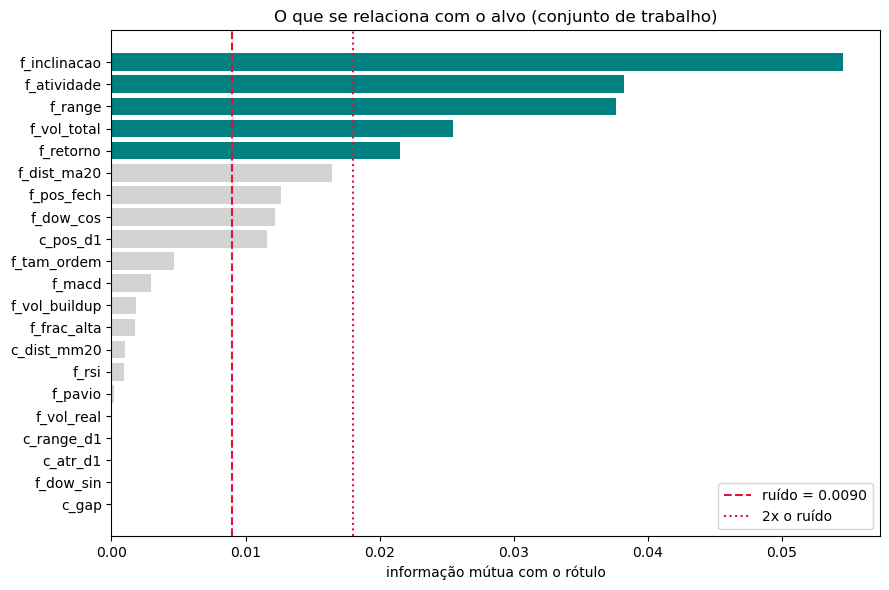

In [8]:
from sklearn.feature_selection import mutual_info_classif

# ═══════════════ 1. informação mútua com o rótulo, contra régua de ruído ═══════════════
mi = mutual_info_classif(X_trab, y_trab, random_state=0)
mi = pd.Series(mi, index=X_trab.columns).sort_values(ascending=False)

# régua: MI de uma feature puramente aleatória, média de 20 sorteios
rng = np.random.default_rng(0)
ruido = np.mean([
    mutual_info_classif(pd.DataFrame({"x": rng.normal(size=len(X_trab))}, index=X_trab.index),
                        y_trab, random_state=s)[0]
    for s in range(20)
])

print(f"Informação mútua com o rótulo — {len(X_trab)} dias do conjunto de trabalho")
print(f"(régua de ruído = {ruido:.5f}; features abaixo de 2x isso são indistinguíveis do acaso)\n")
for nome, v in mi.items():
    marca = "  <-- acima de 2x o ruído" if v > 2 * ruido else ""
    print(f"   {nome:<16}{v:>9.5f}{marca}")

acima = int((mi > 2 * ruido).sum())
print(f"\n{acima} de {len(mi)} features passam de 2x a régua de ruído.")

fig, ax = plt.subplots(figsize=(9, 6))
cores = ["teal" if v > 2 * ruido else "lightgray" for v in mi.values]
ax.barh(mi.index[::-1], mi.values[::-1], color=cores[::-1])
ax.axvline(ruido, color="crimson", ls="--", lw=1.5, label=f"ruído = {ruido:.4f}")
ax.axvline(2 * ruido, color="crimson", ls=":", lw=1.5, label="2x o ruído")
ax.set_xlabel("informação mútua com o rótulo")
ax.set_title("O que se relaciona com o alvo (conjunto de trabalho)")
ax.legend(); plt.tight_layout(); plt.show()

Mediana por classe e teste de Kruskal-Wallis (conjunto de trabalho)

                Compra  Lateral    Venda  separação_dp  p_kruskal
feature                                                          
f_vol_total     0.9902   1.0120   0.9920        0.1664     0.0282
f_vol_real      0.0011   0.0012   0.0011        0.1723     0.0353
f_atividade     0.0195   0.0209   0.0198        0.1947     0.0495
f_dow_sin       0.4339   0.4339   0.4339        0.0000     0.0857
f_retorno       0.0004  -0.0004  -0.0006        0.1588     0.0859
f_inclinacao    0.0000  -0.0000  -0.0000        0.1660     0.0969
f_tam_ordem     1.0064   0.9980   0.9964        0.2045     0.1157
f_vol_buildup   1.6168   1.5823   1.6601        0.2134     0.1505
c_range_d1      0.0146   0.0156   0.0148        0.1264     0.1554
f_frac_alta     0.5000   0.5000   0.5000        0.0000     0.2764
f_rsi          49.3888  49.1582  48.5133        0.0468     0.4101
f_pos_fech      0.5317   0.4877   0.4784        0.1733     0.4768
f_dist_

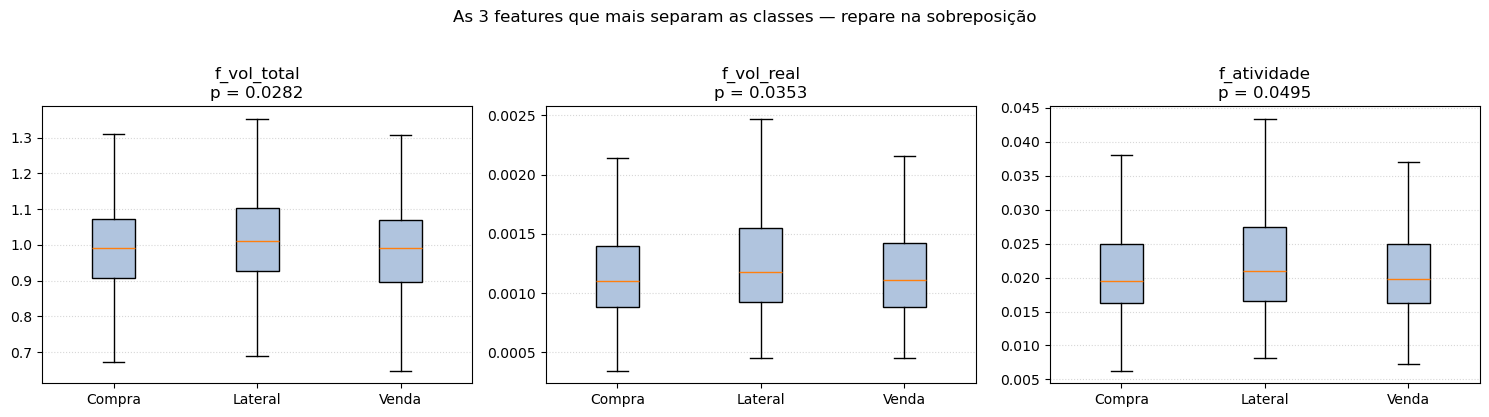

In [9]:
# ═══════════════ comparação direta com o rótulo: como cada feature se distribui por classe ═══════════════
from scipy.stats import kruskal

linhas = []
for col in X_trab.columns:
    med = [X_trab.loc[y_trab == c, col].median() for c in CLASSES]
    grupos = [X_trab.loc[y_trab == c, col].values for c in CLASSES]
    h, p = kruskal(*grupos)
    # separação em desvios-padrão: quanto as medianas se afastam, na escala da feature
    amp = (max(med) - min(med)) / X_trab[col].std()
    linhas.append({"feature": col, "Compra": med[0], "Lateral": med[1], "Venda": med[2],
                   "separação_dp": amp, "p_kruskal": p})

por_classe = pd.DataFrame(linhas).set_index("feature").sort_values("p_kruskal")
print("Mediana por classe e teste de Kruskal-Wallis (conjunto de trabalho)\n")
print(por_classe.round(4).to_string())

n_sig = int((por_classe["p_kruskal"] < 0.05).sum())
esperado = 0.05 * len(por_classe)
bonf = 0.05 / len(por_classe)
n_bonf = int((por_classe["p_kruskal"] < bonf).sum())

print(f"\nFeatures com p < 0,05 .................... {n_sig} de {len(por_classe)}")
print(f"Esperado por acaso ({len(por_classe)} testes a 5%) ....... ~{esperado:.0f}")
print(f"Limiar de Bonferroni (0,05 / {len(por_classe)}) .......... {bonf:.4f}")
print(f"Features que sobrevivem a Bonferroni ..... {n_bonf}")

# ---- boxplots das 3 features com menor p ----
top3 = por_classe.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, top3):
    dados = [X_trab.loc[y_trab == c, col].values for c in CLASSES]
    bp = ax.boxplot(dados, labels=CLASSES, showfliers=False, patch_artist=True)
    for caixa in bp["boxes"]:
        caixa.set_facecolor("lightsteelblue")
    ax.set_title(f"{col}\np = {por_classe.loc[col, 'p_kruskal']:.4f}")
    ax.grid(axis="y", ls=":", alpha=.5)
fig.suptitle("As 3 features que mais separam as classes — repare na sobreposição", y=1.03)
plt.tight_layout(); plt.show()

In [10]:
# ═══════════════ 2. redundância exata: o posto da matriz ═══════════════
Z = StandardScaler().fit_transform(X_trab)
posto = np.linalg.matrix_rank(Z)
print(f"Colunas: {X_trab.shape[1]}   |   posto da matriz: {posto}")
if posto < X_trab.shape[1]:
    print(f">>> {X_trab.shape[1] - posto} coluna(s) são combinação linear exata de outras.")
else:
    print(">>> Nenhuma redundância exata. Nenhuma feature é combinação linear das demais.")

# variância explicada acumulada — quantas dimensões efetivas existem
vals = np.linalg.svd(Z, compute_uv=False)
var = np.cumsum(vals ** 2) / (vals ** 2).sum()
n90 = int(np.searchsorted(var, 0.90)) + 1
print(f"    {n90} componentes explicam 90% da variância "
      f"({n90/X_trab.shape[1]:.0%} das colunas)")

# ═══════════════ 3. pares muito correlacionados ═══════════════
corr = X_trab.corr().abs()
pares = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().sort_values(ascending=False))
fortes = pares[pares > 0.8]

print(f"\nPares com |correlação| > 0,8: {len(fortes)}")
if len(fortes):
    for (a, b), v in fortes.items():
        print(f"   {a:<16} x {b:<16} {v:>6.3f}")
else:
    print("   nenhum — não há redundância alta entre as features")

print(f"\nOs 5 pares mais correlacionados (mesmo abaixo de 0,8):")
for (a, b), v in pares.head(5).items():
    print(f"   {a:<16} x {b:<16} {v:>6.3f}")

Colunas: 21   |   posto da matriz: 21
>>> Nenhuma redundância exata. Nenhuma feature é combinação linear das demais.
    12 componentes explicam 90% da variância (57% das colunas)

Pares com |correlação| > 0,8: 7
   f_vol_real       x f_atividade       0.942
   f_macd           x f_dist_ma20       0.935
   f_rsi            x f_dist_ma20       0.892
   f_retorno        x f_inclinacao      0.868
   f_pos_fech       x f_rsi             0.861
   f_pos_fech       x f_dist_ma20       0.860
   f_rsi            x f_macd            0.844

Os 5 pares mais correlacionados (mesmo abaixo de 0,8):
   f_vol_real       x f_atividade       0.942
   f_macd           x f_dist_ma20       0.935
   f_rsi            x f_dist_ma20       0.892
   f_retorno        x f_inclinacao      0.868
   f_pos_fech       x f_rsi             0.861


### 7.1 Como ler esta seção

**Se poucas features passarem da régua**, não é motivo para desistir — informação mútua
mede dependência de cada feature **isoladamente**. Uma feature pode ser inútil sozinha e
valiosa em combinação com outra, e a MI univariada não enxerga isso. Modelos de árvore e
redes enxergam.

**Mas se quase nenhuma passar**, é um sinal forte. Significa que o sinal, se existir, está
inteiramente em interações — o que é possível, mas é uma aposta bem mais difícil com ~1.000
amostras.

**Sobre a redundância:** ausência de redundância exata é o mínimo, não uma conquista. O que
essa checagem pega é o erro de incluir simultaneamente "as partes" e "o todo" — como
`pavio_superior + pavio_inferior + corpo = range`, que apareceu no conjunto original e daria
posto menor que o número de colunas.

> **Uma coisa que esta seção não faz: escolher features pelo resultado.** É tentador olhar a
> tabela, cortar tudo que ficou abaixo da régua e treinar de novo. Isso é seleção de features
> usando o mesmo dado que depois vai medir o modelo — e infla o resultado de um jeito que o
> walk-forward não detecta, porque a decisão foi tomada fora dele. Se eu quisesse selecionar
> features de verdade, teria que fazer isso **dentro** de cada fold de treino.

### 7.2 O que a comparação por classe revelou

Vale registrar o resultado, porque ele muda como se lê a tabela de informação mútua.

**Só 3 das 21 features diferem entre as classes a p < 0,05.** Com 21 testes, o esperado por
puro acaso é ~1. Três é pouco acima disso — e **nenhuma sobrevive à correção de
Bonferroni** (limiar de 0,0024).

**As três são todas de volume e atividade:** `f_vol_total`, `f_vol_real` e `f_atividade`. E
o padrão é o mesmo nas três — os dias rotulados **Lateral têm valores maiores** que os de
Compra e Venda.

Isso é interpretável, e aponta para um lugar específico. "Lateral" neste rótulo significa
"o movimento teve pavio grande contra" — ou seja, janela-alvo bagunçada. O que a tabela diz
é: **manhã agitada prevê 11h agitada.** Isso é persistência de volatilidade, não previsão de
direção — exatamente a hipótese da variante V4 no fim do notebook.

**Mas a separação é minúscula.** A amplitude entre as medianas é de 0,17 a 0,19
desvios-padrão, e os intervalos interquartis se sobrepõem quase por completo. Os boxplots
mostram isso melhor que qualquer número: as três caixas praticamente coincidem.

> **Uma inconsistência que vale encarar.** O ranking da informação mútua e o do
> Kruskal-Wallis **não concordam**. A MI coloca `f_inclinacao` em primeiro (0,055); o Kruskal
> dá p = 0,097 para ela, não significativo. Já `f_vol_real`, que o Kruskal aponta como uma
> das três melhores, tem MI de 0,000.
>
> Isso não é erro de nenhum dos dois — eles medem coisas diferentes (MI capta relação de
> qualquer formato, Kruskal compara postos entre grupos). Mas a discordância entre dois
> métodos aplicados à mesma pergunta é, por si só, o resultado mais informativo desta seção:
> **nesses tamanhos de efeito, nenhum ranking de features é estável.** Tratar qualquer uma
> dessas ordenações como verdade seria ler ruído.


---
## 8. Modelos tabulares

Sete modelos sobre as 21 features (16 da janela + 5 de contexto diário). Com 976 dias de trabalho, esse é o regime de
dados certo — as redes vêm na seção seguinte, mas já com a expectativa declarada de que
estão fora da zona de conforto delas.

### Quem está na lista e por quê

| Modelo | O que ele traz | Por que está aqui |
|---|---|---|
| **Baseline (majoritária)** | chuta sempre a classe mais comum | piso da acurácia — o número a bater |
| **Baseline (estratificado)** | sorteia na proporção das classes | piso do F1-macro |
| **Regressão logística** | fronteira linear | se um modelo linear já resolve, não preciso de nada mais complexo |
| **SVM (RBF)** | fronteira não linear via kernel | captura interação sem precisar de muitos dados |
| **Random Forest** | árvores independentes, votação | robusto a ruído e a feature irrelevante |
| **Gradient Boosting** | árvores em sequência, cada uma corrige a anterior | costuma ser o melhor em dado tabular deste tamanho |
| **XGBoost** | boosting com regularização mais forte | mesma família, implementação mais controlada |

A ordem não é acidental: ela vai do mais simples ao mais complexo. Se a regressão
logística já batesse o baseline, eu não precisaria de árvore nenhuma. E se nenhum deles
bate, é sinal de que o problema não está na capacidade do modelo.

### Os hiperparâmetros são propositalmente conservadores

`max_depth=2` no Gradient Boosting, `max_depth=4` e `min_samples_leaf=10` na Random
Forest, `learning_rate=0.05`. Nada disso foi otimizado.

Isso é deliberado. Com 976 amostras, uma busca de hiperparâmetros com dezenas de tentativas
encontraria a combinação que melhor se ajusta ao **ruído** do conjunto de validação, não a
que generaliza. Modelo raso e regularizado é a escolha certa nesse tamanho de amostra.

Se algum modelo mostrasse sinal aqui, aí sim valeria abrir uma busca — mas com validação
aninhada, com a busca acontecendo *dentro* de cada fold de treino.

### O SVM tem capacidade também — só que ela não se chama "parâmetros"

Na seção 9 eu conto parâmetros treináveis para argumentar que as redes estão fora da zona de
conforto. O SVM parece escapar dessa conta, porque não tem camadas nem pesos para somar. Mas
tem o equivalente: **o número de vetores de suporte é a contagem de parâmetros efetivos de
um SVM.** São os pontos de treino que o modelo precisa guardar para reconstruir a fronteira.

Medi quantos pontos viram vetor de suporte com kernel RBF, usando dados **aleatórios, sem
sinal nenhum** — o cenário em que qualquer ajuste é memorização pura:

| Cenário | `C` | Vetores de suporte | % do treino |
|---|---:|---:|---:|
| 976 amostras, 21 features (o que uso aqui) | 1 | 968 | 99% |
| 976 amostras, 21 features | 10.000 | 957 | 98% |
| 976 amostras, **120 features** (vetor achatado) | 1 | 976 | **100%** |
| 78 amostras, **264 features** | 1 | 78 | **100%** |

**Praticamente todo ponto vira vetor de suporte.** Um parâmetro por amostra — o mesmo regime
das redes, expresso em outro vocabulário. É por isso que o SVM entra aqui com `C=1.0` e
`gamma="scale"`, e não com uma busca que possa levar o `C` para 10⁴: com dados padronizados,
`C` grande é margem rígida, ou seja, regularização praticamente desligada.

> **Como ler o resultado dele.** Se o SVM (RBF) aparecer no topo da tabela, vale desconfiar
> antes de comemorar — com quase 100% de vetores de suporte, ele tem capacidade de sobra para
> encaixar ruído, e a diferença entre "aprendeu" e "decorou" vai depender inteiramente do
> ganho sobre o baseline no fold de **teste**, não do número de treino.

### O wrapper do XGBoost

O XGBoost só aceita rótulo numérico. Em vez de espalhar conversão de classe pelo notebook
inteiro, embrulhei ele numa classe que converte texto→número na entrada e número→texto na
saída. Assim ele se comporta exatamente como os outros modelos do scikit-learn e o resto
do código não precisa saber da diferença.

### Como ler a tabela de resultados

A coluna que importa é **`ganho_medio`** — a diferença de acurácia entre o modelo e o
baseline majoritário. Positivo e consistente significa que aprendeu alguma coisa. Zero ou
negativo significa que não.

E olhe sempre o `acc_dp` junto: se o desvio entre sementes for maior que o ganho, o ganho
não é real.

### A linha de base univariada: por que ARIMA/SARIMA não entra na lista

Uma pergunta natural é por que não há um ARIMA aqui. Ele é o modelo clássico de série
temporal, e a versão sazonal (SARIMA) parece feita sob medida para um ativo com padrão
intradiário — abertura volátil, calmaria no meio, movimento no fim.

Não está na lista porque dá para calcular o **teto** dele antes de rodar, e o teto é nulo.

**O argumento.** Um `ARIMA(p, d, q)` sobre preços usa `d=1` (diferenciação) para virar
estacionário, e depois modela a **autocorrelação da série diferenciada** — ou seja, dos
retornos. As partes AR e MA são exatamente isso: quanto o retorno de agora é previsível a
partir dos retornos e dos erros anteriores. Então basta medir quanta autocorrelação existe.

Rodei nas 12.062 barras H1 do WIN (2021-08-13 a 2026-08-12):

| Teste | Resultado | Leitura |
|---|---|---|
| ADF no preço | estat. −0,55, **p = 0,883** | não estacionária, como esperado |
| ADF no retorno (`d=1`) | estat. −77,76, **p ≈ 0** | estacionária — `d=1` basta |

Confirmado o `d=1`, a pergunta que decide tudo é a autocorrelação dos retornos:

| lag | ACF | banda 95% | fora da banda? |
|---:|---:|---:|---|
| 1 | **−0,0293** | 0,0178 | sim |
| 9 | **−0,0271** | 0,0179 | sim |
| 2–8, 10 | entre −0,012 e +0,014 | ≈0,0179 | não |

Dois lags saem da banda — com 12 mil barras, dá para detectar coeficientes minúsculos. Mas o
maior é **−0,029**, e um AR(1) com ρ = 0,029 explica ρ² = **0,086% da variância dos
retornos**.

**Esse é o teto de toda a família.** Não é questão de ordem mal escolhida, e nenhum
`auto_arima` conserta: a estrutura linear que o ARIMA existe para capturar tem magnitude de
um décimo de por cento. Com o `CUSTO_PONTOS` de 7 pontos por operação usado aqui, não há como converter
isso em resultado.

Para dimensionar: a previsão ingênua "o próximo fechamento é igual ao atual" — que é o que um
ARIMA nesses dados converge a fazer — dá **RMSE de 498 pontos** e **48,3% de acurácia
direcional**. Abaixo dos 50% de uma moeda.

> **O uso legítimo disto.** Não é descartar o ARIMA — é usá-lo como **linha de base
> univariada declarada**. Ter medido que o histórico de preço sozinho rende 0,086% dá uma
> referência honesta contra a qual comparar qualquer modelo multivariado, e é um resultado
> publicável por si só num paper que reporta achado nulo.
>
> **E cuidado com a conclusão fácil.** Mostrar que o preço sozinho não prevê o preço **não**
> demonstra que features adicionais preveem. Ver a §5.8.



In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

MODELOS_TABULARES = {
    "Baseline (majoritária)":   lambda s: DummyClassifier(strategy="most_frequent"),
    "Baseline (estratificado)": lambda s: DummyClassifier(strategy="stratified", random_state=s),
    "Regressão logística":      lambda s: LogisticRegression(max_iter=2000, C=1.0, random_state=s),
    "SVM (RBF)":                lambda s: SVC(C=1.0, gamma="scale", random_state=s),
    "Random Forest":            lambda s: RandomForestClassifier(
        n_estimators=300, max_depth=4, min_samples_leaf=10, random_state=s, n_jobs=-1),
    "Gradient Boosting":        lambda s: GradientBoostingClassifier(
        n_estimators=200, max_depth=2, learning_rate=0.05, subsample=0.8, random_state=s),
}

try:
    import xgboost as xgb

    class XGBTexto:
        """Wrapper para o XGBoost aceitar rótulo em texto igual aos outros modelos."""
        def __init__(self, semente):
            self.m = xgb.XGBClassifier(
                n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
                colsample_bytree=0.8, reg_lambda=1.0, random_state=semente, n_jobs=-1,
                objective="multi:softprob", num_class=3, verbosity=0)
            self.classes_ = np.array(CLASSES)

        def fit(self, X, y):
            self.m.fit(X, pd.Series(y).map({c: i for i, c in enumerate(CLASSES)}).values)
            return self

        def predict(self, X):
            return self.classes_[self.m.predict(X)]

    MODELOS_TABULARES["XGBoost"] = lambda s: XGBTexto(s)
except ImportError:
    print("xgboost indisponível — pulando esse modelo.\n")

resultados = []
for nome, ctor in MODELOS_TABULARES.items():
    t0 = time.time()
    r = avaliar_multi_semente(nome, ctor, X_trab, y_trab)
    r["segundos"] = time.time() - t0
    r["familia"] = "tabular"
    resultados.append(r)
    print(f"{nome:<26} acc={r['acc_media']:.3f}±{r['acc_dp']:.3f}  "
          f"f1m={r['f1_media']:.3f}±{r['f1_dp']:.3f}  "
          f"ganho={r['ganho_medio']:+.3f}  ({r['segundos']:.0f}s)")

tabela = pd.DataFrame(resultados).set_index("modelo")
tabela[["acc_media", "acc_dp", "f1_media", "f1_dp", "ganho_medio", "ganho_dp"]].round(4)

Baseline (majoritária)     acc=0.352±0.000  f1m=0.173±0.000  ganho=+0.000  (1s)
Baseline (estratificado)   acc=0.340±0.013  f1m=0.337±0.013  ganho=-0.012  (1s)
Regressão logística        acc=0.314±0.000  f1m=0.297±0.000  ganho=-0.038  (1s)
SVM (RBF)                  acc=0.347±0.000  f1m=0.313±0.000  ganho=-0.005  (2s)
Random Forest              acc=0.348±0.006  f1m=0.287±0.005  ganho=-0.004  (29s)
Gradient Boosting          acc=0.358±0.010  f1m=0.348±0.010  ganho=+0.006  (78s)
XGBoost                    acc=0.360±0.006  f1m=0.351±0.007  ganho=+0.009  (16s)


,acc_media,acc_dp,f1_media,f1_dp,ganho_medio,ganho_dp
modelo,,,,,,
Baseline (majoritária),0.3519,0.0000,0.1733,0.0000,0.0000,0.0000
Baseline (estratificado),0.3401,0.0131,0.3371,0.0132,-0.0117,0.0131
Regressão logística,0.3136,0.0000,0.2973,0.0000,-0.0383,0.0000
SVM (RBF),0.3469,0.0000,0.3128,0.0000,-0.0049,0.0000
Random Forest,0.3479,0.0064,0.2875,0.0048,-0.0040,0.0064
Gradient Boosting,0.3581,0.0103,0.3478,0.0096,0.0063,0.0103
XGBoost,0.3604,0.0061,0.3506,0.0066,0.0085,0.0061


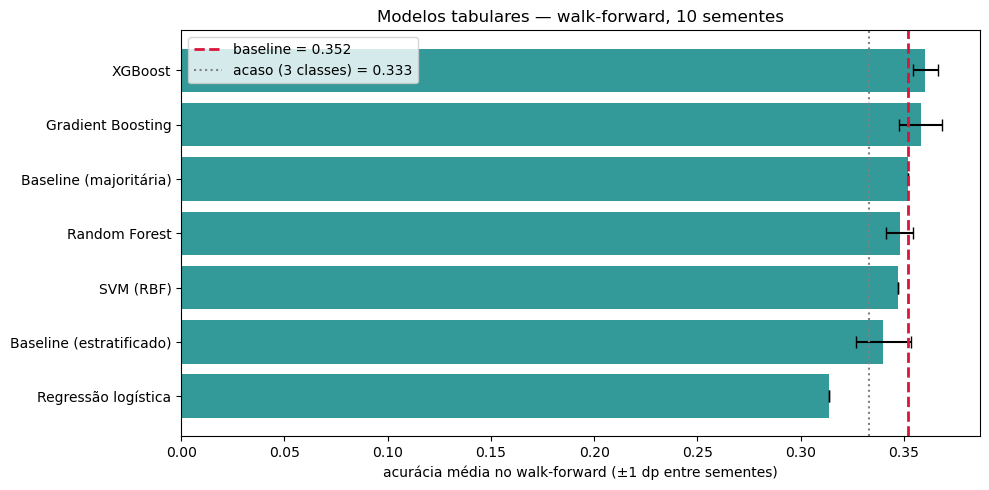

In [12]:
ordem = tabela.sort_values("acc_media")
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(ordem.index, ordem["acc_media"], xerr=ordem["acc_dp"],
        color="teal", alpha=0.8, capsize=4)
ax.axvline(tabela["base_acc"].iloc[0], color="crimson", ls="--", lw=2,
           label=f"baseline = {tabela['base_acc'].iloc[0]:.3f}")
ax.axvline(1/3, color="gray", ls=":", lw=1.5, label="acaso (3 classes) = 0.333")
ax.set_xlabel("acurácia média no walk-forward (±1 dp entre sementes)")
ax.set_title("Modelos tabulares — walk-forward, 10 sementes")
ax.legend(); plt.tight_layout(); plt.show()

---
## 9. Modelos sequenciais (deep learning)

Aqui as arquiteturas recebem a **sequência inteira**, não o resumo. É a parte que responde
diretamente à discussão do começo do notebook sobre como conectar as velas na rede.

### O formato dos dados muda

Enquanto os modelos tabulares recebem uma matriz `(dias, 21)`, estes recebem duas
entradas — um tensor 3D com a sequência e um vetor com o contexto:

```
(1.213 dias, 24 velas, 5 medidas)  +  (1.213 dias, 5 de contexto)
```

As 5 medidas de cada vela são todas relativas ao preço, para funcionarem igual em qualquer
nível do índice:

| Medida | Fórmula | O que descreve |
|---|---|---|
| `r_retorno` | `(fecha − abre) / abre` | direção e tamanho do corpo |
| `r_range` | `(máxima − mínima) / abre` | amplitude total da vela |
| `r_pav_sup` | `(máxima − topo do corpo) / abre` | rejeição de preço em cima |
| `r_pav_inf` | `(base do corpo − mínima) / abre` | rejeição de preço embaixo |
| `r_vol` | volume ÷ média móvel de 50 velas | volume relativo ao normal recente |

Juntas, elas descrevem a **forma** de cada vela — que é exatamente o que a análise técnica
clássica lê num gráfico de candles.

### As quatro arquiteturas e o viés de cada uma

**MLP** — é a Arquitetura 2 da introdução. Achata a sequência e conecta tudo a todos os
neurônios. Cada neurônio oculto vê todas as 24 velas ao mesmo tempo e pode virar um
detector de padrão que combina velas distantes.
*Limitação:* não tem noção de ordem. Para ele, trocar a vela 3 com a vela 20 seria só
outra entrada qualquer.

**CNN 1D** — resolve justamente a rigidez do Teste 1. O filtro convolucional desliza pela
sequência procurando o mesmo padrão **em qualquer posição**. Se um engolfo de alta é sinal
de compra, a CNN reconhece ele às 09:30 e às 10:30 com os mesmos pesos.
Uso `padding="causal"` para que cada posição só enxergue o passado, nunca o futuro.

**LSTM** — processa vela a vela carregando um estado interno. Em vez de olhar tudo de uma
vez, ela constrói uma memória do que veio antes e decide o que guardar e o que esquecer.
É a arquitetura desenhada para série temporal.
*Limitação:* é a que mais precisa de dados, e 970 amostras é pouco.

**TCN** — convolução dilatada. Empilha camadas com espaçamento crescente (1, 2, 4) e
alcança a janela inteira com poucas camadas. Combina o campo receptivo grande da LSTM com
o treino paralelo da CNN.

### Como a convolução realmente lê os dados

Vale abrir a mecânica da `Conv1D`, porque tem uma confusão comum embutida e ela muda o que se
espera do modelo.

**O kernel não olha uma feature de cada vez. Ele olha todas de uma vez, num pedaço do tempo.**

O tensor de entrada é `(24 velas, 5 medidas)`. Um kernel com `kernel_size=3` é uma matriz de
pesos `(3, 5)` — três passos de tempo por cinco medidas. Ele se posiciona sobre as velas 1 a 3,
multiplica cada um dos `3 × 5 = 15` pesos pelo valor correspondente, soma tudo, adiciona o viés,
e produz **um único número**.

Com um exemplo reduzido para 3 medidas, para caber na página:

```
dados (velas 1-3)                    kernel (pesos)
        r_retorno  r_range  r_vol            w_ret  w_rng  w_vol
vela 1 [  0.0012    0.0031   1.15 ]   ×   [  w11    w12    w13  ]
vela 2 [ -0.0004    0.0028   0.92 ]       [  w21    w22    w23  ]
vela 3 [  0.0021    0.0045   1.480]       [  w31    w32    w33  ]

resultado = 0.0012·w11 + 0.0031·w12 + 1.15·w13
          + (-0.0004)·w21 + 0.0028·w22 + 0.92·w23
          + 0.0021·w31 + 0.0045·w32 + 1.48·w33 + viés
          = um número
```

Depois o kernel desliza uma posição — velas 2 a 4 — e repete. A sequência de números que ele
produz é o **mapa de features**: onde, ao longo da manhã, e com que intensidade, aquele padrão
específico apareceu.

**A consequência prática:** o kernel aprende **padrões multivariados**. Ele não aprende "o que o
volume faz" separado de "o que o retorno faz" — ele aprende coisas como *"range crescendo
enquanto o volume cai, por três velas seguidas"*. É essa combinação que a MLP teria dificuldade
em montar a partir do vetor achatado.

Com `filters=32`, são 32 kernels independentes, cada um convergindo para um padrão diferente.

---

### TCN: convolução dilatada, e por que o campo receptivo dela sobra aqui

A TCN é a arquitetura mais elaborada das quatro, e a que mais precisa de justificativa —
porque a vantagem que ela oferece depende de uma condição que este problema não satisfaz.

#### O mecanismo: dilatação

Uma convolução normal com `kernel_size=3` olha três posições **adjacentes**: velas
`[1, 2, 3]`. Uma convolução **dilatada** pula posições:

| Dilatação | Velas que o kernel enxerga | Alcance |
|---|---|---|
| 1 | `[1, 2, 3]` | 3 passos |
| 2 | `[1, 3, 5]` | 5 passos |
| 4 | `[1, 5, 9]` | 9 passos |
| 8 | `[1, 9, 17]` | 17 passos |

Empilhando camadas com dilatação crescente, o alcance cresce **exponencialmente** com a
profundidade, em vez de linearmente. Três camadas com dilatações 1, 2 e 4 alcançam mais do
que dez camadas convencionais.

#### O bloco residual

Cada bloco da TCN tem esta estrutura — duas convoluções dilatadas com dropout entre elas,
e uma conexão residual que soma a entrada à saída:

```mermaid
graph LR
    A[Entrada] --> B[Conv dilatada]
    B --> C[ReLU]
    C --> D[Dropout]
    D --> E[Conv dilatada]
    E --> F[ReLU]
    F --> G[Dropout]
    G --> I(("+"))
    A -->|conexão residual| I
    I --> J[Saída]
```

A **conexão residual** é o que permite empilhar blocos sem que o gradiente se degrade — o
mesmo truque das ResNets. Sem ela, uma pilha profunda de convoluções dilatadas seria tão
difícil de treinar quanto a LSTM que ela pretende substituir.

E o `padding="causal"` garante que cada posição só enxergue o passado. Numa série temporal
isso não é detalhe: com padding simétrico, a vela 5 veria a vela 7, e o modelo estaria
treinando com informação do futuro dentro da própria janela.

#### As três vantagens reais

| Vantagem | Por quê |
|---|---|
| **Processamento paralelo** | não há recorrência; a sequência inteira é processada de uma vez, muito mais rápido que LSTM |
| **Campo receptivo grande** | dilatação exponencial alcança o início da sequência com poucas camadas |
| **Memória estável** | não sofre do gradiente que desaparece ao longo dos passos, problema clássico das recorrentes |

Tudo isso é verdade — e foi demonstrado em benchmarks de áudio, texto e séries longas, onde
a TCN compete de igual para igual com LSTMs e Transformers.

#### O problema: a sequência aqui tem 24 passos

O campo receptivo de uma TCN é:

```
campo = 1 + 2 · (kernel_size − 1) · nb_stacks · Σ(dilations)
```

Com as dilatações `[1, 2, 4, 8]` que se costuma usar por padrão, `Σ = 15`:

| kernel | Campo receptivo | Contra uma sequência de 24 |
|---|---|---|
| 2 | 31 | **cobre tudo, com sobra** |
| 3 | 61 | cobre 2,5× |
| 5 | 121 | cobre 5× |
| 7 | **181** | **cobre 7,5×** |

**Já com o menor kernel possível, o campo receptivo excede a sequência inteira.** Com kernel
7, ele alcança 181 passos numa janela que tem 24 — sete vezes mais do que existe para
alcançar.

A dilatação está resolvendo um problema que não está presente. Ela foi criada para sequências
de centenas ou milhares de passos, onde ligar o fim ao início é genuinamente difícil. Aqui,
**duas `Conv1D` empilhadas com kernel 3 já cobrem 5 passos, e o `GlobalAveragePooling1D` no
fim agrega os 24 de uma vez** — sem dilatação nenhuma.

#### O que eu uso, e por quê

```python
TCN(nb_filters=32, kernel_size=3, dilations=[1, 2, 4], padding="causal", ...)
```

Dilatações `[1, 2, 4]` em vez de `[1, 2, 4, 8]`, o que dá campo receptivo de **29** — ainda
acima de 24, mas na ordem de grandeza certa em vez de 7× maior. Manter a dilatação 8 seria
adicionar parâmetros para alcançar posições que não existem.

> **Um detalhe de implementação.** A camada `TCN` do `keras-tcn` não aceita
> `kernel_regularizer`, então esta é a única das quatro arquiteturas em que o L2 da seção 10
> **não alcança as camadas convolucionais** — o ramo sequencial dela conta apenas com o
> `dropout_rate` interno. Somado a ser a que mais tem parâmetros (**17.987**, contra 5.443 da
> CNN), isso a deixa em desvantagem estrutural nesta comparação — a tabela medida está na
> §10.5. Vale ter em mente ao ler o resultado dela.

> **A lição.** Campo receptivo maior não é melhor — é **adequado ou inadequado ao
> comprimento da sequência**. Escolher TCN por causa do alcance longo, numa janela de 24
> passos, é comprar uma capacidade que não tem onde ser usada, e pagar por ela em parâmetros
> e variância. Nos testes, a TCN ficou em último lugar entre as quatro arquiteturas.

> **Uma nota sobre o custo de otimizar isto.** Uma busca de hiperparâmetros com 12 dimensões
> e 10 trials dá **0,8 trial por dimensão** — é amostragem aleatória com nome de otimização.
> E se a validação cruzada interna usar `n_splits=20` sobre 78 amostras, cada fold de teste
> fica com **3 amostras**, e o F1-macro de 3 classes medido em 3 amostras é um número que só
> pode assumir alguns valores discretos. Os 200 treinamentos resultantes produzem ruído caro.
> É por isso que aqui os hiperparâmetros são **fixos e justificados** (seção 10), e o
> `n_splits` é 5 — 162 amostras por fold de teste.

### O erro silencioso que quebra a CNN: normalizar na hora errada

Este é o alerta mais importante desta seção, porque o erro **não gera exceção, não aparece em
nenhuma métrica de treino, e só torna o resultado pior sem dizer por quê**.

A CNN existe para reconhecer o mesmo padrão **em qualquer posição** da sequência — é a chamada
invariância à translação, e é ela que justifica usar convolução em vez de uma camada densa.

Existem duas formas de padronizar o tensor, e **só uma preserva essa propriedade**:

| Forma | Como | O que acontece |
|---|---|---|
| **Por feature** ✅ | `reshape(-1, n_features)` — empilha todas as posições e calcula uma média por medida | a vela 1 e a vela 24 compartilham a mesma escala |
| **Achatada** ❌ | trata cada par (vela, medida) como coluna independente | cada posição ganha média e desvio próprios |

Testei o efeito num tensor sintético em que a medida cresce ao longo das velas:

| Padronização | Média na vela 1 | Média na vela 24 |
|---|---|---|
| Por feature | −1,64 | **+1,65** |
| Achatada | −0,00 | −0,00 |

Achatando, **cada posição é centrada separadamente**. O mesmo padrão ocorrendo às 09:30 e às
10:30 vira números diferentes depois da normalização — e o kernel compartilhado, que existe
justamente para reconhecê-lo nos dois lugares, deixa de conseguir.

> **Você acabou de treinar uma CNN que não pode usar a única vantagem que a CNN tem.** E nada
> no código indica isso: ele roda, a rede treina, a perda cai. O resultado só é pior.

Por isso o código da seção usa:

```python
mu = T[i_tr].reshape(-1, T.shape[-1]).mean(0)     # uma média por MEDIDA
sd = T[i_tr].reshape(-1, T.shape[-1]).std(0) + 1e-9
```

O `reshape(-1, T.shape[-1])` empilha os `n_dias × 24` passos numa matriz de 5 colunas, calcula
média e desvio **por coluna**, e devolve ao formato original. Cinco médias, não 120.

> **A exceção é o bloco de contexto.** Ele não é sequência — `c_gap` e `c_atr_d1` são grandezas
> distintas, sem relação de posição entre si. Esse é padronizado coluna a coluna, como qualquer
> tabela. É por isso que existem dois scalers separados em `walk_forward_keras`.

---

### Um limite que a sequência curta impõe: pooling

`MaxPooling1D` reduz o comprimento da sequência, o que em visão computacional é barato — sobram
centenas de pixels. Aqui a sequência tem **24 passos**, e cada pooling de tamanho 2 corta pela
metade:

```
24 → pool(2) → 12 → pool(2) → 6 → pool(2) → 3
```

Depois de três poolings sobram 3 passos, e a convolução não tem mais sequência para varrer. Por
isso as arquiteturas aqui **não usam pooling**: elas empilham duas `Conv1D` com `padding="causal"`
(que preserva o comprimento) e resumem no fim com `GlobalAveragePooling1D`, que colapsa os 24
passos de uma vez só, sem estágios intermediários.

### O MLP não está aqui para ganhar — está aqui como controle

Das quatro arquiteturas, o MLP é a única que **não** foi desenhada para sequência. Ele achata
as 24 velas num vetor e trata cada posição como uma entrada independente. Para ele, trocar a
vela 3 pela vela 20 é só outra entrada.

Isso parece uma desvantagem, e é — mas é justamente o que o torna útil. **Ele é o grupo de
controle do experimento.**

A pergunta que CNN, LSTM e TCN existem para responder é: *a ordem das velas carrega
informação?* As três apostam que sim, cada uma de um jeito. O MLP é a hipótese nula dessa
pergunta — o modelo que ignora a ordem por construção.

Comparar os três contra ele é o equivalente a ter um placebo:

| Se o resultado for… | A leitura é |
|---|---|
| CNN/LSTM/TCN **claramente acima** do MLP | existe padrão sequencial, e o viés indutivo delas o captura |
| Todas **empatadas** com o MLP | **não há padrão sequencial para achar** — a sequência não acrescenta sobre o conjunto de velas |
| MLP **acima** das outras | há sinal, mas em posições fixas; o viés de invariância à translação está atrapalhando |

Repare que **as três leituras são informativas**. Não existe cenário em que rodar o MLP seja
desperdício — mesmo que ele perca, o quanto ele perde mede o valor da estrutura sequencial.

É por isso que ele fica na comparação apesar de a teoria da introdução recomendar não usá-lo.
A recomendação está certa sobre *operar* com MLP; está errada sobre *testar* com MLP.

> **O que aconteceu aqui.** Caiu no segundo caso — as quatro empataram, com amplitude menor
> que o desvio entre sementes. A seção "Observações", no fim do notebook, registra as duas
> rodadas e por que a ordem entre elas não é estável.

### Capacidade: o número que deveria vir antes da escolha de arquitetura

Antes de discutir qual viés indutivo é mais adequado, vale olhar quantos parâmetros cada
arquitetura tem contra quantas amostras existem:

| Arquitetura | Parâmetros treináveis | Amostras por parâmetro |
|---|---|---|
| CNN 1D | 5.443 | 0,178 |
| LSTM | 6.691 | 0,145 |
| MLP | 11.587 | 0,084 |
| **CNN-LSTM híbrida** | 13.827 | 0,070 |
| **TCN** | **17.987** | **0,054** |

**Todas têm entre 6 e 18 vezes mais parâmetros do que amostras.** Nenhuma delas está num
regime em que a escolha de arquitetura seja a variável dominante — todas dependem de
dropout, early stopping e regularização para não decorar o treino inteiro.

É por isso que essa tabela vem antes das descrições, e não depois. Com 969 amostras, a
resposta honesta para "qual arquitetura é mais apropriada" é *"nenhuma delas está confortável
aqui"* — e de fato o Gradient Boosting sobre as 21 features agregadas (§8) supera as quatro.

### E a arquitetura híbrida CNN-LSTM?

É a combinação frequentemente apresentada como estado da arte para classificação de séries
temporais: a CNN extrai padrões locais e transforma a sequência de velas numa sequência de
"eventos"; a LSTM lê essa sequência de eventos e modela a narrativa temporal. A lógica é
boa e a sinergia é plausível.

Testei, no mesmo protocolo, 3 sementes:

| Arquitetura | Acurácia | ±dp | F1-macro | Ganho |
|---|---|---|---|---|
| **LSTM** | **0,3549** | 0,0079 | 0,3133 | +0,0008 |
| CNN-LSTM híbrida | 0,3524 | 0,0096 | 0,2845 | −0,0017 |
| CNN 1D | 0,3520 | 0,0023 | 0,2781 | −0,0021 |
| MLP | 0,3412 | 0,0108 | 0,2998 | −0,0128 |

**A híbrida ficou em terceiro**, 0,0025 abaixo da LSTM sozinha, gastando 40% mais tempo de
treino e sendo a que mais tem parâmetros. A sinergia prometida não apareceu.

Mais importante que a ordem: a amplitude entre a melhor e a pior é de **0,0137**, com
desvios entre sementes de 0,002 a 0,011. **As quatro são indistinguíveis entre si**, e todas
orbitam o zero de ganho.

> **A lição.** "Estado da arte para séries temporais" é uma afirmação sobre benchmarks com
> dezenas de milhares de amostras. Ela não se transfere automaticamente para 969. Combinar
> duas arquiteturas soma as capacidades — e num regime de escassez de dados, capacidade extra
> é passivo, não ativo.

### As recorrentes: como a LSTM realmente lê, e por que a GRU não muda nada

Vale separar bem o que a LSTM faz de diferente, porque a intuição é boa e sobrevive mesmo
com o resultado nulo. A diferença entre convolução e recorrência não está no formato dos
dados — as duas recebem o mesmo tensor `(dias, 24, 5)`. Está em como percorrem esse tensor:

| | CNN 1D | LSTM |
|---|---|---|
| **Visão** | a sequência como uma imagem 1D | a sequência como uma narrativa |
| **Mecanismo** | um filtro desliza e procura o mesmo motivo em qualquer posição | percorre vela a vela, atualizando um estado interno |
| **O que aprende** | "existe um engolfo de alta em algum lugar?" | "o que aconteceu até aqui muda como leio o que vem agora?" |
| **Analogia** | um detetive com lupa procurando pistas na linha do tempo | um leitor que constrói o enredo palavra por palavra |

A CNN tem **invariância à posição**: se o padrão importa igual às 09:30 e às 10:30, ela usa
os mesmos pesos nos dois casos. A LSTM não tem essa invariância, e em troca ganha
**sensibilidade à ordem**: para ela, o mesmo padrão no início e no fim da manhã são coisas
diferentes, porque o estado interno acumulado é diferente.

Qual das duas está certa depende de qual suposição o mercado satisfaz — e é exatamente por
isso que ambas estão no benchmark em vez de eu escolher uma no papel.

> **Um detalhe que parece pequeno e não é.** Se a sequência entrar achatada (um vetor de 120
> posições em vez de 24 × 5), a LSTM vai tratar **cada feature como um passo de tempo**. Ela
> processaria 120 passos numa ordem que mistura medidas diferentes da mesma vela, o que não
> corresponde a nada. O modelo treina, converge e produz números — só que sobre uma estrutura
> temporal inventada. É por isso que a remodelagem para 3D da seção 6 não é formalidade.

#### E a GRU, vale trocar?

A GRU é a LSTM simplificada: funde o portão de esquecimento com o de entrada, ficando com
três portões em vez de quatro. A recomendação que se vê com frequência é *"trocar `LSTM` por
`GRU` é a primeira coisa a tentar"*. Medi o que essa troca de fato entrega, na janela deste
projeto (24 × 7 sequencial + 11 de contexto):

| Modelo | Parâmetros | Redução |
|---|---:|---:|
| LSTM 1×64 | 27.779 | — |
| GRU 1×64 | 23.363 | **−16%** |

**A economia é de 16%, não de 25%.** A regra dos três-quartos vale para a camada recorrente
isolada; no modelo completo, o ramo de contexto, a concatenação e a cabeça densa não encolhem
junto, e diluem o ganho.

Mas o argumento decisivo não é o tamanho. É que a **amplitude medida entre as quatro
arquiteturas já testadas foi 0,0137, dentro da variância entre sementes**. Se MLP, CNN, LSTM
e TCN — que têm vieses indutivos genuinamente distintos — não se separam do ruído, duas
recorrentes com portões quase idênticos não vão se separar. A troca está abaixo do limiar de
detecção deste experimento.

> **A lição.** Antes de trocar um componente, vale perguntar se o experimento consegue
> **enxergar** a diferença que a troca produz. Substituir LSTM por GRU aqui geraria um número
> novo, provavelmente diferente na terceira casa decimal, e completamente indistinguível de
> ter rodado a mesma LSTM com outra semente. Seria trabalho convertido em ruído.

### Transformer: o candidato mais citado e o pior para este tamanho de dado

O mecanismo de auto-atenção é a ideia certa para o problema errado. A intuição é boa: um
analista humano não dá o mesmo peso a todas as velas — um engolfo grande ou uma vela de
exaustão com volume alto importam mais que uma vela parada. A auto-atenção aprende
exatamente esses pesos, comparando cada vela com todas as outras e atribuindo scores de
importância. E é interpretável de um jeito que as outras não são: dá para visualizar os
mapas de atenção e ver em que velas o modelo se apoiou.

Nada disso é falso. O problema é a conta.

#### Capacidade contra amostras

Montei o espaço de busca que se costuma usar (`d_model` entre 32 e 96, 1 a 4 blocos, 2 a 8
cabeças) nos dois extremos:

| Configuração | Parâmetros | Parâmetros por amostra |
|---|---:|---:|
| Transformer mínimo (`d_model=32`, 1 bloco, 2 cabeças) | 15.971 | 16 |
| **Transformer máximo (`d_model=96`, 4 blocos, 8 cabeças)** | **459.395** | **471** |
| (referência) CNN 1D deste notebook | 5.443 | 5,6 |

**No topo do espaço de busca são 471 parâmetros por amostra** — 84× a CNN. E a própria
literatura sobre Transformers lista "fome de dados" como a desvantagem principal: eles
precisam de *mais* dados que uma LSTM para chegar ao próprio potencial, não menos.

#### A atenção resolve um problema que não existe em 24 passos

É a mesma crítica que fiz à dilatação do TCN, e pelo mesmo motivo. A vantagem da atenção é
ligar posições distantes sem a degradação que a recorrência sofre ao longo de centenas de
passos. Aqui a sequência tem **24**.

Com 8 cabeças e 4 blocos, são `24 × 24 × 8 × 4 = ` **18.432 scores de atenção** a estimar a
partir de 976 amostras. E há uma ironia estrutural na arquitetura para classificação: o
`positional encoding` injeta a informação de posição no início, e o `GlobalAveragePooling1D`
no fim **tira a média sobre os 24 passos** — descartando boa parte dessa mesma informação
antes da camada de decisão.

#### Dois erros de implementação que valem registrar

Estes eu encontrei conferindo código, e são fáceis de repetir:

1. **O Transformer costuma ser a única arquitetura sem regularização de pesos.** Nas
   implementações que revisei, `kernel_regularizer` aparecia 7 a 9 vezes na LSTM, na GRU e na
   CNN-LSTM — e **zero vezes** no Transformer, que só tinha dropout. O modelo com mais
   capacidade acabou sendo o único sem penalização nos pesos. Não por decisão: por omissão.

2. **`get_config()` incompleto quebra o `load_model`.** Uma camada `PositionalEncoding`
   customizada precisa devolver `position` e `d_model` no `get_config()`. Sem isso o modelo
   treina e salva normalmente, e só falha na hora de recarregar — o pior momento possível
   para descobrir.

> **A lição.** Um espaço de busca não é neutro. Definir o teto em `d_model=96` com 4 blocos é
> uma afirmação implícita de que existe dado suficiente para sustentar meio milhão de
> parâmetros. Aqui não existe, e o otimizador de hiperparâmetros não vai avisar — ele vai
> obedientemente procurar o melhor ponto dentro de um espaço mal escolhido.

### O que eu testaria a seguir nesta família: ROCKET / MiniROCKET

Se for insistir em modelos que leem a sequência, o próximo passo não é uma rede maior — é
uma abordagem que ataca justamente o problema de capacidade.

**ROCKET** (*RandOm Convolutional KErnel Transform*) e sua versão mais rápida,
**MiniROCKET**, funcionam assim:

1. Geram alguns milhares de **kernels convolucionais aleatórios** — comprimento, dilatação,
   padding e viés sorteados, **sem nenhum treino**
2. Convolvem a série com cada kernel e extraem duas estatísticas por kernel: o valor máximo
   e a **proporção de valores positivos** (PPV)
3. Alimentam essas features num **classificador linear** simples (ridge ou logística)

Por que isso importa aqui:

| | Redes profundas | ROCKET |
|---|---|---|
| Parâmetros treinados | milhares | só os do classificador linear |
| Risco de overfitting | alto com n pequeno | baixo — a parte não linear não é treinada |
| Tempo de treino | minutos | segundos |
| Sementes para estabilizar | 10+ | poucas |

A ideia central é que **os kernels não precisam ser aprendidos** — um conjunto grande e
aleatório já cobre boa parte do espaço de padrões locais úteis, e cabe ao classificador
linear decidir quais importam. Isso elimina justamente a etapa que consome amostra.

Em benchmarks de classificação de séries temporais com amostras pequenas, ROCKET e
MiniROCKET competem de igual para igual com arquiteturas profundas, treinando ordens de
magnitude mais rápido. É exatamente o perfil de método que faz sentido num problema com
969 amostras.

**Como testar:** `pip install sktime` e usar `MiniRocketMultivariate` sobre o tensor
`(dias, 24, 5)`, seguido de `RidgeClassifierCV`. O protocolo não muda — mesmo walk-forward,
mesmo baseline, mesmas sementes.

> **Aviso de multiplicidade.** Acrescentar ROCKET ao benchmark soma mais um teste à conta.
> Ele não entra na lista fechada de variantes do fim do notebook (que trata de mudar a
> *pergunta*, não o *modelo*), mas conta para a correção de Holm-Bonferroni na comparação
> entre modelos.

### A expectativa que eu registro antes de rodar

Com ~970 amostras de treino, **essas quatro famílias estão fora do regime de dados
delas**. Deep learning brilha com dezenas de milhares de exemplos; aqui há três ordens de
grandeza a menos.

Eu não espero que superem o Gradient Boosting. Estou escrevendo isso *antes* de ver o
resultado justamente para não inventar explicação depois. Se não superarem, isso faz parte
do achado e vai ser reportado.

### Detalhes de treino

- **`EarlyStopping`** monitorando `val_loss` com paciência de 20 épocas e
  `restore_best_weights=True`. Sem isso, 200 épocas em 970 amostras é decorar garantido.
- **`validation_split=0.2` com `shuffle=False`** — a validação são os últimos 20% do fold
  de treino, cronologicamente. Embaralhar aqui seria vazamento.
- **Normalização por fold**, com média e desvio calculados só no treino daquele fold.
- **`clear_session()`** entre folds, senão o TensorFlow acumula grafos e a memória cresce
  sem parar.

`N_SEMENTES_DL` começa em 3 porque essa é a célula mais demorada do notebook. Para a
rodada que for virar resultado publicável, sobe para 10.


In [13]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import (Input, Dense, Dropout, Conv1D, LSTM,
                                         BatchNormalization, GlobalAveragePooling1D, Flatten)
    from tensorflow.keras.callbacks import EarlyStopping
    os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
    tf.get_logger().setLevel("ERROR")
    TF_OK = True
    print(f"TensorFlow {tf.__version__} disponível.")
except ImportError:
    TF_OK = False
    print("TensorFlow NÃO instalado — a seção 9 inteira será pulada.")


def construir_tensor(df, janela, indice_dias):
    """Tensor 3D (dias, velas, features_por_vela) para as arquiteturas sequenciais."""
    inicio, fim = janela
    jan = df.between_time(inicio, fim).copy()

    jan["r_retorno"] = (jan["Fechamento"] - jan["Abertura"]) / jan["Abertura"]
    jan["r_range"]   = (jan["Maxima"] - jan["Minima"]) / jan["Abertura"]
    jan["r_pav_sup"] = (jan["Maxima"] - jan[["Abertura", "Fechamento"]].max(axis=1)) / jan["Abertura"]
    jan["r_pav_inf"] = (jan[["Abertura", "Fechamento"]].min(axis=1) - jan["Minima"]) / jan["Abertura"]
    jan["r_vol"]     = jan["Volume_Real"] / jan["Volume_Real"].rolling(50, min_periods=1).mean()
    cols = ["r_retorno", "r_range", "r_pav_sup", "r_pav_inf", "r_vol"]

    grupos = {d: g for d, g in jan.groupby(jan.index.normalize())}
    n_velas = int(np.median([len(g) for g in grupos.values()]))

    tensor, dias_ok = [], []
    for d in indice_dias:
        g = grupos.get(d)
        if g is None or len(g) < n_velas:
            continue
        tensor.append(g[cols].iloc[:n_velas].values)
        dias_ok.append(d)
    return np.array(tensor), pd.DatetimeIndex(dias_ok), cols


if TF_OK:
    T_all, dias_T, cols_T = construir_tensor(df, JANELA_FEATURES, X_all.index)
    # bloco de contexto alinhado ao tensor — vira a SEGUNDA entrada das redes
    C_all = X_all.loc[dias_T, COLUNAS_CONTEXTO].values.astype("float32")

    print(f"Entrada sequencial: {T_all.shape}  (dias, velas, features_por_vela)")
    print(f"  features por vela: {cols_T}")
    print(f"Entrada de contexto: {C_all.shape}  (dias, features de contexto)")
    print(f"  features: {COLUNAS_CONTEXTO}")
    print(f"\nValores sequenciais por amostra: {T_all.shape[1] * T_all.shape[2]}  "
          f"→ razão {len(T_all)/(T_all.shape[1]*T_all.shape[2]):.1f} : 1")

TensorFlow 2.21.0 disponível.
Entrada sequencial: (1213, 24, 5)  (dias, velas, features_por_vela)
  features por vela: ['r_retorno', 'r_range', 'r_pav_sup', 'r_pav_inf', 'r_vol']
Entrada de contexto: (1213, 5)  (dias, features de contexto)
  features: ['c_gap', 'c_range_d1', 'c_atr_d1', 'c_pos_d1', 'c_dist_mm20']

Valores sequenciais por amostra: 120  → razão 10.1 : 1


In [14]:
# ─────────────────────── hiperparâmetros das redes ───────────────────────
# Cada valor tem justificativa na seção 10. Resumo:
DL_LEARNING_RATE = 1e-3    # padrão do Adam; 3e-3 é nominalmente melhor mas 3x mais instável
DL_L2            = 1e-3    # medido (§10.7); abaixo de 1e-4 a regularização é ilusória
DL_DROPOUT_LARGA = 0.5     # após a camada mais larga, onde a co-adaptação é mais provável
DL_DROPOUT_FINA  = 0.3     # camadas estreitas; 0.5 aqui apagaria informação demais
DL_EPOCAS        = 200     # teto alto de propósito — quem decide o fim é o early stopping
DL_BATCH         = 32      # grande o bastante para as estatísticas do BatchNorm valerem
DL_PACIENCIA     = 20      # a val_loss oscila; parar no primeiro soluço é prematuro
DL_DROPOUT_TCN   = 0.2     # dropout interno do bloco TCN — ver a exceção na §9 e §10.5

ARQUITETURAS = {}

if globals().get("TF_OK", False):
    from tensorflow.keras.layers import concatenate
    from tensorflow.keras import regularizers

    REG = regularizers.l2(DL_L2)

    def _compilar(m, lr=DL_LEARNING_RATE):
        m.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="categorical_crossentropy", metrics=["accuracy"])
        return m

    def _cabeca(x_seq, e_ctx):
        """Junta o ramo sequencial ao ramo de contexto e fecha com a camada de decisão."""
        c = Dense(16, activation="relu", kernel_regularizer=REG)(e_ctx)
        x = concatenate([x_seq, c])
        x = Dense(32, activation="relu", kernel_regularizer=REG)(x)
        x = Dropout(DL_DROPOUT_FINA)(x)
        return Dense(3, activation="softmax")(x)

    def mlp(shape_seq, shape_ctx, semente):
        """Arquitetura 2 da introdução: densa, cada neurônio vê todas as velas."""
        tf.keras.utils.set_random_seed(semente)
        e_seq, e_ctx = Input(shape=shape_seq), Input(shape=shape_ctx)
        x = Flatten()(e_seq)
        x = Dense(64, activation="relu", kernel_regularizer=REG)(x)
        x = Dropout(DL_DROPOUT_LARGA)(x)
        x = Dense(32, activation="relu", kernel_regularizer=REG)(x)
        x = Dropout(DL_DROPOUT_FINA)(x)
        return _compilar(Model([e_seq, e_ctx], _cabeca(x, e_ctx)))

    def cnn1d(shape_seq, shape_ctx, semente):
        """Detecta o mesmo padrão em qualquer posição da sequência."""
        tf.keras.utils.set_random_seed(semente)
        e_seq, e_ctx = Input(shape=shape_seq), Input(shape=shape_ctx)
        x = Conv1D(32, 3, activation="relu", padding="causal", kernel_regularizer=REG)(e_seq)
        x = BatchNormalization()(x); x = Dropout(DL_DROPOUT_FINA)(x)
        x = Conv1D(32, 3, activation="relu", padding="causal", kernel_regularizer=REG)(x)
        x = GlobalAveragePooling1D()(x)
        return _compilar(Model([e_seq, e_ctx], _cabeca(x, e_ctx)))

    def lstm(shape_seq, shape_ctx, semente):
        """Carrega estado ao longo da sequência de velas."""
        tf.keras.utils.set_random_seed(semente)
        e_seq, e_ctx = Input(shape=shape_seq), Input(shape=shape_ctx)
        x = LSTM(32, kernel_regularizer=REG)(e_seq); x = BatchNormalization()(x); x = Dropout(DL_DROPOUT_FINA)(x)
        return _compilar(Model([e_seq, e_ctx], _cabeca(x, e_ctx)))

    ARQUITETURAS = {"MLP": mlp, "CNN 1D": cnn1d, "LSTM": lstm}

    try:
        from tcn import TCN
        def tcn_model(shape_seq, shape_ctx, semente):
            tf.keras.utils.set_random_seed(semente)
            e_seq, e_ctx = Input(shape=shape_seq), Input(shape=shape_ctx)
            # ATENÇÃO: a camada TCN do keras-tcn NÃO aceita kernel_regularizer.
            # Esta é a única arquitetura em que o L2 não alcança as camadas convolucionais;
            # o ramo sequencial fica regularizado apenas pelo dropout interno. Ver §10.5.
            x = TCN(nb_filters=32, kernel_size=3, dilations=[1, 2, 4],
                    padding="causal", return_sequences=False,
                    dropout_rate=DL_DROPOUT_TCN)(e_seq)
            return _compilar(Model([e_seq, e_ctx], _cabeca(x, e_ctx)))
        ARQUITETURAS["TCN"] = tcn_model
    except ImportError:
        print("keras-tcn indisponível — TCN fora da lista.")

    print(f"Arquiteturas definidas (2 entradas: sequencial + contexto): {list(ARQUITETURAS)}")
else:
    print("TensorFlow indisponível — nenhuma arquitetura definida.")


def walk_forward_keras(construir, T, C, y_oh, y_lab, n_splits=N_SPLITS, semente=0):
    """
    Walk-forward para Keras com duas entradas.
    Os dois blocos são padronizados separadamente, e sempre só com o treino do fold.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    m_acc, m_f1, b_acc = [], [], []
    for i_tr, i_te in tscv.split(T):
        # bloco sequencial
        mu = T[i_tr].reshape(-1, T.shape[-1]).mean(0)
        sd = T[i_tr].reshape(-1, T.shape[-1]).std(0) + 1e-9
        T_tr, T_te = (T[i_tr] - mu) / sd, (T[i_te] - mu) / sd
        # bloco de contexto
        mu_c, sd_c = C[i_tr].mean(0), C[i_tr].std(0) + 1e-9
        C_tr, C_te = (C[i_tr] - mu_c) / sd_c, (C[i_te] - mu_c) / sd_c

        modelo = construir(T.shape[1:], C.shape[1:], semente)
        modelo.fit([T_tr, C_tr], y_oh[i_tr], epochs=DL_EPOCAS, batch_size=DL_BATCH, verbose=0,
                   validation_split=0.2, shuffle=False,
                   callbacks=[EarlyStopping(monitor="val_loss", patience=DL_PACIENCIA,
                                            restore_best_weights=True)])
        p = np.array(CLASSES)[np.argmax(modelo.predict([T_te, C_te], verbose=0), axis=1)]
        v = y_lab.iloc[i_te].values
        m_acc.append(accuracy_score(v, p))
        m_f1.append(f1_score(v, p, average="macro", zero_division=0))
        b_acc.append(accuracy_score(v, DummyClassifier(strategy="most_frequent")
                                    .fit(T_tr.reshape(len(i_tr), -1), y_lab.iloc[i_tr])
                                    .predict(T_te.reshape(len(i_te), -1))))
        tf.keras.backend.clear_session()
    return np.mean(m_acc), np.mean(m_f1), np.mean(b_acc)

Arquiteturas definidas (2 entradas: sequencial + contexto): ['MLP', 'CNN 1D', 'LSTM', 'TCN']


In [15]:
# Esta é a célula mais demorada do notebook. Comece com poucas sementes.
N_SEMENTES_DL = 3   # subir para 10 na rodada final que for para o paper

if not TF_OK:
    print("Pulado: TensorFlow indisponível.")
elif not ARQUITETURAS:
    print("Pulado: nenhuma arquitetura definida.")
else:
    comum = X_trab.index.intersection(dias_T)
    pos = {d: i for i, d in enumerate(dias_T)}
    idx = [pos[d] for d in comum]
    T_trab, C_trab = T_all[idx], C_all[idx]
    y_dl = y_trab.loc[comum]
    y_oh = pd.get_dummies(y_dl).reindex(columns=CLASSES, fill_value=0).values.astype("float32")
    print(f"Deep learning sobre {len(T_trab)} amostras")
    print(f"  entrada sequencial: {T_trab.shape}")
    print(f"  entrada de contexto: {C_trab.shape}\n")

    for nome, ctor_dl in ARQUITETURAS.items():
        t0 = time.time()
        accs, f1s, bases = [], [], []
        for s in range(N_SEMENTES_DL):
            a, f, b = walk_forward_keras(ctor_dl, T_trab, C_trab, y_oh, y_dl, semente=s)
            accs.append(a); f1s.append(f); bases.append(b)
        r = {"modelo": nome, "n_sementes": N_SEMENTES_DL, "familia": "sequencial",
             "acc_media": np.mean(accs), "acc_dp": np.std(accs),
             "f1_media": np.mean(f1s), "f1_dp": np.std(f1s),
             "ganho_medio": np.mean(accs) - np.mean(bases), "ganho_dp": np.std(accs),
             "base_acc": np.mean(bases), "acc_por_fold": [np.nan] * N_SPLITS,
             "segundos": time.time() - t0}
        resultados.append(r)
        print(f"{nome:<26} acc={r['acc_media']:.3f}±{r['acc_dp']:.3f}  "
              f"f1m={r['f1_media']:.3f}±{r['f1_dp']:.3f}  "
              f"ganho={r['ganho_medio']:+.3f}  ({r['segundos']:.0f}s)")

    tabela = pd.DataFrame(resultados).set_index("modelo")

tabela[["familia", "n_sementes", "acc_media", "acc_dp", "f1_media", "ganho_medio"]].round(4)

Deep learning sobre 969 amostras
  entrada sequencial: (969, 24, 5)
  entrada de contexto: (969, 5)

MLP                        acc=0.342±0.004  f1m=0.300±0.009  ganho=-0.012  (100s)
CNN 1D                     acc=0.355±0.003  f1m=0.274±0.008  ganho=+0.001  (114s)
LSTM                       acc=0.349±0.005  f1m=0.301±0.014  ganho=-0.005  (133s)
TCN                        acc=0.334±0.008  f1m=0.293±0.025  ganho=-0.020  (188s)


,familia,n_sementes,acc_media,acc_dp,f1_media,ganho_medio
modelo,,,,,,
Baseline (majoritária),tabular,10,0.3519,0.0000,0.1733,0.0000
Baseline (estratificado),tabular,10,0.3401,0.0131,0.3371,-0.0117
Regressão logística,tabular,10,0.3136,0.0000,0.2973,-0.0383
SVM (RBF),tabular,10,0.3469,0.0000,0.3128,-0.0049
Random Forest,tabular,10,0.3479,0.0064,0.2875,-0.0040
Gradient Boosting,tabular,10,0.3581,0.0103,0.3478,0.0063
XGBoost,tabular,10,0.3604,0.0061,0.3506,0.0085
MLP,sequencial,3,0.3416,0.0037,0.3000,-0.0124
CNN 1D,sequencial,3,0.3549,0.0031,0.2743,0.0008


---
## 10. Configuração das redes: cada peça e por que este valor

As arquiteturas da seção 9 dizem *como* a rede é ligada. Esta seção trata do resto — as
peças que aparecem em toda rede neural e os valores concretos que eu escolhi para cada uma,
com a justificativa.

O que eu quis evitar aqui foi o formato "glossário": explicar o que é dropout sem dizer qual
taxa usar, ou citar que λ costuma ficar "entre 0,01 e 0,0001" e depois deixar `5e-8` no
código. Cada peça abaixo termina num número e no motivo dele.

---

### 10.1 O número que vem antes de todos os outros

Antes de escolher qualquer hiperparâmetro, a conta que determina quase tudo:

| Arquitetura | Parâmetros | Amostras de treino | Amostras por parâmetro |
|---|---|---|---|
| CNN 1D | 5.443 | 969 | 0,178 |
| LSTM | 6.691 | 969 | 0,145 |
| MLP | 11.587 | 969 | 0,084 |
| CNN-LSTM híbrida | 13.827 | 969 | 0,070 |

**Entre 6 e 14 parâmetros para cada exemplo de treino.** A regra de bolso confortável é o
inverso — várias amostras por parâmetro.

Isso muda o regime de todas as decisões seguintes. Num cenário com muitos dados, a
regularização é um ajuste fino. Aqui ela é o que impede a rede de simplesmente memorizar as
969 linhas. Por isso os valores abaixo são deliberadamente mais agressivos do que os padrões
que se vê em tutoriais — os tutoriais assumem dezenas de milhares de amostras.

---

### 10.2 Softmax e `categorical_crossentropy`: um par, não duas escolhas

A camada de saída tem 3 neurônios com ativação **softmax**. Sem ela, a rede cospe três
números sem escala — algo como `[2.1, -0.5, 1.3]` — que não somam 1 e podem ser negativos.

A softmax exponencia cada saída e divide pela soma de todas:

```
softmax(zᵢ) = e^zᵢ / Σ e^zⱼ
```

Isso garante três propriedades: todos os valores ficam entre 0 e 1, a soma é exatamente 1, e
a ordem é preservada (a maior entrada continua sendo a maior saída). O resultado é
interpretável como probabilidade — `[0,71, 0,08, 0,21]` significa 71% de chance de Compra.

A **`categorical_crossentropy`** é a parceira natural. Ela mede a "surpresa" do modelo: se a
classe correta era Compra e o modelo deu 0,71, a perda é `−log(0,71) = 0,34`. Se tivesse
dado 0,05, seria `−log(0,05) = 3,00`. **A penalidade cresce sem limite conforme a confiança
na resposta errada aumenta** — é isso que ensina o modelo a não ser confiante à toa.

As duas juntas têm uma propriedade matemática que importa: o gradiente da cross-entropy
composta com softmax simplifica para `(previsto − real)`. Limpo, estável, sem saturação. Se
você trocasse a softmax por sigmoide ou a perda por erro quadrático, perderia isso e o treino
ficaria mais lento e instável.

> **Sobre o one-hot.** Compra / Lateral / Venda viram `[1,0,0]`, `[0,1,0]`, `[0,0,1]`. Não é
> capricho: se eu codificasse como 0, 1, 2, a rede assumiria uma **ordem** e uma **distância**
> — que Venda (2) é "duas vezes" Compra (0), e que Lateral está no meio do caminho. As três
> classes não têm essa relação. O one-hot as deixa equidistantes.

---

### 10.3 Dropout — e por que 0,5 e não 0,8

Dropout desliga aleatoriamente uma fração dos neurônios a cada passo de treino. A saída
deles vira zero, e os que sobraram têm que dar conta sozinhos.

O problema que ele resolve é a **co-adaptação**: neurônios que aprendem a depender uns dos
outros, formando um comitê frágil que funciona no treino e desmonta com dados novos. Se
qualquer neurônio pode sumir a qualquer momento, nenhum pode contar com um vizinho
específico — cada um precisa aprender algo útil por conta própria.

Uma leitura equivalente: treinar com dropout é como treinar uma **média de muitas redes
menores**, cada passo usando uma sub-rede diferente. Na inferência o dropout é desligado e
todos os neurônios participam, o que aproxima a média desse ensemble.

**Os valores aqui:**

| Onde | Taxa | Por quê |
|---|---|---|
| Após a 1ª densa (64 neurônios) | **0,5** | camada mais larga, onde a co-adaptação é mais provável |
| Após a 2ª densa (32) | **0,3** | camada mais estreita; 0,5 aqui apagaria informação demais |
| Após a concatenação | **0,3** | último ponto antes da decisão |

**Sobre a faixa razoável:** 0,2 a 0,5 cobre quase todos os casos úteis. Valores acima de 0,6
raramente ajudam — com 0,8 você desliga 80% dos neurônios, e numa camada de 32 sobram 6 para
carregar toda a informação. O treino vira ruído.

> Já vi busca de hiperparâmetro varrendo `[0,2 – 0,8]`. Metade desse intervalo é inútil e só
> serve para o otimizador gastar trials em configurações que não podem funcionar.

---

### 10.4 Adam e a taxa de aprendizado

**Adam** é a escolha padrão e por bons motivos. O gradiente descendente simples usa o mesmo
passo para todos os parâmetros e não tem memória. O Adam acrescenta duas coisas:

- **Momento** — acumula a direção dos gradientes anteriores, como uma bola que ganha inércia
  descendo a encosta. Atravessa platôs e amortece oscilações.
- **Taxa adaptativa por parâmetro** — parâmetros com gradientes historicamente grandes
  recebem passos menores, e vice-versa. Cada peso anda no seu ritmo.

**A taxa de aprendizado é o hiperparâmetro mais impactante de todos**, e curiosamente o mais
frequentemente ignorado. Ela define o tamanho do passo:

| lr | Sintoma |
|---|---|
| alta demais | perda oscila ou vira `NaN`; o modelo salta por cima do mínimo |
| baixa demais | treino lento; o early stopping para antes de chegar em lugar nenhum |
| adequada | perda de validação cai suavemente e depois estabiliza |

Uso **`1e-3`**, que é o padrão do Adam e o valor medido como melhor aqui (§10.7). Com
early stopping ativo, uma lr um pouco baixa é mais segura que uma alta: ela custa épocas,
não estabilidade.

---

### 10.5 L1 e L2 — a diferença que importa

Dropout ataca o overfitting desligando neurônios. L1 e L2 atacam pelo outro lado:
**penalizando pesos grandes**. A ideia é que modelo complexo demais costuma ter pesos
inflados, dando importância exagerada a features específicas para memorizar ruído.

Ambas somam uma multa à função de perda:

```
L2:  perda = cross-entropy + λ · Σ(wᵢ²)      ← soma dos quadrados
L1:  perda = cross-entropy + λ · Σ|wᵢ|       ← soma dos valores absolutos
```

A diferença entre elevar ao quadrado e tomar o valor absoluto parece pequena e muda tudo:

| | L2 (Ridge) | L1 (Lasso) |
|---|---|---|
| **Analogia** | imposto sobre a riqueza | pedágio fixo por peso não-zero |
| **Efeito** | encolhe todos os pesos, sem zerar | **zera** os pesos inúteis |
| **Resultado** | modelo suave, usa todas as features um pouco | seleção automática de features |
| **Quando** | quase sempre — é a escolha segura | quando há centenas de features e muitas são ruído |

O motivo da esparsidade da L1: a derivada de `|w|` é constante (±λ), então o empurrão em
direção a zero **não diminui** conforme o peso encolhe — em algum momento ele cruza para
zero e fica. Já a derivada de `w²` é `2w`, que **encolhe junto com o peso**: quanto mais
perto de zero, mais fraco o empurrão, e o peso nunca chega lá.

**O que eu uso: L2 com λ = `1e-3`, e nenhuma L1.**

- **L2 porque** o problema aqui é capacidade excessiva (§10.1), não excesso de features. Com
  21 features de contexto e 5 por vela, não há centenas de colunas ruins para a L1 podar.
- **λ = 1e-3** foi medido, não chutado — ver §10.7.
- **Sem L1** porque a seleção de features já foi testada explicitamente na §14.1 e piorou o
  resultado. Não faz sentido delegar à L1 uma tarefa que medi e descobri ser contraproducente.

> **Uma exceção que vale conhecer: o TCN fica de fora.** A camada `TCN` do pacote `keras-tcn`
> **não aceita** o argumento `kernel_regularizer` — passar o parâmetro levanta
> `ValueError: Unrecognized keyword arguments`. Das quatro arquiteturas, ela é a única em que
> o L2 não alcança as camadas convolucionais; o ramo sequencial dela fica regularizado apenas
> pelo `dropout_rate` interno (`DL_DROPOUT_TCN = 0.2`). O ramo de contexto e a cabeça de
> decisão continuam com L2, porque são camadas `Dense` normais.
>
> Contei os parâmetros treináveis e os termos de regularização de cada rede montada
> (`len(model.losses)` conta quantos termos de penalização entram na perda):
>
> | Arquitetura | Parâmetros | Termos de L2 | Amostras por parâmetro |
> |---|---:|---:|---:|
> | CNN 1D | 5.443 | 4 | 0,18 |
> | LSTM | 6.691 | 3 | 0,15 |
> | MLP | 11.587 | 4 | 0,08 |
> | **TCN** | **17.987** | **2** | **0,05** |
>
> A combinação é desfavorável: o TCN tem **3,3× mais parâmetros que a CNN e metade dos termos
> de regularização**, e os 2 que sobram vêm da cabeça de decisão e do ramo de contexto — não
> das convoluções. É a rede com mais capacidade e menos freio, num problema em que já há
> menos de uma amostra por parâmetro em todas elas.
>
> Vale ter isso em mente ao ler o resultado do TCN: se ele ficar atrás, parte da explicação é
> configuração, não arquitetura. Se algum dia for preciso apertar, o único parâmetro
> disponível é subir o `DL_DROPOUT_TCN` — e vale medir antes, como foi feito na §10.7.

> **Um alerta sobre a ordem de grandeza.** λ = `5e-8` é numericamente equivalente a não ter
> regularização nenhuma — a multa fica pequena demais para influenciar o gradiente. Se for
> ajustar, os valores que fazem diferença ficam entre `1e-4` e `1e-2`. Abaixo disso, você tem
> a ilusão de estar regularizando.

---

### 10.6 Early stopping — e a armadilha de monitorar a métrica errada

Durante o treino, a perda no **treino** cai quase sempre, indefinidamente — o modelo está
ficando melhor em memorizar. A perda na **validação** faz outra coisa: cai, atinge um
mínimo, e depois **sobe**. Esse ponto de virada é onde o modelo parou de aprender padrão e
começou a decorar ruído.

O early stopping para ali. A configuração aqui:

| Parâmetro | Valor | Por quê |
|---|---|---|
| `monitor` | **`val_loss`** | é a perda que reflete generalização |
| `patience` | **20** | a val_loss oscila; parar no primeiro soluço é prematuro |
| `restore_best_weights` | **`True`** | volta aos pesos da melhor época, não aos da última |
| `epochs` | **200** | teto alto de propósito — quem decide o fim é o early stopping |

> **A armadilha.** Usar `monitor="loss"` (a perda de **treino**) com
> `restore_best_weights=True` faz o callback restaurar a época de **menor erro de treino** —
> que é exatamente o ponto de **maior overfitting**. O código roda, não dá erro, e devolve
> silenciosamente o pior modelo possível. Se você algum dia treinar sem conjunto de validação,
> use `restore_best_weights=False`; nunca combine as duas coisas.

E o `validation_split=0.2` com `shuffle=False`: a validação são os **últimos 20%** do fold
de treino, cronologicamente. Embaralhar aqui colocaria dias futuros na validação e passados
no treino — vazamento dentro do próprio fold.

---

### 10.7 Os dois valores que eu medi

Chutar hiperparâmetro é fácil e é exatamente o que eu queria evitar. Rodei o MLP no
walk-forward variando um de cada vez, 2 sementes por configuração.

**Regularização L2** (learning rate fixo em `1e-3`):

| λ (L2) | Acurácia | ±dp | F1-macro | Ganho | Épocas até parar |
|---|---|---|---|---|---|
| 0 (sem) | 0,3398 | 0,0130 | 0,2999 | −0,0143 | 30 |
| 1e-5 | 0,3348 | 0,0093 | 0,2953 | −0,0193 | 32 |
| 1e-4 | 0,3323 | 0,0081 | 0,2957 | −0,0217 | 31 |
| **1e-3** | **0,3422** | **0,0043** | **0,3050** | **−0,0118** | 34 |
| 1e-2 | 0,3267 | 0,0012 | 0,2991 | −0,0273 | **59** |

**Learning rate** (L2 fixo em `1e-3`):

| lr | Acurácia | ±dp | F1-macro | Ganho | Épocas |
|---|---|---|---|---|---|
| 1e-4 | 0,3398 | 0,0043 | 0,2998 | −0,0143 | **99** |
| 3e-4 | 0,3391 | 0,0000 | 0,2985 | −0,0149 | 49 |
| **1e-3** | 0,3422 | 0,0043 | 0,3050 | −0,0118 | 34 |
| 3e-3 | **0,3441** | 0,0124 | 0,3002 | −0,0099 | 28 |

**Como eu leio isso — com honestidade:**

A amplitude entre a melhor e a pior configuração de L2 é de **0,017**, e o desvio entre
sementes vai de 0,001 a 0,013. **A maior parte dessa variação é ruído.** E a curva não é
monotônica — 0 é melhor que 1e-5 e 1e-4, depois 1e-3 melhora, depois 1e-2 piora. Um ótimo
real produziria uma curva em U limpa; esta parece um U com ruído por cima.

Escolho **L2 = `1e-3`** por três motivos, nenhum deles "foi o maior número":

1. É o melhor medido, ainda que por pouco
2. Tem o **menor desvio entre sementes** da vizinhança (0,0043) — mais estável
3. É o que a teoria previa: com 0,08 amostras por parâmetro (§10.1), regularização
   apreciável é justificada, e `1e-3` está na faixa que efetivamente influencia o gradiente

Escolho **lr = `1e-3`** apesar de `3e-3` ter dado acurácia nominalmente maior. O `3e-3`
tem **três vezes o desvio entre sementes** (0,0124 contra 0,0043) — é mais rápido e menos
estável. Trocar estabilidade por 0,002 de acurácia dentro do ruído não vale.

**Duas coisas que a coluna de épocas confirma**, e que servem de sanidade: com `λ = 1e-2` o
treino leva 59 épocas em vez de 34, porque a penalidade forte freia a convergência. E com
`lr = 1e-4` leva 99 épocas, porque os passos são pequenos. As duas se comportam exatamente
como a teoria diz — o que dá alguma confiança de que o arnês de medição está correto.

> **A ressalva que não dá para omitir.** Todas as configurações testadas têm ganho
> **negativo** sobre o baseline. Isto é ajuste fino dentro de um resultado nulo. Escolher
> bem os hiperparâmetros aqui é o mesmo que escolher a melhor cadeira num barco furado —
> vale fazer direito para que a configuração não seja a desculpa, mas não é isso que vai
> mudar a conclusão.

---

### 10.8 Métricas: o que cada número diz

Com as três classes, o `classification_report` devolve quatro métricas por classe e duas
médias. Vale saber o que cada uma esconde.

| Métrica | Fórmula | Pergunta que responde |
|---|---|---|
| **Acurácia** | `(VP+VN) / total` | de todas as previsões, quantas acertei? |
| **Precisão** | `VP / (VP+FP)` | quando eu disse "Compra", quantas vezes estava certo? |
| **Recall** | `VP / (VP+FN)` | das Compras que existiam, quantas eu encontrei? |
| **F1** | média harmônica de precisão e recall | equilíbrio entre os dois |

Precisão e recall puxam para lados opostos. Um modelo cauteloso, que só sinaliza Compra
quando tem muita certeza, tem precisão alta e recall baixo — deixa oportunidade passar. Um
agressivo tem o inverso — sinaliza demais e erra mais. O F1 penaliza quem é bom só num dos
dois, porque a média harmônica é puxada para baixo pelo menor valor.

**Macro contra ponderada:**

| Média | Como calcula | Efeito |
|---|---|---|
| **Macro** | média simples dos F1 por classe | toda classe pesa igual, inclusive as raras |
| **Ponderada** | média pesada pelo nº de amostras | classes grandes dominam |

Uso **macro** como métrica de classificação, mesmo aqui onde as classes estão quase
balanceadas (1,12x). Dois motivos: ela revela desempenho desigual entre classes que a
acurácia esconde — 95% numa classe e 85% em outra dão acurácia de 90% e parecem ótimos —, e
mantém a métrica consistente caso o esquema de rótulo mude e desbalanceie.

**Mas ela não é a métrica principal, e há um motivo medido para isso.** Ver §10.10.

O exemplo clássico de por que a acurácia engana: num conjunto 95% Lateral / 5% Compra, um
modelo que prevê sempre Lateral tem **95% de acurácia** e **F1 zero** na classe Compra. A
macro cai para 0,485 e denuncia; a ponderada dá 0,92 e acoberta.

---

### 10.9 A peça que faltava: comparar com o trivial

Esta é a parte que quase todo material sobre métricas esquece, e a omissão é cara.

Todas as métricas acima medem o modelo **contra a resposta certa**. Nenhuma delas mede o
modelo **contra a alternativa de não ter modelo nenhum**. E é essa segunda comparação que
decide se o trabalho valeu.

Uma acurácia de 35% em três classes soa modesta mas plausível. Só que aqui o
`DummyClassifier` de classe majoritária faz **35,2%**. Todo o aparato — features, arquitetura,
regularização, otimização — precisa ser comparado contra esse número, senão ele não tem
significado.

> **A regra:** nenhuma métrica é reportada sozinha. Todas vêm acompanhadas do que um modelo
> trivial obteria no mesmo conjunto, no mesmo fold. É o que a seção 5 implementa, e é a
> diferença entre "o modelo acertou 35%" e "o modelo não aprendeu nada".

E o baseline tem que ser **treinado no mesmo conjunto** que o modelo. Se um pré-processamento
mudar a distribuição do treino — balanceamento, por exemplo —, o baseline muda junto e a
comparação se corrompe. Isso está medido na §6.4.

---

### 10.10 Macro F1 aponta para o lado contrário do dinheiro

Esta subseção existe porque eu quase cometi o erro. A escolha do macro F1 como métrica
principal parecia óbvia — é a recomendação padrão, e os argumentos acima são todos
corretos. Fui medir se ela concorda com o resultado financeiro, e não concorda.

Comparei sete estratégias no walk-forward, medindo acurácia, macro F1 e P&L com custo de
6 pontos:

| Modelo | Acurácia | Macro F1 | Operações | Resultado |
|---|---|---|---|---|
| Gradient Boosting | 0,3584 | **0,3487** — 1º | 546 | **−R$ 2.241** — 6º |
| Baseline majoritária | 0,3519 | 0,1733 — 6º | 810 | **+R$ 1.811** — 1º |
| Baseline estratificado | 0,3473 | 0,3434 | 511 | −R$ 516 |
| SVM (RBF) | 0,3469 | 0,3128 | 630 | −R$ 2.043 |
| Random Forest | 0,3510 | 0,2894 | 678 | −R$ 2.124 |
| **Sempre Lateral** (não opera) | 0,3185 | 0,1609 — 7º | **0** | **R$ 0** — 2º |
| Regressão logística | 0,3136 | 0,2973 | 570 | −R$ 5.119 |

As correlações de ordenação entre as três métricas:

```
acurácia × macro F1 ... +0,321
acurácia × P&L ........ +0,143
macro F1 × P&L ........ −0,536      ← negativa
```

**O modelo que o macro F1 elege como melhor perde R$ 2.241. O que ele coloca em sexto ganha
R$ 1.811.**

#### Por que isso acontece

O macro F1 dá **peso igual às três classes**. Zerar Compra e Venda destrói a média, mesmo
que zerar seja a decisão certa.

O caso decisivo:

| | Macro F1 | Operações | Resultado |
|---|---|---|---|
| Sempre Lateral (não opera) | **0,1609** | 0 | R$ 0 |
| Baseline estratificado (opera ao acaso) | **0,3434** | 511 | −R$ 516 |

A métrica **mais que dobra** para a estratégia que opera aleatoriamente e perde dinheiro,
contra a que não opera e não perde nada.

O motivo é estrutural: "nunca operar" tem F1 = 0 em duas das três classes; chutar ao acaso
acerta um pouco de cada uma e sobe a média. Traduzindo: **otimizar macro F1 empurra o
modelo a operar mais** — e num problema sem sinal, onde cada operação custa 6 pontos,
operar mais é o caminho direto para perder mais.

#### As três classes não têm o mesmo papel

É aqui que a recomendação padrão não se aplica. Macro F1 é a métrica certa quando o
objetivo é **classificar bem todas as classes** — diagnóstico médico, detecção de fraude,
classificação de defeito. Nesses casos errar a classe rara custa caro, e a métrica captura
isso.

Aqui o objetivo é **ganhar dinheiro**, e as classes são assimétricas por natureza:

| Classe | O que significa operacionalmente | Custo de errar |
|---|---|---|
| Compra | abre posição comprada | paga 6 pts + o movimento contra |
| Venda | abre posição vendida | paga 6 pts + o movimento contra |
| **Lateral** | **fica de fora** | **zero** |

Uma métrica que trata as três como igualmente importantes está medindo outra coisa.

#### As regras que eu tiro disso

1. **Macro F1 fica como métrica secundária.** Ele continua útil para detectar desempenho
   desigual entre classes, que é o que a acurácia esconde.
2. **Nunca usar macro F1 como alvo de otimização.** Se houver busca de hiperparâmetros,
   o alvo é o resultado econômico out-of-fold. Otimizar macro F1 seleciona ativamente pelos
   modelos que operam mais.
3. **Reportar as três juntas** — acurácia, macro F1 e P&L. Quando discordam, e aqui
   discordam muito, a discordância é a informação.

> **Uma ressalva sobre aquele +R$ 1.811.** Não leia a linha do baseline majoritário como
> descoberta. Ele é "sempre Venda" — 810 operações vendidas, todo dia, sem sinal nenhum. Ter
> dado positivo neste período é artefato: a janela das 11h teve retorno mediano levemente
> negativo nesses quatro anos. É o tipo de coisa que funciona até parar de funcionar. Serve
> ao argumento sobre a métrica, não como estratégia.

---

### 10.11 Resumo da configuração

| Peça | Valor | Justificativa |
|---|---|---|
| Ativação de saída | `softmax` | converte em probabilidades que somam 1 |
| Função de perda | `categorical_crossentropy` | par natural da softmax; gradiente limpo |
| Codificação do rótulo | one-hot | as 3 classes não têm ordem nem distância |
| Otimizador | `Adam` | momento + taxa adaptativa por parâmetro |
| Learning rate | `1e-3` | padrão do Adam; melhor valor medido |
| Dropout | 0,5 / 0,3 / 0,3 | mais forte na camada larga; acima de 0,6 não ajuda |
| Regularização | **L2 = `1e-3`** | capacidade excessiva; valor medido (exceto no TCN — ver §10.5) |
| L1 | **nenhuma** | seleção de features já testada e contraproducente |
| Early stopping | `val_loss`, paciência 20 | nunca monitorar `loss` de treino |
| Épocas | 200 | teto; quem decide é o early stopping |
| Batch | 32 | grande o bastante para o BatchNorm funcionar |
| Métrica de classificação | macro F1 | secundária — ver §10.10 |
| **Métrica de decisão** | **P&L out-of-fold** | **é o que o projeto quer maximizar** |


---
## 11. Comparação estatística

Duas perguntas diferentes, que muita gente confunde:

1. **"Algum modelo aprendeu alguma coisa?"** → teste de permutação
2. **"Algum modelo é melhor que os outros?"** → Friedman + Nemenyi

Se a primeira falhar, a segunda perde a graça — estarei comparando ruído com ruído.

### 11.1 Teste de permutação

A pergunta que ele responde: *o ganho que eu observei poderia ter aparecido por acaso?*

Como funciona:

1. Embaralho os rótulos aleatoriamente, destruindo qualquer relação entre features e
   resposta, mas mantendo a distribuição das classes intacta
2. Rodo o walk-forward inteiro com esses rótulos embaralhados e anoto o ganho
3. Repito 200 vezes → isso constrói a **distribuição do acaso** para este problema
   específico, com este tamanho de amostra e este modelo
4. Vejo onde o ganho real cai nessa distribuição

O **p-valor** é a fração de embaralhamentos que deram ganho igual ou maior que o real. Se
p = 0,33, significa que **um terço dos embaralhamentos aleatórios foi tão bom quanto o meu
modelo**. Não dá para chamar isso de sinal.

O **z** diz a mesma coisa em desvios-padrão: quantos desvios o resultado real está acima
da média do acaso. Abaixo de 2 é ruído.

A grande vantagem desse teste sobre uma fórmula fechada é que ele não assume nada sobre a
distribuição dos dados. Ele mede o acaso **neste** problema, com **este** número de
amostras e **este** esquema de validação.

> A permutação roda no melhor modelo **tabular**, e não no melhor geral. Motivo prático:
> são 200 reconstruções do modelo, e uma rede levaria horas. Quando o melhor geral é uma
> rede, a célula avisa isso explicitamente em vez de esconder a substituição.

### 11.2 Friedman + Nemenyi

O procedimento padrão para comparar vários classificadores (Demšar, 2006, *JMLR*), e o que
um revisor vai esperar ver.

**Friedman** trabalha com **ranks**, não com acurácia bruta. Em cada fold eu ordeno os
modelos do melhor para o pior; o teste pergunta se a distribuição desses ranks é diferente
do que se esperaria por sorteio. Usar rank em vez do valor absoluto evita que um fold
atípico domine a comparação.

**Nemenyi** vem depois, se o Friedman apontar diferença. Ele calcula a **distância
crítica**:

```
CD = q(α) · √( k(k+1) / 6n )        k = nº de modelos, n = nº de folds
```

Dois modelos só são estatisticamente diferentes se os ranks médios deles estiverem
separados por mais que `CD`. Com 7 modelos e 5 folds, `CD ≈ 4,0` numa escala de ranks que
vai de 1 a 7 — ou seja, o teste tem **pouquíssimo poder**. Com 5 folds só, é preciso uma
diferença enorme para detectar qualquer coisa.

> **Como ler o Friedman sem se enganar.** Um p < 0,05 diz que *existe* diferença entre os
> modelos — **não** que algum deles é bom. Se o baseline aparecer no topo do ranking, o que
> o teste detectou foi que os modelos reais são significativamente **piores** do que não
> fazer nada. A célula abaixo checa isso e avisa. Sempre confiro a posição do baseline
> antes de interpretar qualquer coisa.


Melhor modelo no geral  : XGBoost (ganho +0.0085)
Melhor modelo tabular   : XGBoost (ganho +0.0085)

--- Teste de permutação: XGBoost ---
Permutações ..... 200 em 334s
Ganho observado . +0.0111
Nulo ............ -0.0120 ± 0.0214
z ............... 1.08
p-valor ......... 0.1443
>>> NÃO significativo a 5%


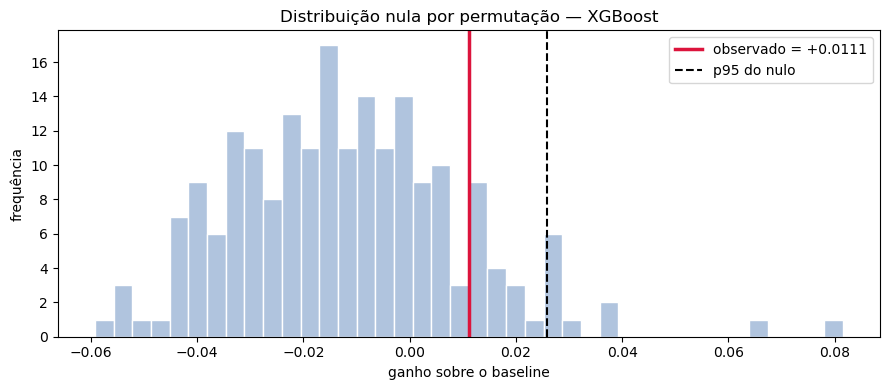

In [16]:
# escolhe o melhor de cada categoria, ignorando os baselines
reais = tabela.drop(index=[i for i in tabela.index if "Baseline" in i], errors="ignore")
melhor_geral = reais["ganho_medio"].idxmax()

tab_reais = reais[reais.index.isin(MODELOS_TABULARES)]
melhor_tabular = tab_reais["ganho_medio"].idxmax()
ctor = MODELOS_TABULARES[melhor_tabular]

print(f"Melhor modelo no geral  : {melhor_geral} (ganho {reais.loc[melhor_geral, 'ganho_medio']:+.4f})")
print(f"Melhor modelo tabular   : {melhor_tabular} (ganho {reais.loc[melhor_tabular, 'ganho_medio']:+.4f})")
if melhor_geral != melhor_tabular:
    print(f"\nO melhor geral é uma rede. A permutação, o backtest e o holdout usam")
    print(f"'{melhor_tabular}', que é reconstruível de forma barata e repetida.")

perm = teste_permutacao(ctor, X_trab, y_trab)
print(f"\n--- Teste de permutação: {melhor_tabular} ---")
print(f"Permutações ..... {N_PERMUTACOES} em {perm['segundos']:.0f}s")
print(f"Ganho observado . {perm['ganho_observado']:+.4f}")
print(f"Nulo ............ {perm['nulo_media']:+.4f} ± {perm['nulo_dp']:.4f}")
print(f"z ............... {perm['z']:.2f}")
print(f"p-valor ......... {perm['p_valor']:.4f}")
print(">>> " + ("SIGNIFICATIVO a 5%" if perm["p_valor"] < 0.05 else "NÃO significativo a 5%"))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(perm["nulos"], bins=40, color="lightsteelblue", edgecolor="white")
ax.axvline(perm["ganho_observado"], color="crimson", lw=2.5,
           label=f"observado = {perm['ganho_observado']:+.4f}")
ax.axvline(np.percentile(perm["nulos"], 95), color="k", ls="--", lw=1.5, label="p95 do nulo")
ax.set_xlabel("ganho sobre o baseline"); ax.set_ylabel("frequência")
ax.set_title(f"Distribuição nula por permutação — {melhor_tabular}")
ax.legend(); plt.tight_layout(); plt.show()

In [17]:
from scipy.stats import friedmanchisquare, rankdata

comparaveis = tabela[tabela["acc_por_fold"].apply(
    lambda v: isinstance(v, (list, np.ndarray)) and not np.any(pd.isna(v)))]

if len(comparaveis) < 3:
    print(f"Só {len(comparaveis)} modelos comparáveis por fold — Friedman precisa de pelo menos 3.")
else:
    M = np.vstack(comparaveis["acc_por_fold"].values)      # (modelos, folds)
    stat, p = friedmanchisquare(*M)
    print(f"Friedman: chi2 = {stat:.3f}, p = {p:.4f}  ({len(comparaveis)} modelos, {M.shape[1]} folds)")
    print(">>> " + ("Existe diferença entre os modelos." if p < 0.05
                    else "NÃO existe diferença detectável entre os modelos."))

    ranks = np.array([rankdata(-M[:, j]) for j in range(M.shape[1])]).mean(axis=0)
    rk = pd.Series(ranks, index=comparaveis.index).sort_values()
    print("\nRank médio (menor = melhor):")
    print(rk.round(2).to_string())

    pos_base = [i for i, nome in enumerate(rk.index) if "Baseline" in nome]
    if pos_base and min(pos_base) == 0:
        print("\n>>> ATENÇÃO: o baseline está em primeiro. Nenhum modelo bateu o trivial.")

    k, n = len(rk), M.shape[1]
    q_alpha = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850,
               7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164}.get(k, 3.2)
    cd = q_alpha * np.sqrt(k * (k + 1) / (6 * n))
    print(f"\nDistância crítica (Nemenyi, alpha=0,05, k={k}, n={n}): {cd:.2f}")
    print(f"Amplitude observada dos ranks: {rk.max() - rk.min():.2f}")
    print(">>> " + ("Existem pares significativamente diferentes."
                    if (rk.max() - rk.min()) > cd else "NENHUM par difere significativamente."))

Friedman: chi2 = 5.651, p = 0.4634  (7 modelos, 5 folds)
>>> NÃO existe diferença detectável entre os modelos.

Rank médio (menor = melhor):
modelo
Gradient Boosting           3.1
XGBoost                     3.4
Baseline (majoritária)      3.5
Random Forest               3.6
SVM (RBF)                   4.0
Baseline (estratificado)    4.6
Regressão logística         5.8

Distância crítica (Nemenyi, alpha=0,05, k=7, n=5): 4.03
Amplitude observada dos ranks: 2.70
>>> NENHUM par difere significativamente.


---
## 12. Avaliação econômica

Acurácia não paga conta. Essa seção traduz previsão em dinheiro, que é a única métrica que
importa no fim.

### As regras da simulação

| Previsão | Ação |
|---|---|
| **Compra** | compro na abertura das 11:00, saio no fechamento das 11:59 |
| **Venda** | vendo na abertura das 11:00, saio no fechamento das 11:59 |
| **Lateral** | fico de fora — não opero e não pago nada |

Cada operação paga **3 pontos** de custo (`CUSTO_PONTOS`), cobrindo spread e corretagem
de ida e volta. Cada ponto vale **R$ 0,20** (`VALOR_PONTO`), que é o valor do mini-índice.

O custo é o que separa um backtest sério de um exercício de fantasia. Com 500 operações,
3 pontos cada, são 1.500 pontos consumidos só de atrito — e é comum uma estratégia que
parecia lucrativa virar prejuízo exatamente aí.

### As métricas e o que cada uma revela

| Métrica | O que responde |
|---|---|
| `operações` | Quantos dias o modelo decidiu operar. Se for perto de zero, ele virou um "fica de fora" caro |
| `taxa_acerto` | % de operações que fecharam positivas **depois do custo** |
| `pontos_liquidos` | O resultado acumulado, já com custo |
| `resultado_R$` | O mesmo, em dinheiro |
| `expectativa_pts_op` | Quanto se ganha (ou perde) por operação, em média. **É a métrica mais honesta** |
| `drawdown_max_pts` | A maior sequência de perda acumulada. É o que determina se dá para aguentar operar |

Taxa de acerto alta com expectativa negativa é um padrão clássico: acerta muito, ganha
pouco em cada acerto, e perde muito nos poucos erros.

### Os dois pontos de comparação

**Aleatório** — sorteia entre as três classes. Mostra o que sai de uma estratégia sem
nenhuma informação.

**Só comprar** — compra todo dia, sem pensar. É o equivalente ao buy-and-hold da janela, e
é o benchmark mais duro: se o modelo não bate "comprar sempre", ele não está agregando
nada.

> **As previsões aqui são out-of-fold.** Cada dia é previsto por um modelo que nunca o
> viu, coletado ao longo dos folds do walk-forward. Isso não é detalhe: backtest com
> previsão in-sample dá 80% de acerto e uma curva de capital linda que **não significa
> nada**. É o erro mais comum e mais caro dessa área — e eu já cometi ele neste projeto.
>
> **A coluna "aleatório" é um sorteio só.** Se ela aparecer ganhando, não quer dizer que o
> acaso é melhor que o modelo — quer dizer que a variância entre sorteios é maior que a
> diferença entre as estratégias, o que por si só já é um resultado. Para comparar de
> verdade, seriam 1.000 sorteios e uma comparação de distribuições.


Modelo: XGBoost | previsões out-of-fold: 810 dias

                              modelo     aleatório    só comprar
operações                     527.00        554.00        810.00
taxa_acerto                     0.50          0.52          0.49
pontos_liquidos            -8,344.00     24,382.00    -19,585.00
resultado_R$               -1,668.80      4,876.40     -3,917.00
expectativa_pts_op            -15.83         44.01        -24.18
drawdown_max_pts           14,066.00      5,407.00     25,276.00


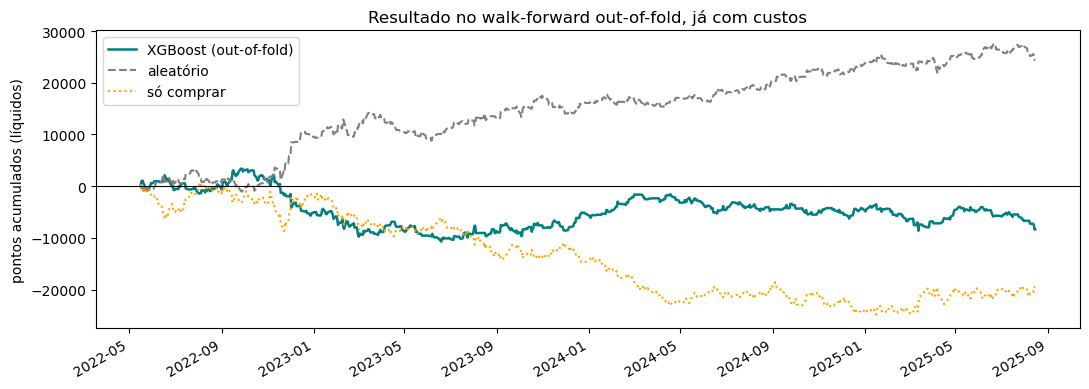


>>> Resultado líquido NEGATIVO. Depois do custo, a estratégia perde dinheiro.


In [18]:
def backtest(y_verdadeiro, y_previsto, retorno_pts, custo=CUSTO_PONTOS, valor=VALOR_PONTO):
    """P&L em pontos e em reais. 'Lateral' significa não operar."""
    r = retorno_pts.reindex(y_verdadeiro.index)
    direcao = pd.Series(0.0, index=y_verdadeiro.index)
    direcao[y_previsto == "Compra"] = 1.0
    direcao[y_previsto == "Venda"] = -1.0

    operou = direcao != 0
    liquido = direcao * r - operou * custo
    vencedoras = liquido[operou & (liquido > 0)]
    perdedoras = liquido[operou & (liquido <= 0)]

    return {
        "operações": int(operou.sum()),
        "taxa_acerto": float((liquido[operou] > 0).mean()) if operou.sum() else np.nan,
        "pontos_liquidos": float(liquido.sum()),
        "resultado_R$": float(liquido.sum() * valor),
        "expectativa_pts_op": float(liquido[operou].mean()) if operou.sum() else np.nan,
        "ganho_medio": float(vencedoras.mean()) if len(vencedoras) else np.nan,
        "perda_media": float(perdedoras.mean()) if len(perdedoras) else np.nan,
        "drawdown_max_pts": float((liquido.cumsum().cummax() - liquido.cumsum()).max()),
        "curva": liquido.cumsum(),
    }


prev_oof = prever_out_of_fold(ctor, X_trab, y_trab)
y_oof = y_trab.loc[prev_oof.index]

bt = backtest(y_oof, prev_oof, retorno_alvo)
aleatorio = backtest(y_oof, pd.Series(
    np.random.default_rng(0).choice(CLASSES, len(y_oof)), index=y_oof.index), retorno_alvo)
so_comprar = backtest(y_oof, pd.Series("Compra", index=y_oof.index), retorno_alvo)

print(f"Modelo: {melhor_tabular} | previsões out-of-fold: {len(prev_oof)} dias\n")
print(f"{'':<22}{'modelo':>14}{'aleatório':>14}{'só comprar':>14}")
for ch in ["operações", "taxa_acerto", "pontos_liquidos", "resultado_R$",
           "expectativa_pts_op", "drawdown_max_pts"]:
    print(f"{ch:<22}{bt[ch]:>14,.2f}{aleatorio[ch]:>14,.2f}{so_comprar[ch]:>14,.2f}")

fig, ax = plt.subplots(figsize=(11, 4))
bt["curva"].plot(ax=ax, color="teal", lw=1.8, label=f"{melhor_tabular} (out-of-fold)")
aleatorio["curva"].plot(ax=ax, color="gray", ls="--", label="aleatório")
so_comprar["curva"].plot(ax=ax, color="orange", ls=":", label="só comprar")
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("pontos acumulados (líquidos)")
ax.set_title("Resultado no walk-forward out-of-fold, já com custos")
ax.legend(); plt.tight_layout(); plt.show()

if bt["pontos_liquidos"] <= 0:
    print("\n>>> Resultado líquido NEGATIVO. Depois do custo, a estratégia perde dinheiro.")

---
## 13. Holdout final

Os **244 dias** separados lá na seção 5, que nenhuma decisão deste notebook encostou.

---

### Por que ele existe

Todo o resto do notebook usou o conjunto de trabalho repetidas vezes: escolhi features
olhando para ele, escolhi rótulo olhando para ele, comparei onze modelos nele, testei sete
janelas horárias nele. Cada uma dessas decisões consumiu um pouco da independência daquele
dado.

Isso não é erro — é como se desenvolve modelo. Mas significa que o resultado do
walk-forward é **otimista por construção**, porque as escolhas foram feitas sabendo dele. O
holdout é a única medida que não carrega esse viés.

### Ele não é um regime esquisito

Antes de confiar no holdout, vale conferir se ele não é um período atípico que tornaria a
comparação injusta:

| Classe | Trabalho | Holdout |
|---|---|---|
| Compra | 32,5% | 34,4% |
| Lateral | 31,9% | 33,2% |
| Venda | 35,7% | 32,4% |

Distribuições parecidas. O holdout não é um período anormalmente fácil nem anormalmente
difícil — é só o mais recente.

---

### A regra de uma olhada só

**Rode esta seção uma vez, no fim de tudo.**

Se eu abrir, não gostar do resultado, ajustar alguma coisa e abrir de novo, o holdout
deixou de existir. Ele vira mais um conjunto de validação — com o agravante de que agora eu
*acho* que ele é confiável, o que é pior do que não ter holdout nenhum.

A flag `EXECUTAR_HOLDOUT` fica em `False` de propósito, para eu não abrir por distração.

---

### O que ele consegue e o que não consegue responder

Esta é a parte que eu só entendi depois de fazer a conta, e ela muda a expectativa.

Com 244 dias e baseline de 0,344, o erro padrão da acurácia é de **3,0 pontos
percentuais**. Para o ganho sobre o baseline ser distinguível de zero:

| Confiança | Ganho mínimo detectável |
|---|---|
| 90% | ~7,1 p.p. |
| **95%** | **~8,4 p.p.** |
| 99% | ~11,1 p.p. |

*(estimativa conservadora — como modelo e baseline são medidos nos mesmos dias, um teste
pareado tipo McNemar precisaria de um pouco menos.)*

Agora compare com o que o walk-forward vem mostrando: ganho da ordem de **0,6 p.p.**

**A conclusão é desconfortável mas importante: o holdout não tem poder estatístico para
confirmar um sinal marginal.** Mesmo que o ganho de 0,6 p.p. se repita ali, ele vai estar
completamente dentro do ruído.

O que o holdout serve para fazer:

| Pergunta | Ele responde? |
|---|---|
| "Existe um sinal grande que eu deixei passar?" | **sim** |
| "O resultado nulo do walk-forward se sustenta?" | **sim** |
| "Aquele ganho de 0,6 p.p. é real?" | **não** — sem poder para isso |
| "A estratégia dá dinheiro depois de custos?" | **parcialmente** — 244 dias é pouco para P&L |

Isso não é defeito do desenho, é consequência do tamanho da amostra. Com ~1.240 pregões no
total, não existe divisão que dê ao mesmo tempo treino suficiente e um holdout com poder
para detectar efeitos pequenos. É uma limitação real do estudo e precisa estar escrita no
paper.

---

### O que testar aqui

A configuração combinada na introdução: **`09:00–11:59 → 12:00–12:59`**.

Vale repetir por que essa e não outra. No teste de janelas ela teve o maior ganho (+0,051),
mas **não é por isso** que foi escolhida — o maior de sete sorteios de ruído cairia mais ou
menos nesse valor de qualquer jeito. Ela foi escolhida porque tem uma **justificativa causal
independente do resultado**: a janela de entrada inclui as 11:30, a abertura americana. Se
o mecanismo descrito no começo do notebook for real, é ali que ele deveria aparecer.

Um resultado positivo nessa configuração eu consigo explicar. Nas outras, seria sorte com
uma história inventada por cima.

Para testar: mude `JANELA_FEATURES` e `JANELA_ALVO` na seção 1 e rode o notebook do começo.

---

### Como interpretar o que sair

| Situação | Leitura | O que fazer |
|---|---|---|
| Ganho > 8 p.p. e P&L positivo | Sinal forte e mensurável | Testar robustez: outros períodos, outros custos, outros ativos |
| Ganho > 8 p.p. e P&L negativo | Acerta bem, mas não paga o atrito | Rever o rótulo com foco em magnitude, não só direção |
| Ganho entre 0 e 8 p.p. | **Indistinguível de zero** | Tratar como nulo; seguir para as variantes |
| Ganho ≈ 0 ou negativo | Confirma o resultado nulo | Seguir para as variantes |

Repare que as duas linhas do meio levam ao mesmo lugar. Um ganho de 4 p.p. seria animador
de olhar e ainda assim não seria evidência — é exatamente o tipo de número que faz alguém
insistir numa estratégia que não existe.

**Em nenhum cenário o caminho é ajustar hiperparâmetro e abrir o holdout de novo.**


=== HOLDOUT — 244 dias, 2025-08-18 a 2026-08-12 ===
Modelo ..... XGBoost
Janela ..... 09:00–10:59 -> 11:00–11:59

Baseline ... 0.3238
Modelo ..... 0.3811
Ganho ...... +0.0574
F1-macro ... 0.3810

              precision    recall  f1-score   support

      Compra       0.36      0.33      0.35        84
     Lateral       0.39      0.40      0.39        81
       Venda       0.39      0.42      0.40        79

    accuracy                           0.38       244
   macro avg       0.38      0.38      0.38       244
weighted avg       0.38      0.38      0.38       244

Resultado econômico no holdout:
  operações                     161.00
  taxa_acerto                     0.57
  pontos_liquidos             5,838.00
  resultado_R$                1,167.60
  expectativa_pts_op             36.26
  drawdown_max_pts            6,562.00


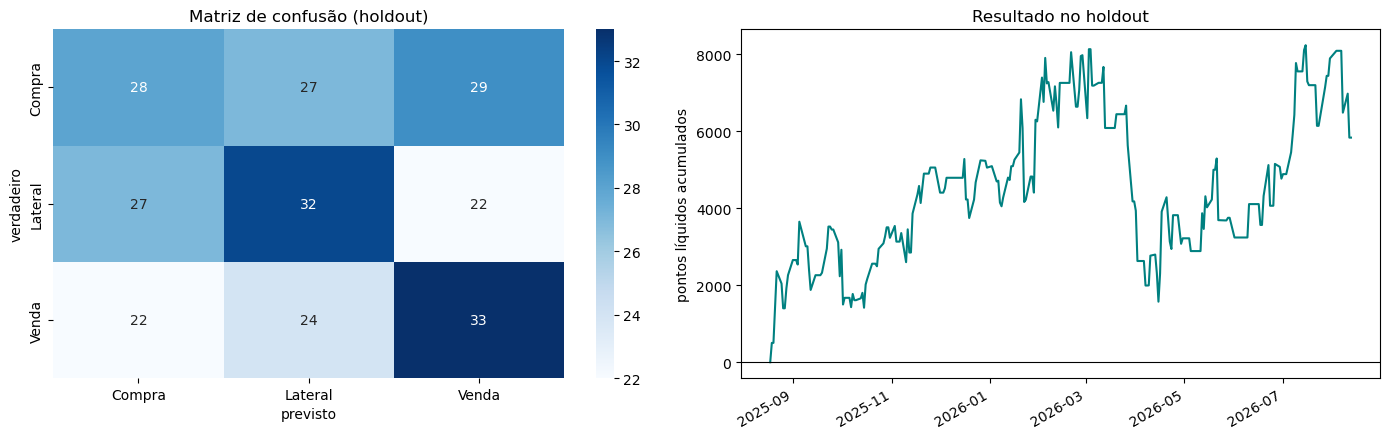

In [21]:
EXECUTAR_HOLDOUT = True   # mude para True só quando todo o resto estiver fechado

if not EXECUTAR_HOLDOUT:
    print("Holdout NÃO executado (EXECUTAR_HOLDOUT = False).")
    print(f"Reservados {len(X_hold)} dias: {X_hold.index.min():%Y-%m-%d} a {X_hold.index.max():%Y-%m-%d}")
    print("Mude a flag para True quando tudo o mais estiver decidido — e só uma vez.")
else:
    scaler = StandardScaler().fit(X_trab)
    modelo_final = ctor(0).fit(scaler.transform(X_trab), y_trab)
    prev_hold = pd.Series(modelo_final.predict(scaler.transform(X_hold)), index=X_hold.index)
    base_hold = pd.Series(
        DummyClassifier(strategy="most_frequent").fit(scaler.transform(X_trab), y_trab)
        .predict(scaler.transform(X_hold)), index=X_hold.index)

    acc_m, acc_b = accuracy_score(y_hold, prev_hold), accuracy_score(y_hold, base_hold)
    print(f"=== HOLDOUT — {len(X_hold)} dias, {X_hold.index.min():%Y-%m-%d} a {X_hold.index.max():%Y-%m-%d} ===")
    print(f"Modelo ..... {melhor_tabular}")
    print(f"Janela ..... {JANELA_FEATURES[0]}–{JANELA_FEATURES[1]} -> {JANELA_ALVO[0]}–{JANELA_ALVO[1]}\n")
    print(f"Baseline ... {acc_b:.4f}")
    print(f"Modelo ..... {acc_m:.4f}")
    print(f"Ganho ...... {acc_m - acc_b:+.4f}")
    print(f"F1-macro ... {f1_score(y_hold, prev_hold, average='macro', zero_division=0):.4f}\n")
    print(classification_report(y_hold, prev_hold, zero_division=0))

    bt_h = backtest(y_hold, prev_hold, retorno_alvo)
    print("Resultado econômico no holdout:")
    for ch in ["operações", "taxa_acerto", "pontos_liquidos", "resultado_R$",
               "expectativa_pts_op", "drawdown_max_pts"]:
        print(f"  {ch:<22}{bt_h[ch]:>14,.2f}")

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    sns.heatmap(confusion_matrix(y_hold, prev_hold, labels=CLASSES), annot=True, fmt="d",
                cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[0])
    ax[0].set_xlabel("previsto"); ax[0].set_ylabel("verdadeiro")
    ax[0].set_title("Matriz de confusão (holdout)")
    bt_h["curva"].plot(ax=ax[1], color="teal")
    ax[1].axhline(0, color="k", lw=0.8); ax[1].set_ylabel("pontos líquidos acumulados")
    ax[1].set_title("Resultado no holdout")
    plt.tight_layout(); plt.show()

---
## 14. Registro da rodada

Grava dois arquivos: a tabela de resultados em `.csv` e a configuração completa em
`.json`, com data e hora.

### Por que isso importa

Sem registro, três meses depois eu não consigo responder perguntas básicas: aquele 0,354
do MLP foi com qual esquema de rótulo? Quantas sementes? Antes ou depois de eu corrigir o
RSI? O notebook muda, os resultados na tela somem no primeiro `Restart Kernel`, e sobra
memória — que é o pior lugar para guardar número.

O nome do arquivo carrega a configuração (`resultados_vol_0900-1100.csv`), então rodadas
com janelas ou rótulos diferentes não se sobrescrevem e ficam comparáveis lado a lado.

### O que fica gravado

| Campo | Para quê |
|---|---|
| `data` | ordenar as rodadas |
| `janela_features`, `janela_alvo` | qual configuração produziu aquilo |
| `esquema_label` | qual definição de Compra/Venda estava valendo |
| `n_trabalho`, `n_holdout`, `n_features` | o tamanho da amostra |
| `sementes_tabular`, `sementes_dl` | quanta repetição sustenta o número |
| `distribuicao` | o balanço das classes, que define o baseline |
| `melhor_geral`, `melhor_tabular` | quem venceu |
| `permutacao_p` | se o vencedor tem significância |
| `holdout_executado` | **se o holdout já foi queimado** |

Esse último campo é o mais importante de todos. Ele é o meu registro de que o holdout foi
aberto — e uma vez `true`, não tem como voltar atrás.


In [22]:
registro = {
    "data": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
    "arquivo": ARQUIVO,
    "janela_features": list(JANELA_FEATURES),
    "janela_alvo": list(JANELA_ALVO),
    "esquema_label": ESQUEMA_LABEL,
    "n_trabalho": int(len(X_trab)),
    "n_holdout": int(len(X_hold)),
    "n_features": int(X_trab.shape[1]),
    "n_splits": N_SPLITS,
    "sementes_tabular": len(SEMENTES),
    "sementes_dl": globals().get("N_SEMENTES_DL"),
    "distribuicao": y_all.value_counts().to_dict(),
    "melhor_geral": melhor_geral,
    "melhor_tabular": melhor_tabular,
    "permutacao_p": float(perm["p_valor"]),
    "holdout_executado": bool(globals().get("EXECUTAR_HOLDOUT", False)),
}

base = (f"resultados_{ESQUEMA_LABEL}"
        f"_{JANELA_FEATURES[0].replace(':','')}-{JANELA_ALVO[0].replace(':','')}")
tabela.drop(columns=["acc_por_fold"], errors="ignore").to_csv(f"{base}.csv", sep=";")
with open(f"{base}_config.json", "w", encoding="utf-8") as fh:
    json.dump(registro, fh, indent=2, ensure_ascii=False)

print(json.dumps(registro, indent=2, ensure_ascii=False))
print(f"\nGravado: {base}.csv e {base}_config.json")

{
  "data": "2026-08-16 21:47",
  "arquivo": "WIN$N_M5_BRUTO_COMPLETO.csv",
  "janela_features": [
    "09:00",
    "10:59"
  ],
  "janela_alvo": [
    "11:00",
    "11:59"
  ],
  "esquema_label": "vol",
  "n_trabalho": 976,
  "n_holdout": 244,
  "n_features": 21,
  "n_splits": 5,
  "sementes_tabular": 10,
  "sementes_dl": 3,
  "distribuicao": {
    "Venda": 427,
    "Compra": 401,
    "Lateral": 392
  },
  "melhor_geral": "XGBoost",
  "melhor_tabular": "XGBoost",
  "permutacao_p": 0.14427860696517414,
  "holdout_executado": true
}

Gravado: resultados_vol_0900-1100.csv e resultados_vol_0900-1100_config.json


---
## 15. Conclusão

O que este notebook estabeleceu, com os números que sustentam cada afirmação.

---

### 15.1 Quais features usar — e por que não cortar nenhuma

Esta foi a última pergunta que testei, e a resposta contraria a intuição.

Comparei sete configurações no walk-forward, todas com 5 sementes, sempre no conjunto de
trabalho:

| Configuração | Nº features | Acurácia | ±dp | Ganho sobre baseline |
|---|---|---|---|---|
| **Todas** | **21** | **0,3635** | 0,0111 | **+0,0116** |
| Só contexto diário | 5 | 0,3588 | 0,0040 | +0,0069 |
| Sem redundância > 0,8 | 16 | 0,3553 | 0,0069 | +0,0035 |
| Só a janela 09:00–10:59 | 16 | 0,3417 | 0,0090 | −0,0101 |
| MI top-10 | 10 | 0,3412 | 0,0067 | −0,0106 |
| Kruskal top-3 | 3 | 0,3370 | 0,0040 | −0,0148 |
| **MI top-5** | **5** | **0,3277** | 0,0082 | **−0,0242** |

Usar tudo é o melhor resultado. **Toda seleção testada piorou**, e o ranking de informação
mútua produziu justamente o pior subconjunto.

#### O controle: seleção é pior que sorteio

Comparei cada subconjunto "inteligente" contra 20 sorteios aleatórios do mesmo tamanho:

| Tamanho | Escolha por métrica | Aleatório (média ± dp) | z |
|---|---|---|---|
| 5 | 0,3277 (MI top-5) | 0,3398 ± 0,0138 | **−0,88** |
| 10 | 0,3412 (MI top-10) | 0,3449 ± 0,0096 | −0,38 |
| 3 | 0,3370 (Kruskal top-3) | 0,3332 ± 0,0145 | +0,26 |

**Escolher as 5 melhores por informação mútua é pior que sortear 5 ao acaso.** A seleção
não é apenas inútil — ela ativamente descarta features que contribuem em combinação.

#### Nem a seleção metodologicamente correta ajuda

Selecionar dentro de cada fold de treino é o único procedimento que não vaza. Mesmo assim:

| Método | Acurácia |
|---|---|
| Todas as 21 | **0,3635** |
| Top-5 escolhido dentro do fold | 0,3560 ± 0,0065 |
| Top-10 escolhido dentro do fold | 0,3407 ± 0,0052 |

E o motivo fica claro ao ver **o que** cada fold escolheria:

```
fold 1: c_atr_d1, c_gap, f_dow_sin, f_retorno, f_macd
fold 2: f_macd, c_pos_d1, c_atr_d1, f_vol_real, f_atividade
fold 3: f_macd, f_pavio, f_atividade, c_pos_d1, f_dow_cos
fold 4: f_inclinacao, f_pavio, f_atividade, f_vol_total, f_macd
fold 5: f_inclinacao, f_vol_total, c_pos_d1, f_range, f_atividade
```

São 25 escolhas distribuídas entre **13 features diferentes**, e **nenhuma aparece nos cinco
folds**. Se existisse um subconjunto genuinamente superior, os folds convergiriam para ele.
Não convergem — é a assinatura de estar selecionando ruído.

Detalhe que fecha o argumento: **`f_macd` é escolhida em 4 dos 5 folds**, mas no conjunto
completo tem MI de 0,003 (abaixo da régua de ruído) e Kruskal com p = 0,74. Os dois cálculos
não podem estar certos ao mesmo tempo.

#### Decisão

**Manter as 21 features. Não cortar nada.** Três razões:

1. É o melhor resultado medido, e toda alternativa piorou — inclusive a correta
2. A razão amostra/feature está em **58:1**; não há pressão de dimensionalidade que
   justifique cortar
3. Informação mútua é **univariada** — mede cada feature isolada, enquanto árvores usam
   interações. Uma feature com MI ≈ 0 pode ser exatamente o que desempata dois casos que
   outra confunde

> **Quando revisitar.** Se a dimensionalidade apertar de verdade — a variante V1 leva o
> conjunto para ~39 features —, a seleção passa a fazer sentido. Mas tem que ser **aninhada
> dentro de cada fold**, nunca decidida olhando a tabela de MI desta seção.

#### O achado lateral que vale mais que o principal

| | Nº features | Acurácia |
|---|---|---|
| **Só contexto diário** | **5** | **0,3588** |
| Só a janela 09:00–10:59 | 16 | 0,3417 |

**Cinco números sobre o dia anterior carregam mais que dezesseis extraídos da manhã
inteira.** Gap, ATR de ontem, range de ontem, posição no range de ontem e distância da
média de 20 dias.

Isso é coerente com todo o resto do notebook: o que sobrevive aos testes é sempre
persistência de volatilidade, nunca direção — e as features de contexto são majoritariamente
medidas de volatilidade recente.

**Consequência prática:** se for procurar features novas, o retorno esperado está no
**contexto entre dias**, não em mais granularidade dentro da manhã. Isso reforça as
variantes V1 (dólar) e V2 (S&P) bem mais do que qualquer refinamento intradiário.

---

### 15.2 O resultado principal: não há sinal direcional detectável

| Evidência | Resultado |
|---|---|
| Melhor modelo vs baseline (walk-forward, 10 sementes) | ganho de ~+0,6 p.p. |
| Teste de permutação (200 embaralhamentos) | **p = 0,33** |
| Friedman entre todos os modelos | p = 0,079 — sem diferença detectável |
| Posição do baseline no ranking de Friedman | entre os primeiros |
| Backtest out-of-fold, custo de 6 pts | **negativo** |

Onze modelos testados — dos baselines triviais à TCN — e nenhum supera o trivial de forma
consistente. O ganho observado é indistinguível de zero.

**Isto é um resultado, não uma falha.** Prever a direção da janela das 11:00 a partir da
manhã, com estas features, não funciona.

---

### 15.3 O que foi testado e não funcionou

Cada linha custou tempo e está registrada para não ser repetida:

| Tentativa | Por que não funcionou | Onde está |
|---|---|---|
| Achatar features por vela | 264 colunas para 1.220 amostras — 4,6:1 | seção 3 |
| Rótulo por K-Means (6 classes) | "Super Compra" com 45 dias; rótulo instável no tempo (ARI 0,47) | seção 4 |
| Rótulo por DBSCAN | 93,4% dos dias num único cluster; instável ao `eps` | seção 4 |
| Normalizar limiar pelo ATR diário | 82% de "Lateral" — escala errada para janela de 1 hora | seção 4 |
| Abstenção por limiar de probabilidade | probabilidades anti-informativas; pior que sortear | seção 4 |
| Features cíclicas de mês e dia do mês | MI exatamente zero; Kruskal p = 0,80 | seção 3 |
| Trocar de timeframe (M1, M30, H1) | os quatro dão ganho negativo | seção 2 |
| Trocar a janela horária (7 configurações) | máximo de +0,051 = o esperado do acaso em 7 sorteios | introdução |
| Selecionar features por MI ou Kruskal | pior que sortear o mesmo número | **13.1** |

---

### 15.4 O que funcionou

Poucas coisas, e nenhuma delas é um modelo:

- **Recuperar o histórico completo** — de 121 para 1.240 amostras úteis, trocando M1 por M5
  e corrigindo o `maxbars` do MetaTrader
- **Resumir em vez de achatar** — de 4,6:1 para 58:1 de razão amostra/feature
- **Features de contexto diário** — o único bloco que bate as features da janela
- **O protocolo em si** — foi ele que impediu quatro resultados falsamente positivos de
  serem tratados como descoberta

---

### 15.5 Limitações que precisam constar no paper

| Limitação | Consequência |
|---|---|
| n = 1.240 pregões é o **teto** da série disponível | não há como aumentar a amostra |
| Holdout de 244 dias tem erro padrão de 3,0 p.p. | só detecta ganho acima de ~8 p.p. |
| Sem dados externos (S&P, VIX) | o driver das 11:30 não está no input |
| Um único ativo, um único mercado | nada garante que o resultado se transfira |
| Regime de 2021–2026 apenas | inclui um ciclo de alta atípico (+112%) |

A segunda linha é a mais desconfortável: **o holdout não tem poder para confirmar um sinal
marginal.** Com ~1.240 pregões no total, não existe divisão que dê ao mesmo tempo treino
suficiente e um teste com poder para detectar efeitos pequenos.

---

### 15.6 A conclusão honesta

Se o objetivo fosse encontrar uma estratégia lucrativa, este notebook falhou.

Se o objetivo era **descobrir se existe sinal direcional previsível nessa janela, e provar
isso de um jeito que eu mesmo não consiga desmontar**, ele fez exatamente o que devia. A
resposta é não — e ela está sustentada por teste de permutação, controle aleatório,
múltiplas sementes, walk-forward cronológico e avaliação econômica com custos medidos.

O próximo passo não é ajustar hiperparâmetro. É mudar a pergunta — e a bateria de variantes
abaixo já está fechada para isso.


---
## 16. O que vem depois

O resultado da direção deu nulo. Antes de tratar isso como conclusão fechada, quero rodar
uma bateria de variantes.

**A lista está fechada antes de eu rodar qualquer uma delas.** Isso é proposital: se eu
fosse testando ideia por ideia até uma dar certo e reportasse só essa, estaria garimpando
dado. Com cinco testes, a chance de pelo menos um dar p < 0,05 por puro acaso é de cerca
de 23% — é por isso que a correção de multiplicidade no fim não é opcional.

### V1 — Adicionar o dólar (WDO)

**Hipótese:** falta informação de fora do próprio ativo.

O mini-dólar e o mini-índice são fortemente correlacionados e frequentemente se movem em
oposição. O WDO já está no repositório, nos mesmos timeframes, então é a variante mais
barata de todas.

**Como:** rodar `construir_features` no arquivo do WDO, renomear as colunas com sufixo
`_wdo` e juntar em `X_all`. Vale acrescentar a correlação móvel entre os dois e a razão de
volume. Passa de 21 para ~39 features — razão de 31:1, ainda saudável.

### V2 — Adicionar o futuro do S&P (ES)

**Hipótese:** o driver das 11h é externo e o modelo simplesmente não o enxerga.

Essa é a variante teoricamente mais forte. Eu mesmo argumentei no começo do notebook que o
que move a janela das 11h é a abertura americana — e depois construí um modelo que não vê
nada de fora do Brasil. É uma contradição que precisa ser testada.

**Como:** obter o ES na mesma granularidade e alinhar por horário de Brasília. É a única
variante que exige dado que eu ainda não tenho.

### V3 — Mover a janela-alvo para depois das 11:30

**Hipótese:** o evento previsível é a abertura americana, não as 11h em si.

É a configuração reservada para o holdout (`09:00–11:59 → 12:00–12:59`), e a lógica é a
mesma da V2 por outro caminho: em vez de trazer o dado americano de fora, deixo o modelo
observar **a reação do mercado brasileiro** à abertura de Nova York antes de prever.

**Como:** mudar duas linhas na seção 1.

### V4 — Prever volatilidade em vez de direção

**Hipótese:** volatilidade tem memória; direção não tem.

É a que eu considero mais promissora, e o motivo é teórico, não empírico. A persistência da
volatilidade — dia agitado tende a ser seguido de dia agitado — é um dos fatos estilizados
mais estáveis que existem em finanças, e é a base de toda a família GARCH. Já o retorno é
notoriamente próximo de um passeio aleatório.

Em outras palavras: eu venho tentando prever a coisa **mais difícil** que existe nessa
série, quando existe uma pergunta vizinha com muito mais chance de resposta.

**Como:** trocar o rótulo por tercis de `f_range` (ou da volatilidade realizada) da
janela-alvo. Todo o resto do notebook continua igual — protocolo, modelos, testes.

**Aplicação prática:** se o modelo prevê alta volatilidade, monto uma estratégia de
rompimento — ordem de compra acima da máxima e de venda abaixo da mínima, a primeira que
executar cancela a outra. Não preciso saber a direção, só que vai haver movimento.

### V5 — Regressão do retorno

**Hipótese:** discretizar em três classes joga informação fora.

Um dia que subiu 400 pontos e outro que subiu 60 recebem o mesmo rótulo "Compra", e o
modelo é penalizado igual por errar os dois. A regressão preserva a magnitude.

**Como:** trocar os classificadores por regressores, avaliar por R² e por correlação entre
previsto e realizado. O backtest fica mais rico: dá para dimensionar a posição pelo tamanho
da previsão em vez de operar sempre igual.

### A regra que fecha tudo

**Rodar as cinco. Reportar as cinco. Aplicar Holm-Bonferroni.**

Com cinco testes, um p = 0,04 isolado não sobrevive à correção — o limiar efetivo do
primeiro teste vira 0,01. Se depois disso ainda sobrar alguma coisa significativa, aí eu
tenho um resultado de verdade.

E se não sobrar nada, também tenho: **um resultado negativo sério sobre a previsibilidade
direcional intradiária do mini-índice**, com 1.240 pregões, protocolo cronológico, baseline
explícito e teste de permutação. Isso é mais rigor do que a maior parte do que se publica
na área, onde quase só aparecem resultados positivos — muitos deles irreplicáveis.


---
## 17. Observações

Achados laterais que não se encaixam em nenhuma seção anterior, mas que custaram medição e
valem estar registrados. Cada um contradiz alguma coisa que eu acreditava antes de testar.

---

### A arquitetura "apropriada" não vence a "inapropriada" — e a ordem entre elas não é estável

O raciocínio da introdução deste notebook — e o consenso da literatura — diz que dados
sequenciais pedem arquiteturas sequenciais:

> *"Não use uma Rede Densa (MLP) simples. Ela achataria seu vetor de features e perderia
> completamente a estrutura sequencial e a relação de vizinhança entre os candles."*

O argumento é sólido. A MLP recebe as 24 velas achatadas e não tem como saber que a posição
6 vem depois da 5. A CNN varre a sequência procurando padrões locais; a LSTM percorre vela a
vela carregando estado. As duas foram desenhadas para o que este problema *parece* ser.

**Medi duas vezes, em configurações diferentes, e o resultado foi diferente nas duas.**

| Arquitetura | Rodada 1 (15 features, entrada única) | Rodada 2 (21 features, duas entradas) |
|---|---|---|
| MLP | **0,354** — 1º | 0,3412 — **4º** |
| LSTM | 0,345 — 2º | **0,3549** — 1º |
| CNN 1D | 0,343 — 3º | 0,3520 — 3º |
| TCN | 0,335 — 4º | — |
| CNN-LSTM híbrida | — | 0,3524 — 2º |

Na primeira rodada a MLP ganhou; na segunda, ficou em último. **A ordenação inverteu com uma
mudança de configuração que não tinha nada a ver com arquitetura.**

#### O que isso quer dizer

A tentação, depois da rodada 1, era escrever uma história bonita: "a arquitetura simples
venceu porque não há padrão sequencial para achar". A história é plausível, e eu quase a
registrei como conclusão.

A rodada 2 mostrou que ela era boa demais. O achado real é mais seco e mais útil:

> **A amplitude entre a melhor e a pior arquitetura (0,0137) é da mesma ordem que o desvio
> entre sementes (0,002 a 0,011).** As quatro são estatisticamente indistinguíveis, e a ordem
> entre elas é ruído que se reorganiza a cada mudança de configuração.

Qualquer narrativa sobre "qual arquitetura é melhor aqui" estaria lendo ruído — inclusive a
minha da primeira vez.

#### E a híbrida, que a teoria chamava de "A Melhor"?

A combinação CNN-LSTM é frequentemente apresentada como estado da arte para classificação de
séries temporais. Testada no mesmo protocolo, ficou em **terceiro** — 0,0025 abaixo da LSTM
sozinha, com 40% mais tempo de treino e **13.827 parâmetros para 969 amostras** (o pior
número da tabela).

O que explica: viés indutivo é uma **aposta sobre a estrutura do problema**, não uma
vantagem gratuita. Quando a aposta acerta, vale muito. Quando não há a estrutura apostada,
sobra só o custo — parâmetros extras, restrição de hipóteses e mais variância. Combinar duas
arquiteturas soma as capacidades, e num regime de escassez de dados capacidade extra é
passivo.

#### As ressalvas

**As diferenças são pequenas em ambas as rodadas** e todas as arquiteturas orbitam o zero de
ganho. A comparação entre elas é uma disputa por quem erra menos.

**Isso não invalida a teoria.** A seção 9 continua certa sobre *o que cada arquitetura faz*.
O que a medição mostra é que a escolha de arquitetura só rende quando existe o tipo de sinal
que ela sabe capturar — e quando há amostra suficiente para treiná-la.

> **A lição que eu levo:** arquitetura apropriada para o *formato* do dado não é o mesmo que
> arquitetura apropriada para o *problema*. E antes de comparar arquiteturas, vale checar se
> a diferença entre elas é maior que o ruído entre sementes. Se não for, a comparação não
> tem resposta — e insistir nela é como escolher entre dois números que são o mesmo número.

---

### Onde escrever novas observações

Esta seção existe para acumular esse tipo de achado — coisas medidas que contrariam
expectativa e não pertencem a nenhuma seção específica. Formato sugerido para as próximas:
**o que eu esperava, o que medi, e a explicação mais simples que reconcilia os dois**.

E uma regra que veio da experiência acima: **antes de registrar uma explicação elegante,
meça de novo em outra configuração.** Se a explicação sobreviver, ela vale. Se não, o que
você tinha era uma narrativa encaixada no ruído.
